# **Import**

In [ ]:
import warnings

warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statistics import mode, StatisticsError

# **DataFrame Join**

In [ ]:
cd /content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data

/content/drive/MyDrive/[Projects]/Dacon/운수종사자 인지적 특성 데이터를 활용한 교통사고 위험 예측 AI 경진대회/Data


In [ ]:
train_label = pd.read_csv('./train.csv')
train_a = pd.read_csv('./train/A.csv')
train_b = pd.read_csv('./train/B.csv')

In [ ]:
train_label.head()

,Test_id,Test,Label
0,0xE3EDFEA7DB8FF2606A19628967674BA957FB4BD58549...,A,0
1,0xDA572847455702C04D71C54677413CB8E31944B99289...,A,0
2,0xD5BB9FA4D3BC42EE494BD670F004564CB04A0DF8F819...,B,0
3,0x59D17D1C537B5FDE6622A9CB0A4192529CB4BD8D5422...,A,0
4,0x23005DA8BB4C84E1363A44A4248987798F3EAD4C58D3...,A,0


In [ ]:
train_label.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944767 entries, 0 to 944766
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Test_id  944767 non-null  object
 1   Test     944767 non-null  object
 2   Label    944767 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 21.6+ MB


In [ ]:
train_a.head()

,Test_id,Test,PrimaryKey,Age,TestDate,A1-1,A1-2,A1-3,A1-4,A2-1,...,A5-3,A6-1,A7-1,A8-1,A8-2,A9-1,A9-2,A9-3,A9-4,A9-5
0,0x744773A3B58E27F1811B47B53331F272AB5E569A9F72...,A,0x744773A3B58E27F1811B47B53331F272AB5E569A9F72...,20a,201811,"2,2,1,2,1,2,1,1,2,1,2,1,1,2,1,2,2,1","1,3,3,2,3,3,2,2,3,3,2,1,2,1,1,1,2,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","29,33,56,64,5,-51,44,-1,0,31,30,5,67,33,43,21,...","1,1,2,3,1,2,2,3,3,1,1,3,2,2,1,2,3,3",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",13,15,0,1,4,16,0,5,7
1,0xDA7DE599194F2B4F9624ACBCE96E66E2F8B357A4DD97...,A,0xDA7DE599194F2B4F9624ACBCE96E66E2F8B357A4DD97...,20a,201811,"2,2,1,2,2,1,1,1,2,2,1,2,1,1,2,1,2,1","3,2,2,1,1,3,1,1,2,3,2,1,3,1,2,3,3,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","76,1,27,25,41,34,-24,7,18,85,-18,-21,31,-7,18,...","2,3,3,1,2,2,3,2,3,1,2,3,1,3,2,1,1,1",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",11,11,9,0,1,3,0,0,4
2,0x7DF700D37380AD164ADF79B485C3A84A571186E3DB27...,A,0x7DF700D37380AD164ADF79B485C3A84A571186E3DB27...,20a,201802,"1,1,2,1,2,2,2,2,1,2,1,1,1,1,1,2,2,2","2,3,3,1,1,2,1,1,3,2,1,2,2,3,1,2,3,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-1,22,0,-37,-21,7,-34,-21,-79,-26,-80,-23,-63,...","1,1,3,2,3,2,1,1,1,1,3,2,2,2,2,3,3,3",...,"0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",12,16,2,2,2,5,0,4,4
3,0xAB057D1B8C3A8FB6E99F1B6E0F95086150951BCA8630...,A,0xAB057D1B8C3A8FB6E99F1B6E0F95086150951BCA8630...,20a,201805,"2,2,2,2,1,2,1,1,2,2,1,1,1,1,2,1,2,1","1,3,3,1,2,2,2,3,2,3,2,1,1,1,2,3,1,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-60,25,-25,-34,-40,-60,-46,-79,-77,-51,-80,-62...","1,2,2,3,1,1,2,2,3,1,3,2,1,3,3,3,2,1",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",11,15,0,0,0,0,2,0,2
4,0xAD4EC2C13080BC51C988805376AB404CCD2BA53CB108...,A,0xAD4EC2C13080BC51C988805376AB404CCD2BA53CB108...,20a,201806,"2,2,1,1,2,1,1,2,1,1,1,1,2,2,1,2,2,2","1,3,1,3,2,1,1,1,3,2,2,2,2,3,3,3,2,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0","-42,-77,-33,-3,-38,-58,-88,-4,-28,-58,-40,-29,...","1,3,3,2,2,2,3,1,3,1,1,2,1,3,1,2,3,2",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",11,8,0,2,9,16,1,21,4


In [ ]:
train_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 37 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Test_id     647241 non-null  object
 1   Test        647241 non-null  object
 2   PrimaryKey  647241 non-null  object
 3   Age         647241 non-null  object
 4   TestDate    647241 non-null  int64 
 5   A1-1        647241 non-null  object
 6   A1-2        647241 non-null  object
 7   A1-3        647241 non-null  object
 8   A1-4        647241 non-null  object
 9   A2-1        647240 non-null  object
 10  A2-2        647240 non-null  object
 11  A2-3        647240 non-null  object
 12  A2-4        647240 non-null  object
 13  A3-1        647240 non-null  object
 14  A3-2        647240 non-null  object
 15  A3-3        647240 non-null  object
 16  A3-4        647240 non-null  object
 17  A3-5        647240 non-null  object
 18  A3-6        647240 non-null  object
 19  A3-7        647240 non-

In [ ]:
train_b.head()

,Test_id,Test,PrimaryKey,Age,TestDate,B1-1,B1-2,B1-3,B2-1,B2-2,...,B9-2,B9-3,B9-4,B9-5,B10-1,B10-2,B10-3,B10-4,B10-5,B10-6
0,0x787FBE5FFAAA39906462AF8C91D443BD00378C48B7B9...,B,0x787FBE5FFAAA39906462AF8C91D443BD00378C48B7B9...,60b,201602,"1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0.03798499,0,0.5811322,0,0,0.5803714,1.00910...","3,1,4,1,3,4,1,1,3,1,4,1,1,1,3,4","1,1,2,1,1,1,1,1,1,2,1,1,1,1,1,1","0.8907053,0,0,0,0,1.040678,0.6199818,0,0,0.657...",...,0,0,35,1,20,0,3,57,7,15
1,0x7DB36D7A524A672BA5755791ACE73A5BC4C2B7BBF306...,B,0x7DB36D7A524A672BA5755791ACE73A5BC4C2B7BBF306...,60b,201602,"1,2,2,2,2,2,1,2,2,2,1,1,1,1,1,1","0,0,0,0.1280282,0,0,0.9760087,0.03197882,0,0.0...","4,4,3,1,4,2,1,1,4,1,4,1,3,3,1,1","1,1,1,1,1,1,1,1,1,2,2,1,1,1,1,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,0,0,35,2,19,1,1,59,10,19
2,0x7A452245E96D81402DFE424FA86C99CBB4F619F8E0A5...,B,0x7A452245E96D81402DFE424FA86C99CBB4F619F8E0A5...,70a,201602,"1,2,2,1,1,1,1,1,2,1,1,1,1,1,1,1","0.5967258,0,0,0,0,0,0.7050578,0.6730202,0,0.83...","1,4,4,2,4,3,1,1,4,1,1,3,1,3,4,1","2,1,1,1,1,1,1,1,1,1,1,2,1,2,1,1","0,0.7690769,0,0,0.7381148,0,0,0.9290089,0,0,0....",...,0,0,35,0,18,2,0,60,5,19
3,0x03D41789BB982E80E41D777A45F3AC3A0A46A56BFF6B...,B,0x03D41789BB982E80E41D777A45F3AC3A0A46A56BFF6B...,60b,201602,"1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0,0,0.6738921,0,0.5439928,0.5342392,0.424049...","4,4,4,1,4,1,1,1,3,1,4,1,4,4,1,1","1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1","0.5470542,0,0,0,0,0.5041592,0.542075,0,0,0.740...",...,0,0,35,6,19,1,2,58,4,20
4,0xF87E0D874A96EBB7902314E227D4065422D1F2D2AEC1...,B,0xF87E0D874A96EBB7902314E227D4065422D1F2D2AEC1...,60b,201602,"1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0.3119312,0,0.03894603,0,0,0.03889565,0.0389...","4,1,3,1,4,3,1,1,4,1,3,1,1,1,4,3","1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0.4689675,0,0,0.03903218,0,0.7800297,0,0.54600...",...,0,1,34,0,20,0,0,60,14,20


In [ ]:
train_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297526 entries, 0 to 297525
Data columns (total 31 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Test_id     297526 non-null  object
 1   Test        297526 non-null  object
 2   PrimaryKey  297526 non-null  object
 3   Age         297526 non-null  object
 4   TestDate    297526 non-null  int64 
 5   B1-1        297517 non-null  object
 6   B1-2        297517 non-null  object
 7   B1-3        297517 non-null  object
 8   B2-1        297523 non-null  object
 9   B2-2        297523 non-null  object
 10  B2-3        297523 non-null  object
 11  B3-1        297523 non-null  object
 12  B3-2        297523 non-null  object
 13  B4-1        297523 non-null  object
 14  B4-2        297523 non-null  object
 15  B5-1        297523 non-null  object
 16  B5-2        297523 non-null  object
 17  B6          297523 non-null  object
 18  B7          297524 non-null  object
 19  B8          297525 non-

In [ ]:
train_label_a = train_label[train_label['Test'] == 'A']
train_label_a.head()

,Test_id,Test,Label
0,0xE3EDFEA7DB8FF2606A19628967674BA957FB4BD58549...,A,0
1,0xDA572847455702C04D71C54677413CB8E31944B99289...,A,0
3,0x59D17D1C537B5FDE6622A9CB0A4192529CB4BD8D5422...,A,0
4,0x23005DA8BB4C84E1363A44A4248987798F3EAD4C58D3...,A,0
6,0x9A94B568B38CB59B2E2B8BAF51F2608DB07E36832274...,A,0


In [ ]:
train_label_b = train_label[train_label['Test'] == 'B']
train_label_b.head()

,Test_id,Test,Label
2,0xD5BB9FA4D3BC42EE494BD670F004564CB04A0DF8F819...,B,0
5,0x689BA0A725996D44C81AF62BA981E35E1CAC54E2D85A...,B,0
9,0x52908018D663ECD95A5B3F53822F28DA755E7F4A3453...,B,0
12,0x8301C9E89A886F3461F2513473B6DFA6CCF3D2A90FF9...,B,0
14,0x800A6AE66459B67FB0A249B0CF8EA39E19B014A920BF...,B,0


In [ ]:
train_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 37 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Test_id     647241 non-null  object
 1   Test        647241 non-null  object
 2   PrimaryKey  647241 non-null  object
 3   Age         647241 non-null  object
 4   TestDate    647241 non-null  int64 
 5   A1-1        647241 non-null  object
 6   A1-2        647241 non-null  object
 7   A1-3        647241 non-null  object
 8   A1-4        647241 non-null  object
 9   A2-1        647240 non-null  object
 10  A2-2        647240 non-null  object
 11  A2-3        647240 non-null  object
 12  A2-4        647240 non-null  object
 13  A3-1        647240 non-null  object
 14  A3-2        647240 non-null  object
 15  A3-3        647240 non-null  object
 16  A3-4        647240 non-null  object
 17  A3-5        647240 non-null  object
 18  A3-6        647240 non-null  object
 19  A3-7        647240 non-

In [ ]:
train_label_a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 647241 entries, 0 to 944766
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Test_id  647241 non-null  object
 1   Test     647241 non-null  object
 2   Label    647241 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 19.8+ MB


In [ ]:
len(train_label_a), len(train_label_b)

(647241, 297526)

In [ ]:
train_a_w_label = train_label_a.merge(train_a, on='Test_id', how='left')
train_a_w_label.head()

,Test_id,Test_x,Label,Test_y,PrimaryKey,Age,TestDate,A1-1,A1-2,A1-3,...,A5-3,A6-1,A7-1,A8-1,A8-2,A9-1,A9-2,A9-3,A9-4,A9-5
0,0xE3EDFEA7DB8FF2606A19628967674BA957FB4BD58549...,A,0,A,0xE3EDFEA7DB8FF2606A19628967674BA957FB4BD58549...,50a,201906,"2,2,1,2,1,1,2,2,2,1,1,1,1,2,2,2,1,1","3,1,2,2,1,1,1,3,2,3,3,1,2,2,1,3,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",12,15,0,1,10,12,6,10,14
1,0xDA572847455702C04D71C54677413CB8E31944B99289...,A,0,A,0xDA572847455702C04D71C54677413CB8E31944B99289...,60b,202206,"2,2,1,1,1,2,2,2,2,1,2,1,1,1,2,2,1,1","2,2,1,3,2,3,1,2,1,3,3,1,3,2,1,3,1,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",10,10,1,2,2,15,6,0,5
2,0x59D17D1C537B5FDE6622A9CB0A4192529CB4BD8D5422...,A,0,A,0x59D17D1C537B5FDE6622A9CB0A4192529CB4BD8D5422...,50a,201807,"2,2,1,2,1,1,2,2,2,1,1,1,1,2,2,2,1,1","3,1,2,2,1,1,1,3,2,3,3,1,2,2,1,3,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",12,17,10,0,0,0,0,0,0
3,0x23005DA8BB4C84E1363A44A4248987798F3EAD4C58D3...,A,0,A,0x23005DA8BB4C84E1363A44A4248987798F3EAD4C58D3...,50a,202212,"1,1,2,2,1,1,2,2,2,2,1,2,1,1,2,1,2,1","3,3,2,2,3,2,1,1,3,3,1,2,1,2,1,1,3,2","0,0,0,0,1,0,0,1,1,0,1,0,1,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",13,14,7,1,5,1,0,20,9
4,0x9A94B568B38CB59B2E2B8BAF51F2608DB07E36832274...,A,0,A,0x9A94B568B38CB59B2E2B8BAF51F2608DB07E36832274...,40b,202001,"1,1,2,1,1,2,2,1,2,1,2,2,1,2,1,1,2,2","1,3,2,3,3,1,2,1,3,2,3,1,2,1,1,2,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",13,10,9,0,1,6,0,6,2


In [ ]:
train_b_w_label = train_label_b.merge(train_b, on='Test_id', how='left')
train_b_w_label.head()

,Test_id,Test_x,Label,Test_y,PrimaryKey,Age,TestDate,B1-1,B1-2,B1-3,...,B9-2,B9-3,B9-4,B9-5,B10-1,B10-2,B10-3,B10-4,B10-5,B10-6
0,0xD5BB9FA4D3BC42EE494BD670F004564CB04A0DF8F819...,B,0,B,0xD5BB9FA4D3BC42EE494BD670F004564CB04A0DF8F819...,60b,201912,"1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","2,4,4,2,4,4,2,2,4,2,2,4,2,4,4,2",...,0,1,34,0,20,0,2,58,0,20
1,0x689BA0A725996D44C81AF62BA981E35E1CAC54E2D85A...,B,0,B,0x689BA0A725996D44C81AF62BA981E35E1CAC54E2D85A...,60b,202002,"1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1","0,0,0.7208771,0,0.6820285,0,0.6655249,0,0.6622...","4,4,1,4,1,4,1,4,1,1,4,1,4,4,1,1",...,0,0,35,0,20,0,1,59,3,20
2,0x52908018D663ECD95A5B3F53822F28DA755E7F4A3453...,B,0,B,0x52908018D663ECD95A5B3F53822F28DA755E7F4A3453...,60b,202205,"1,1,1,2,1,1,2,1,2,1,1,1,1,1,1,1","0.6172074,0,0,0.5502462,0,0,0.6004377,1.117857...","1,4,4,1,4,4,1,1,4,1,1,4,1,4,4,1",...,0,1,34,1,20,0,1,59,2,18
3,0x8301C9E89A886F3461F2513473B6DFA6CCF3D2A90FF9...,B,0,B,0x8301C9E89A886F3461F2513473B6DFA6CCF3D2A90FF9...,70b,202210,"1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0,0.947294,0,0.7391879,0,0.5613896,0,0.52969...","4,4,1,4,1,4,1,4,1,2,4,1,4,4,1,1",...,0,0,35,0,18,2,0,60,5,19
4,0x800A6AE66459B67FB0A249B0CF8EA39E19B014A920BF...,B,0,B,0x800A6AE66459B67FB0A249B0CF8EA39E19B014A920BF...,70a,202103,"1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","2,4,4,4,2,4,2,4,2,2,4,4,2,2,2,4",...,0,2,33,0,20,0,0,60,0,19


In [ ]:
train_a_w_label.to_csv('train_a.csv', index=False)
train_b_w_label.to_csv('train_b.csv', index=False)

# **A.csv**

In [ ]:
train_a = pd.read_csv('./train_a.csv')
train_a.head()

,Test_id,Test_x,Label,Test_y,PrimaryKey,Age,TestDate,A1-1,A1-2,A1-3,...,A5-3,A6-1,A7-1,A8-1,A8-2,A9-1,A9-2,A9-3,A9-4,A9-5
0,0xE3EDFEA7DB8FF2606A19628967674BA957FB4BD58549...,A,0,A,0xE3EDFEA7DB8FF2606A19628967674BA957FB4BD58549...,50a,201906,"2,2,1,2,1,1,2,2,2,1,1,1,1,2,2,2,1,1","3,1,2,2,1,1,1,3,2,3,3,1,2,2,1,3,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",12,15,0,1,10,12,6,10,14
1,0xDA572847455702C04D71C54677413CB8E31944B99289...,A,0,A,0xDA572847455702C04D71C54677413CB8E31944B99289...,60b,202206,"2,2,1,1,1,2,2,2,2,1,2,1,1,1,2,2,1,1","2,2,1,3,2,3,1,2,1,3,3,1,3,2,1,3,1,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",10,10,1,2,2,15,6,0,5
2,0x59D17D1C537B5FDE6622A9CB0A4192529CB4BD8D5422...,A,0,A,0x59D17D1C537B5FDE6622A9CB0A4192529CB4BD8D5422...,50a,201807,"2,2,1,2,1,1,2,2,2,1,1,1,1,2,2,2,1,1","3,1,2,2,1,1,1,3,2,3,3,1,2,2,1,3,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",12,17,10,0,0,0,0,0,0
3,0x23005DA8BB4C84E1363A44A4248987798F3EAD4C58D3...,A,0,A,0x23005DA8BB4C84E1363A44A4248987798F3EAD4C58D3...,50a,202212,"1,1,2,2,1,1,2,2,2,2,1,2,1,1,2,1,2,1","3,3,2,2,3,2,1,1,3,3,1,2,1,2,1,1,3,2","0,0,0,0,1,0,0,1,1,0,1,0,1,0,0,0,0,0",...,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",13,14,7,1,5,1,0,20,9
4,0x9A94B568B38CB59B2E2B8BAF51F2608DB07E36832274...,A,0,A,0x9A94B568B38CB59B2E2B8BAF51F2608DB07E36832274...,40b,202001,"1,1,2,1,1,2,2,1,2,1,2,2,1,2,1,1,2,2","1,3,2,3,3,1,2,1,3,2,3,1,2,1,1,2,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0",...,"0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",13,10,9,0,1,6,0,6,2


In [ ]:
train_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 39 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Test_id     647241 non-null  object
 1   Test_x      647241 non-null  object
 2   Label       647241 non-null  int64 
 3   Test_y      647241 non-null  object
 4   PrimaryKey  647241 non-null  object
 5   Age         647241 non-null  object
 6   TestDate    647241 non-null  int64 
 7   A1-1        647241 non-null  object
 8   A1-2        647241 non-null  object
 9   A1-3        647241 non-null  object
 10  A1-4        647241 non-null  object
 11  A2-1        647240 non-null  object
 12  A2-2        647240 non-null  object
 13  A2-3        647240 non-null  object
 14  A2-4        647240 non-null  object
 15  A3-1        647240 non-null  object
 16  A3-2        647240 non-null  object
 17  A3-3        647240 non-null  object
 18  A3-4        647240 non-null  object
 19  A3-5        647240 non-

In [ ]:
# Label
len(train_a[train_a['Label'] == 0]), len(train_a[train_a['Label'] == 1])

(632549, 14692)

## **Age**

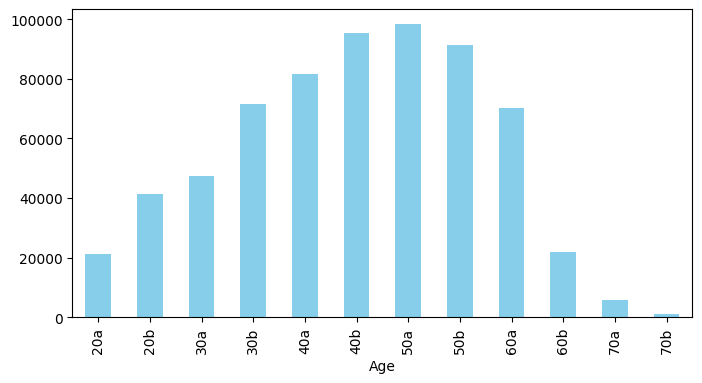

In [ ]:
# Age - 60대 이상 고령은 거의 없음
age_count = train_a['Age'].value_counts().sort_index()

plt.figure(figsize=(8, 4))

age_count.plot(kind='bar', color='skyblue')
plt.show()

<Figure size 800x400 with 0 Axes>

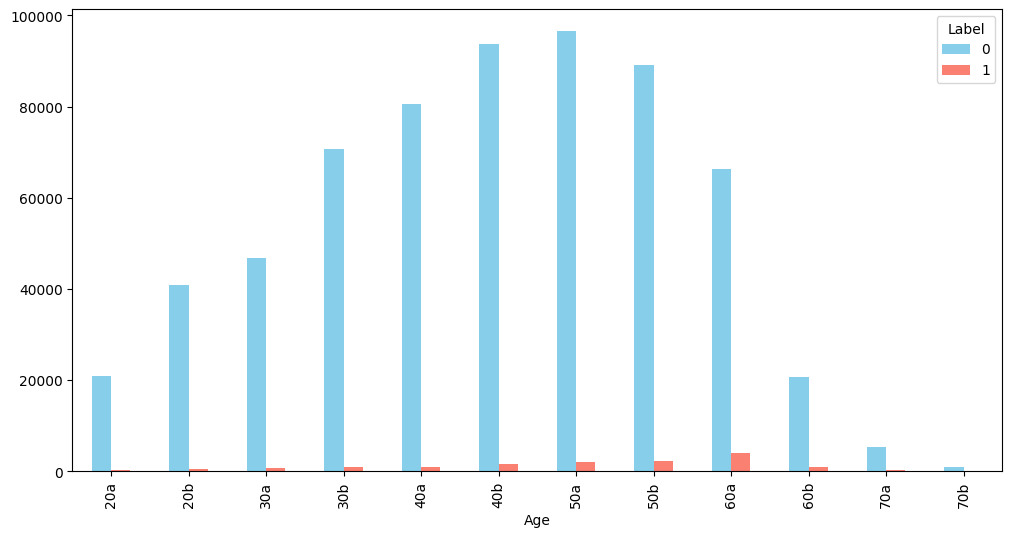

In [ ]:
# Age - Label
# 전체 분포와 비슷한 분포를 가지는 것으로 보임
grouped_age_label = train_a.groupby(['Age', 'Label']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 4))

grouped_age_label.plot(kind="bar", figsize=(12,6), color=["skyblue","salmon"])
plt.show()

<Figure size 800x400 with 0 Axes>

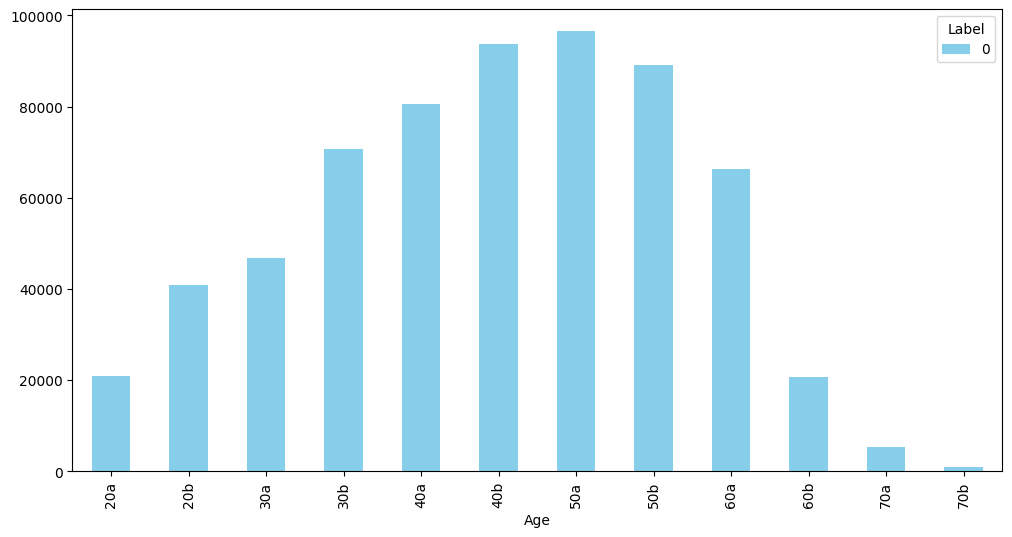

In [ ]:
# Age - Label(0)
# Label -> 0 인 데이터가 매우 많기 때문에 전체 분포와 비슷함
grouped_age_label = train_a[train_a['Label'] == 0].groupby(['Age', 'Label']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 4))

grouped_age_label.plot(kind="bar", figsize=(12,6), color=["skyblue","salmon"])
plt.show()

<Figure size 800x400 with 0 Axes>

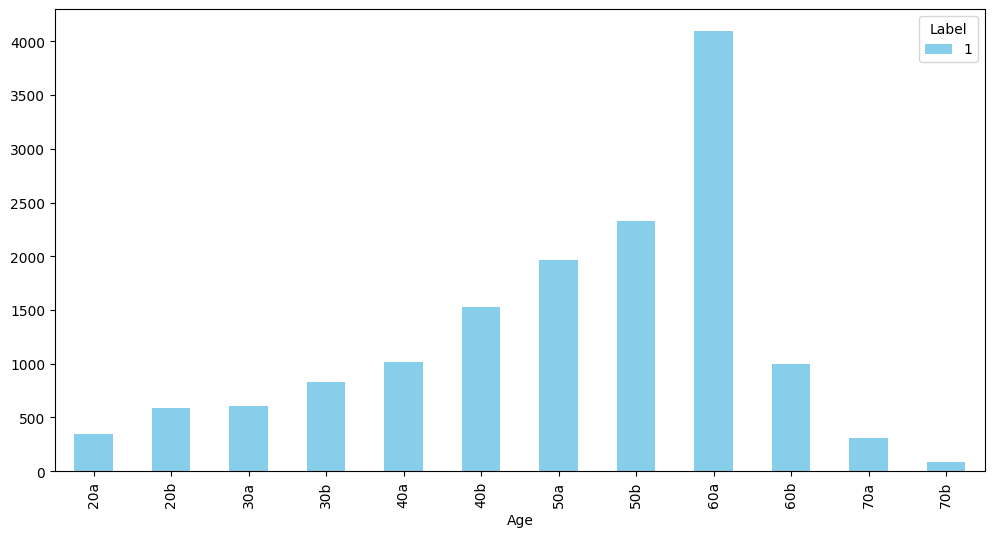

In [ ]:
# Age - Label(1)
# 연령대가 높아질수록 증가하는 경향
# 특히 60대에서 폭발적으로 증가함
grouped_age_label = train_a[train_a['Label'] == 1].groupby(['Age', 'Label']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 4))

grouped_age_label.plot(kind="bar", figsize=(12,6), color=["skyblue","salmon"])
plt.show()

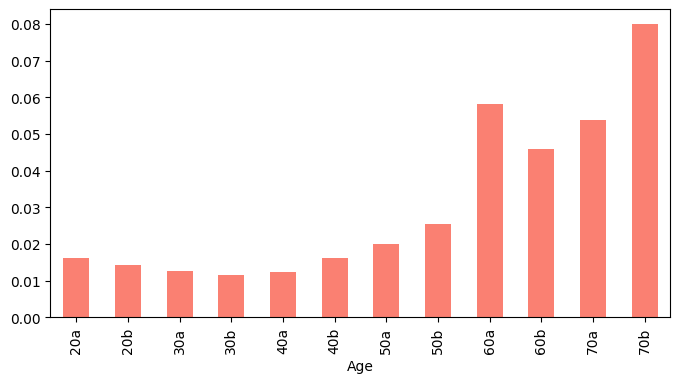

In [ ]:
# 각 연령대 응시자 수 별 Label = 1 비율
# 일단 연령대가 60대에 접어들면 위험군에 속할 확률 ↑
age_label_ratio = train_a.groupby("Age")["Label"].mean()

plt.figure(figsize=(8, 4))
age_label_ratio.plot(kind="bar", color="salmon")
plt.show()

## **TimeDate**

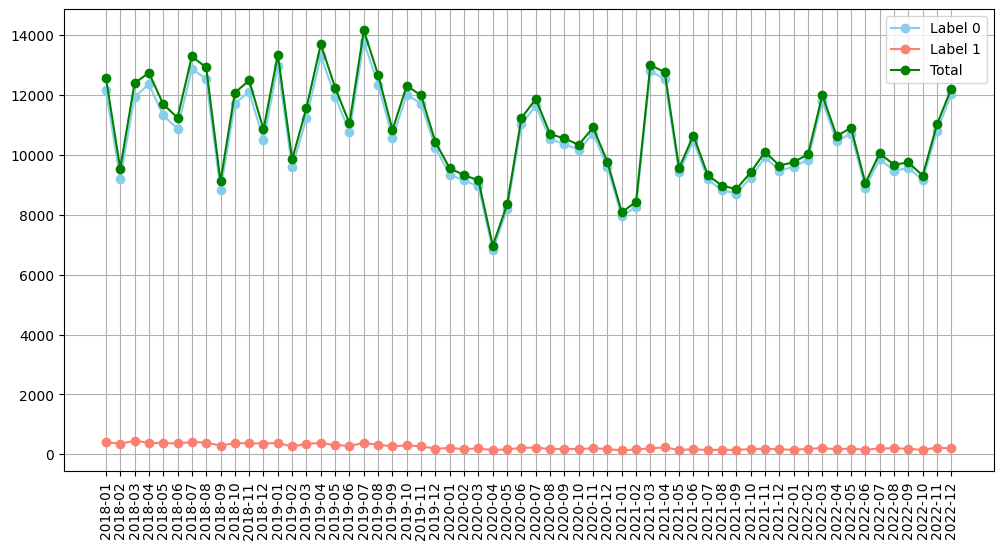

In [ ]:
# Count(Total, Label(0), Label(1)) - TimeDate
train_a['TestDate'] = pd.to_datetime(train_a['TestDate'].astype(str), format='%Y%m')
train_a['TestMonth'] = train_a['TestDate'].dt.to_period('M')

month_label_counts = train_a.groupby(['TestMonth','Label']).size().unstack(fill_value=0)

month_label_counts['Total'] = month_label_counts.sum(axis=1)

plt.figure(figsize=(12,6))
plt.plot(month_label_counts.index.astype(str), month_label_counts[0], marker='o', label='Label 0', color='skyblue')
plt.plot(month_label_counts.index.astype(str), month_label_counts[1], marker='o', label='Label 1', color='salmon')
plt.plot(month_label_counts.index.astype(str), month_label_counts['Total'], marker='o', label='Total', color='green')

plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.show()


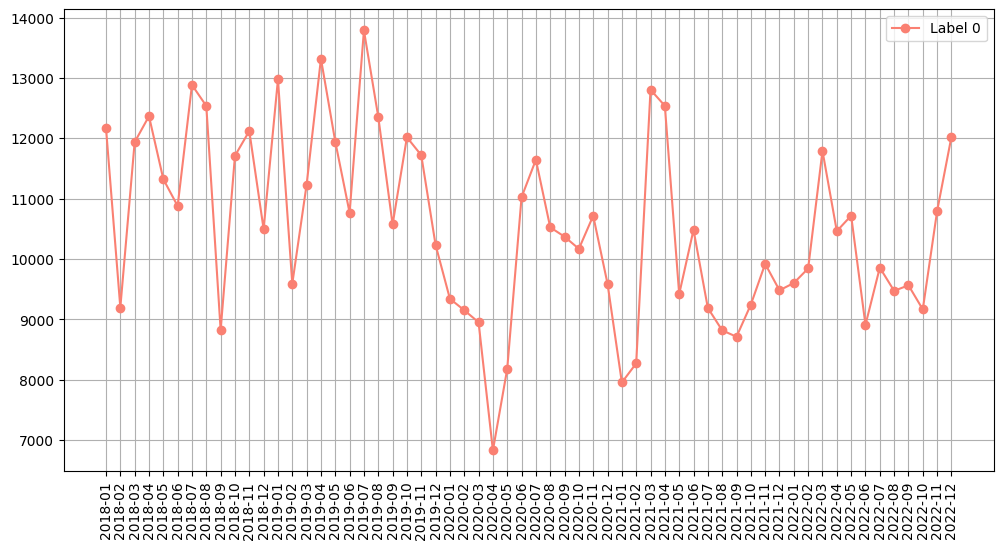

In [ ]:
# Label(0) - TimeDate
# 2020-04에 급격히 줄어드는 것을 제외하면 별다른 특징 X
plt.figure(figsize=(12,6))
plt.plot(month_label_counts.index.astype(str), month_label_counts[0], marker='o', label='Label 0', color='salmon')

plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.show()

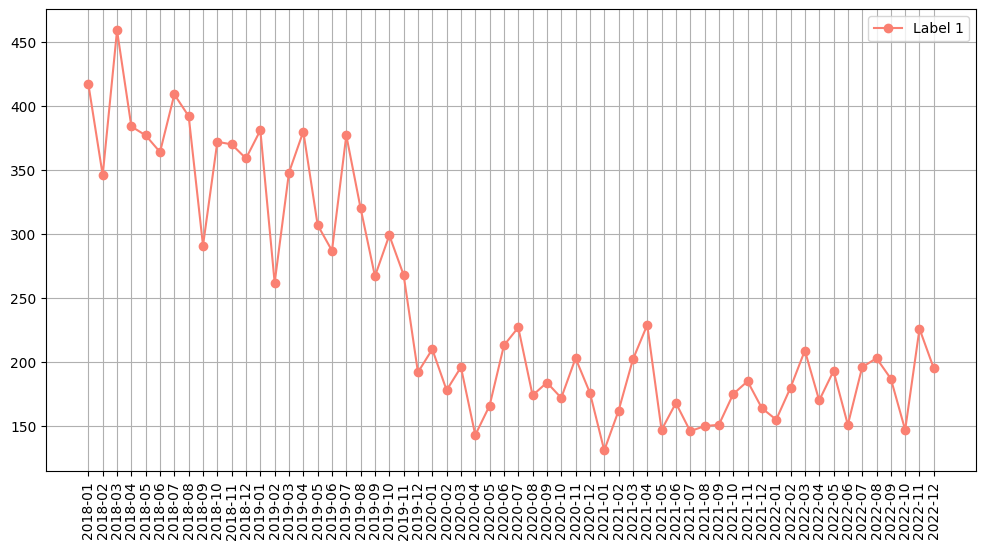

In [ ]:
# Label(1) - TimeDate
# 2020-04까지 줄어드는 추세
plt.figure(figsize=(12,6))
plt.plot(month_label_counts.index.astype(str), month_label_counts[1], marker='o', label='Label 1', color='salmon')

plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.show()

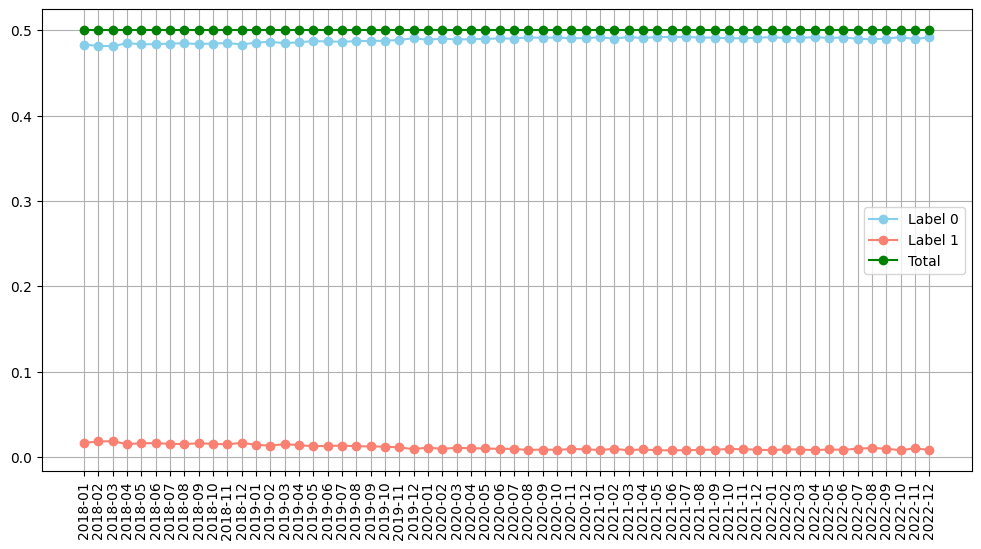

In [ ]:
# 각 월 전체 응시자 대비 Total, Label 0, Label 1 비율
month_label_ratio = month_label_counts.div(month_label_counts.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
plt.plot(month_label_ratio.index.astype(str), month_label_ratio[0], marker='o', label='Label 0', color='skyblue')
plt.plot(month_label_ratio.index.astype(str), month_label_ratio[1], marker='o', label='Label 1', color='salmon')
plt.plot(month_label_ratio.index.astype(str), month_label_ratio['Total'], marker='o', label='Total', color='green')

plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.show()

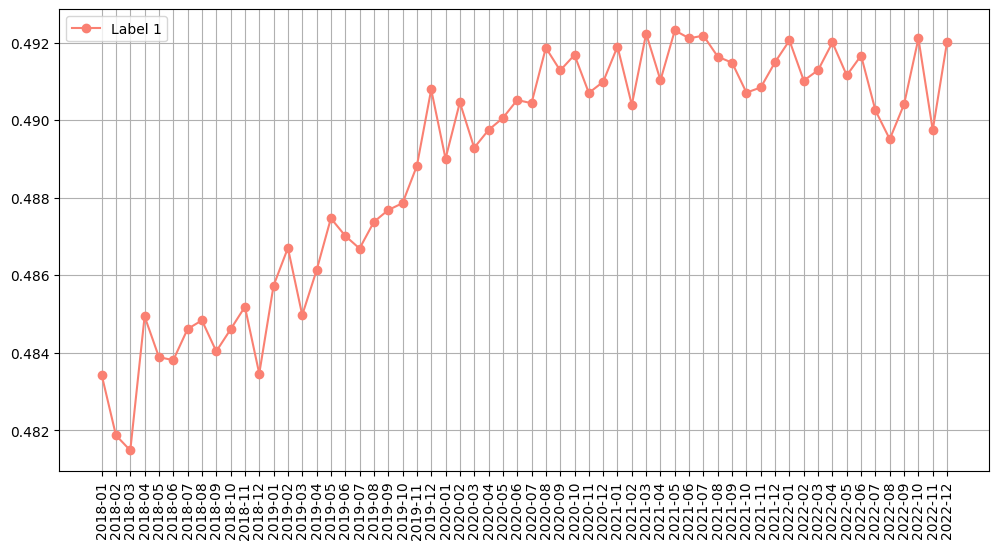

In [ ]:
# 각 월 전체 응시자 대비 Label 0 비율
month_label_ratio = month_label_counts.div(month_label_counts.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
plt.plot(month_label_ratio.index.astype(str), month_label_ratio[0], marker='o', label='Label 1', color='salmon')

plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.show()

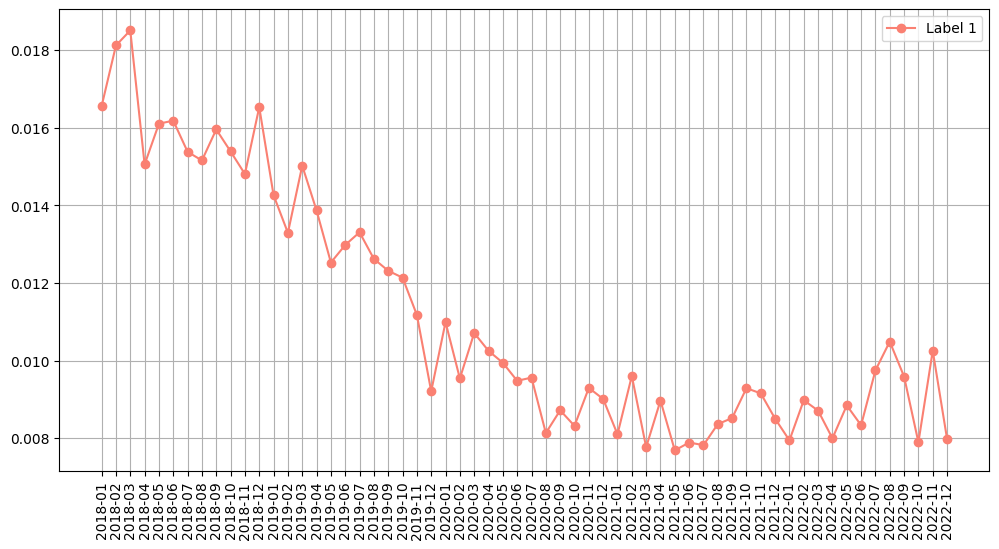

In [ ]:
# 각 월 전체 응시자 대비 Label 1 비율
month_label_ratio = month_label_counts.div(month_label_counts.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
plt.plot(month_label_ratio.index.astype(str), month_label_ratio[1], marker='o', label='Label 1', color='salmon')

plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.show()

## **A1 Test**

In [ ]:
train_a1 = train_a[['Label', 'Age', 'A1-1', 'A1-2', 'A1-3', 'A1-4']]
train_a1.head()

,Label,Age,A1-1,A1-2,A1-3,A1-4
0,0,50a,"2,2,1,2,1,1,2,2,2,1,1,1,1,2,2,2,1,1","3,1,2,2,1,1,1,3,2,3,3,1,2,2,1,3,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","16,-47,-23,-60,-50,-49,-72,-51,-60,-20,-80,-11..."
1,0,60b,"2,2,1,1,1,2,2,2,2,1,2,1,1,1,2,2,1,1","2,2,1,3,2,3,1,2,1,3,3,1,3,2,1,3,1,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-111,-60,-84,-79,-63,-136,-38,-26,29,-88,-25,-..."
2,0,50a,"2,2,1,2,1,1,2,2,2,1,1,1,1,2,2,2,1,1","3,1,2,2,1,1,1,3,2,3,3,1,2,2,1,3,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","16,-47,-23,-60,-50,-49,-72,-51,-60,-20,-80,-11..."
3,0,50a,"1,1,2,2,1,1,2,2,2,2,1,2,1,1,2,1,2,1","3,3,2,2,3,2,1,1,3,3,1,2,1,2,1,1,3,2","0,0,0,0,1,0,0,1,1,0,1,0,1,0,0,0,0,0","-20,30,-32,35,722,-7,-47,597,725,-26,595,35,59..."
4,0,40b,"1,1,2,1,1,2,2,1,2,1,2,2,1,2,1,1,2,2","1,3,2,3,3,1,2,1,3,2,3,1,2,1,1,2,2,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-54,48,-21,150,125,-8,-220,1,-51,4,-77,-34,21,..."


In [ ]:
train_a1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647241 non-null  int64 
 1   Age     647241 non-null  object
 2   A1-1    647241 non-null  object
 3   A1-2    647241 non-null  object
 4   A1-3    647241 non-null  object
 5   A1-4    647241 non-null  object
dtypes: int64(1), object(5)
memory usage: 29.6+ MB


In [ ]:
# 18 trials -> list
train_a1['A1-1'] = train_a1['A1-1'].apply(lambda x: list(map(int, x.split(','))))
train_a1['A1-2'] = train_a1['A1-2'].apply(lambda x: list(map(int, x.split(','))))
train_a1['A1-3'] = train_a1['A1-3'].apply(lambda x: list(map(int, x.split(','))))
train_a1['A1-4'] = train_a1['A1-4'].apply(lambda x: list(map(int, x.split(','))))

### A1-1

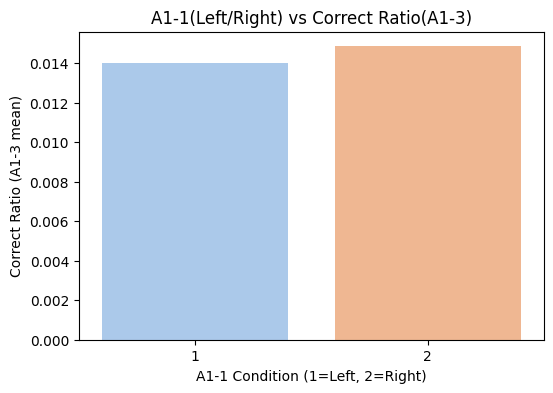

In [ ]:
# A1-1 - A1-3
# 방향에 따른 전체 정답률
# 방향에 따라 전체 정답률은 크게 다르지 않은 것으로 보임
a11_a13 = []
for _, row in train_a1.iterrows():
    for cond, resp in zip(row['A1-1'], row['A1-3']):
        a11_a13.append({'A1-1': cond, 'A1-3': resp, 'Label': row['Label']})
a11_a13 = pd.DataFrame(a11_a13)

plt.figure(figsize=(6,4))
sns.barplot(data=a11_a13, x='A1-1', y='A1-3', estimator=np.mean, ci=None, palette='pastel')
plt.title('A1-1(Left/Right) vs Correct Ratio(A1-3)')
plt.xlabel('A1-1 Condition (1=Left, 2=Right)')
plt.ylabel('Correct Ratio (A1-3 mean)')
plt.show()

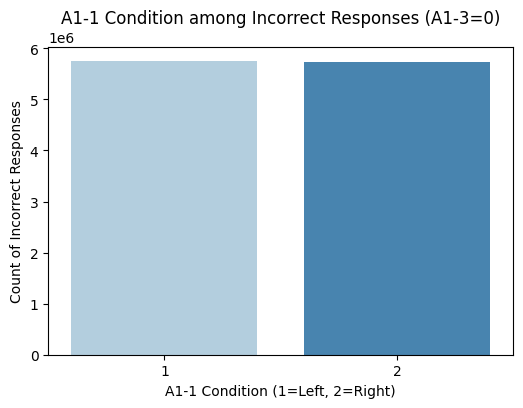

In [ ]:
# A1-3이 0인 검사자들에 대한 정답률
# 방향은 정답률에 크게 영향을 끼치지 않는것으로 보임
a11_a13_resp0 = a11_a13[a11_a13['A1-3'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a11_a13_resp0, x='A1-1', palette='Blues')
plt.title('A1-1 Condition among Incorrect Responses (A1-3=0)')
plt.xlabel('A1-1 Condition (1=Left, 2=Right)')
plt.ylabel('Count of Incorrect Responses')
plt.show()

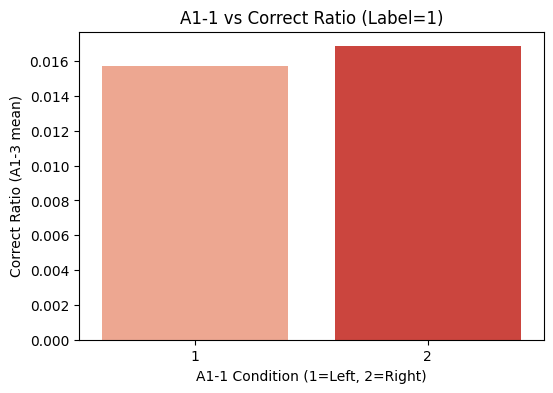

In [ ]:
# Label = 1인 데이터만
# 방향은 Label 결정에 크게 영향을 끼치지 않는것으로 보임
a11_a13_label1 = a11_a13[a11_a13['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a11_a13_label1, x='A1-1', y='A1-3', estimator=np.mean, ci=None, palette='Reds')
plt.title('A1-1 vs Correct Ratio (Label=1)')
plt.xlabel('A1-1 Condition (1=Left, 2=Right)')
plt.ylabel('Correct Ratio (A1-3 mean)')
plt.show()

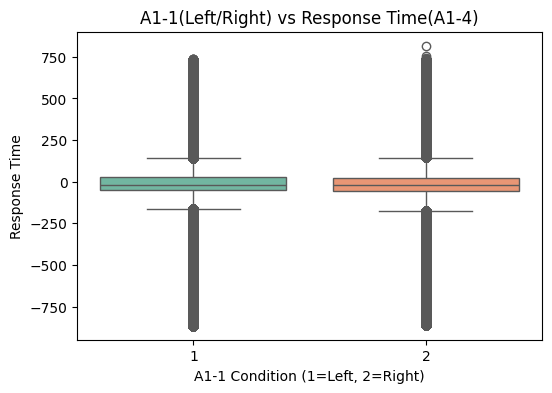

In [ ]:
# 방향에 따른 반응 속도 분포
# 방향에 따라 반응 속도는 크게 달라지지 않는 것으로 보임
a11_a14 = []
for _, row in train_a1.iterrows():
    for cond, rt in zip(row['A1-1'], row['A1-4']):
        a11_a14.append({'A1-1': cond, 'A1-4': rt})
a11_a14 = pd.DataFrame(a11_a14)

plt.figure(figsize=(6,4))
sns.boxplot(data=a11_a14, x='A1-1', y='A1-4', palette='Set2')
plt.title('A1-1(Left/Right) vs Response Time(A1-4)')
plt.xlabel('A1-1 Condition (1=Left, 2=Right)')
plt.ylabel('Response Time')
plt.show()


In [ ]:
summary_a114 = a11_a14.groupby("A1-1")["A1-4"].describe().T
display(summary_a114)

A1-1,1,2
count,5.825169e+06,5.825169e+06
mean,-8.349323e+00,-1.013972e+01
std,9.912558e+01,1.010263e+02
min,-8.650000e+02,-8.620000e+02
25%,-5.000000e+01,-5.500000e+01
50%,-2.000000e+01,-2.100000e+01
75%,2.600000e+01,2.500000e+01
max,7.380000e+02,8.170000e+02


### A1-2

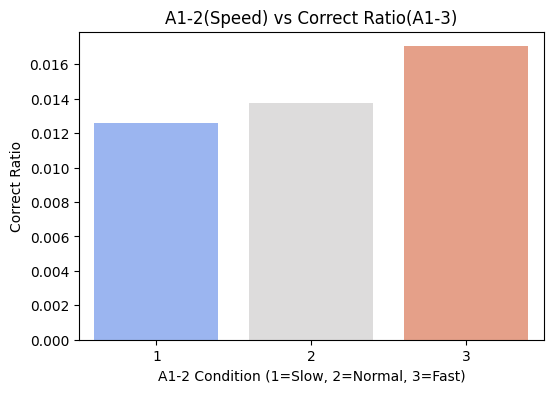

In [ ]:
# 속도에 따른 전체 검사자 정답률
# 속도가 빠를 수록 정답률이 높아지는 것으로 보임
a12_a13 = []
for _, row in train_a1.iterrows():
    for cond, resp in zip(row['A1-2'], row['A1-3']):
        a12_a13.append({'A1-2': cond, 'A1-3': resp, 'Label': row['Label']})
a12_a13 = pd.DataFrame(a12_a13)

plt.figure(figsize=(6,4))
sns.barplot(data=a12_a13, x='A1-2', y='A1-3', estimator=np.mean, ci=None, palette='coolwarm')
plt.title('A1-2(Speed) vs Correct Ratio(A1-3)')
plt.xlabel('A1-2 Condition (1=Slow, 2=Normal, 3=Fast)')
plt.ylabel('Correct Ratio')
plt.show()

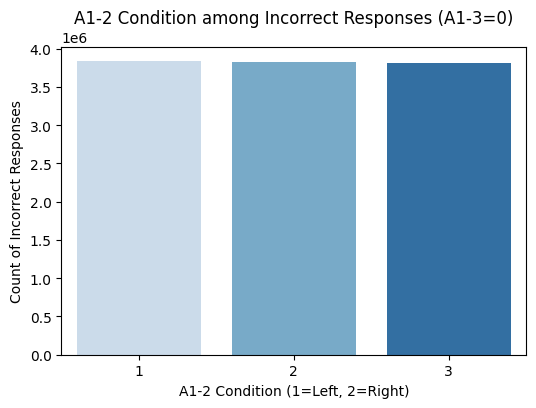

In [ ]:
# A1-3이 0인 검사자들에 대한 정답률
# 그러나 속도에 따라서 오답수는 비슷함
a12_a13_resp0 = a12_a13[a12_a13['A1-3'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a12_a13_resp0, x='A1-2', palette='Blues')
plt.title('A1-2 Condition among Incorrect Responses (A1-3=0)')
plt.xlabel('A1-2 Condition (1=Left, 2=Right)')
plt.ylabel('Count of Incorrect Responses')
plt.show()


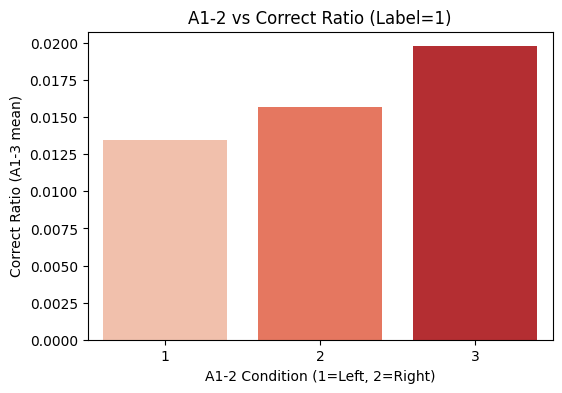

In [ ]:
# Label = 1인 데이터만
# 속도가 빠를 수록 Label - 1 증가
a12_a13_label1 = a12_a13[a12_a13['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a12_a13_label1, x='A1-2', y='A1-3', estimator=np.mean, ci=None, palette='Reds')
plt.title('A1-2 vs Correct Ratio (Label=1)')
plt.xlabel('A1-2 Condition (1=Left, 2=Right)')
plt.ylabel('Correct Ratio (A1-3 mean)')
plt.show()

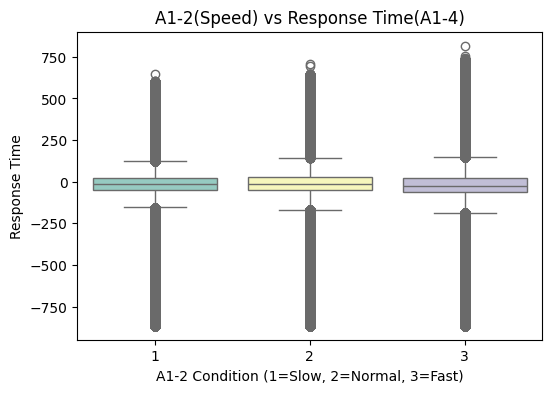

In [ ]:
# A1-2 - A1-4
# 속도가 빨라질수록 반응 속도가 느려지는 것으로 보임
a12_a14 = []
for _, row in train_a1.iterrows():
    for cond, rt in zip(row['A1-2'], row['A1-4']):
        a12_a14.append({'A1-2': cond, 'A1-4': rt})
a12_a14 = pd.DataFrame(a12_a14)

plt.figure(figsize=(6,4))
sns.boxplot(data=a12_a14, x='A1-2', y='A1-4', palette='Set3')
plt.title('A1-2(Speed) vs Response Time(A1-4)')
plt.xlabel('A1-2 Condition (1=Slow, 2=Normal, 3=Fast)')
plt.ylabel('Response Time')
plt.show()


In [ ]:
summary_a124 = a12_a14.groupby("A1-2")["A1-4"].describe().T
display(summary_a124)

A1-2,1,2,3
count,3.883446e+06,3.883446e+06,3.883446e+06
mean,-8.120404e+00,-5.035353e+00,-1.457780e+01
std,8.974037e+01,9.680096e+01,1.121584e+02
min,-8.650000e+02,-8.650000e+02,-8.650000e+02
25%,-4.900000e+01,-5.100000e+01,-6.200000e+01
50%,-1.300000e+01,-1.400000e+01,-2.500000e+01
75%,2.100000e+01,2.700000e+01,2.200000e+01
max,6.500000e+02,7.070000e+02,8.170000e+02


### A1-3

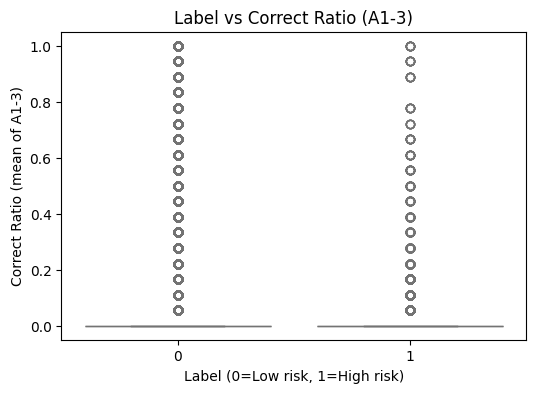

In [ ]:
# 참가자 단위로 평균 정답률 계산
train_a1['A1-3_ratio'] = train_a1['A1-3'].apply(lambda x: np.mean(x))

plt.figure(figsize=(6,4))
sns.boxplot(data=train_a1, x='Label', y='A1-3_ratio', palette='pastel')
plt.title('Label vs Correct Ratio (A1-3)')
plt.xlabel('Label (0=Low risk, 1=High risk)')
plt.ylabel('Correct Ratio (mean of A1-3)')
plt.show()

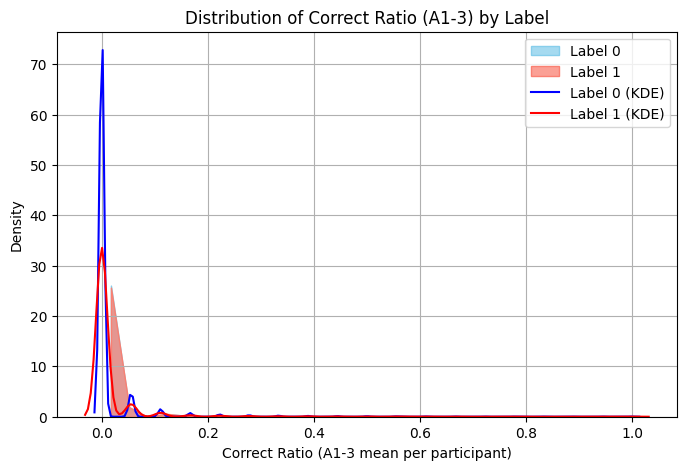

In [ ]:
# KDE Plot
# 이렇게 보면 Label 0, 1 둘다 정답률 0에 많이 모여있음
# 다른 검사의 정답률과 함께 봐야할듯
plt.figure(figsize=(8,5))

bins = np.linspace(0, 1, 30)

sns.histplot(train_a1[train_a1['Label'] == 0]['A1-3_ratio'],
             bins=bins, kde=False, stat='density', color='skyblue', label='Label 0', element='poly')
sns.histplot(train_a1[train_a1['Label'] == 1]['A1-3_ratio'],
             bins=bins, kde=False, stat='density', color='salmon', label='Label 1', element='poly')

sns.kdeplot(train_a1[train_a1['Label'] == 0]['A1-3_ratio'], color='blue', label='Label 0 (KDE)')
sns.kdeplot(train_a1[train_a1['Label'] == 1]['A1-3_ratio'], color='red', label='Label 1 (KDE)')

plt.title('Distribution of Correct Ratio (A1-3) by Label')
plt.xlabel('Correct Ratio (A1-3 mean per participant)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

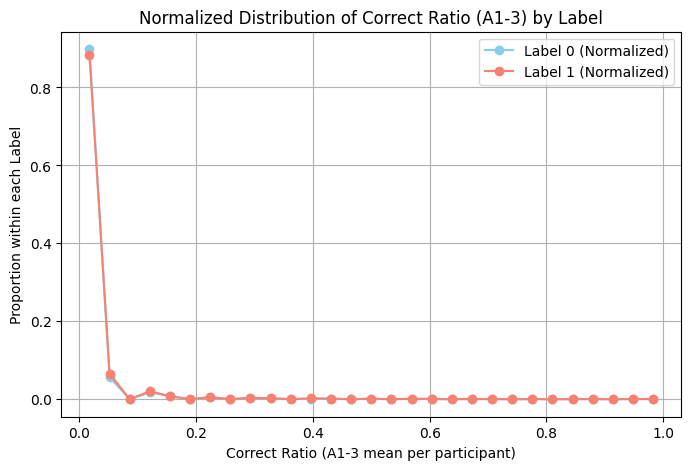

In [ ]:
# Normalized
bins = np.linspace(0, 1, 30)
counts_0, _ = np.histogram(train_a1[train_a1['Label'] == 0]['A1-3_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a1[train_a1['Label'] == 1]['A1-3_ratio'], bins=bins)

# 비율(정규화)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', label='Label 0 (Normalized)', color='skyblue')
plt.plot(bin_centers, counts_1, marker='o', label='Label 1 (Normalized)', color='salmon')

plt.title('Normalized Distribution of Correct Ratio (A1-3) by Label')
plt.xlabel('Correct Ratio (A1-3 mean per participant)')
plt.ylabel('Proportion within each Label')
plt.legend()
plt.grid(True)
plt.show()

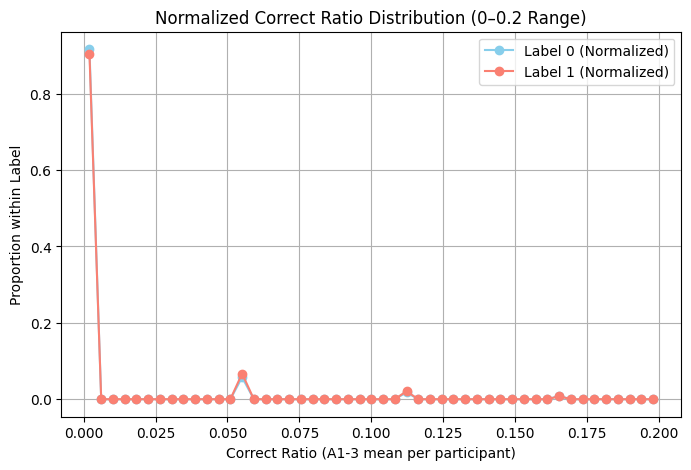

In [ ]:
# 검사자가 많이 몰려있는 0 ~ 0.2 구간 확인
# 대부분의 검사자가 정답률 0인 구간에 많이 분포...?
bins = np.linspace(0, 0.2, 50)

counts_0, _ = np.histogram(train_a1[train_a1['Label'] == 0]['A1-3_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a1[train_a1['Label'] == 1]['A1-3_ratio'], bins=bins)

counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', color='skyblue', label='Label 0 (Normalized)')
plt.plot(bin_centers, counts_1, marker='o', color='salmon', label='Label 1 (Normalized)')

plt.title('Normalized Correct Ratio Distribution (0–0.2 Range)')
plt.xlabel('Correct Ratio (A1-3 mean per participant)')
plt.ylabel('Proportion within Label')
plt.legend()
plt.grid(True)
plt.show()

### Correlation

In [ ]:
# A1 만으론 Label과의 뚜렷한 상관관계가 보이지 않음
def extract_a1_features(df):
    df = df.copy()
    for col in ['A1-1','A1-2','A1-3','A1-4']:
        df[col] = df[col].apply(lambda x: list(map(float, str(x).split(','))) if isinstance(x, str) else x)

    df['A1-1_mean'] = df['A1-1'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A1-2_mean'] = df['A1-2'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A1-3_mean'] = df['A1-3'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A1-4_mean'] = df['A1-4'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)

    df['A1-4_std']  = df['A1-4'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)
    df['A1-4_min']  = df['A1-4'].apply(lambda x: np.min(x) if isinstance(x, list) else np.nan)
    df['A1-4_max']  = df['A1-4'].apply(lambda x: np.max(x) if isinstance(x, list) else np.nan)

    return df[['Label','A1-1_mean','A1-2_mean','A1-3_mean','A1-4_mean','A1-4_std','A1-4_min','A1-4_max']]


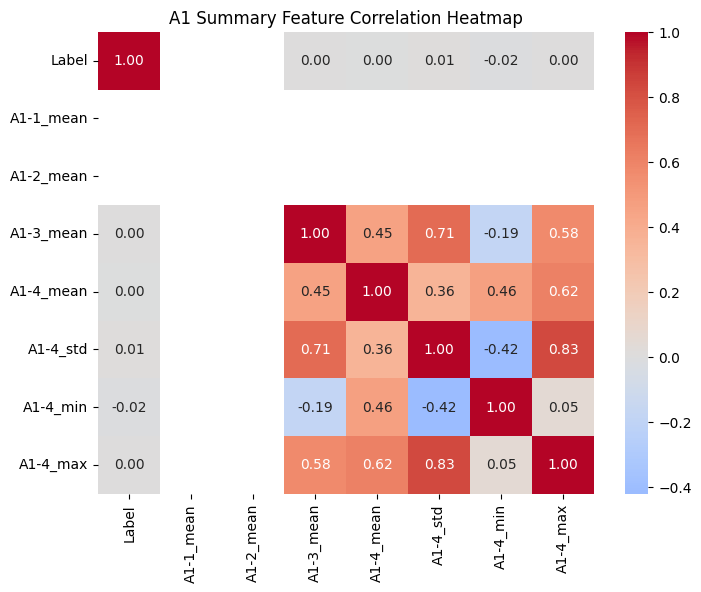

In [ ]:
a1_features = extract_a1_features(train_a1)

corr = a1_features.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A1 Summary Feature Correlation Heatmap")
plt.show()

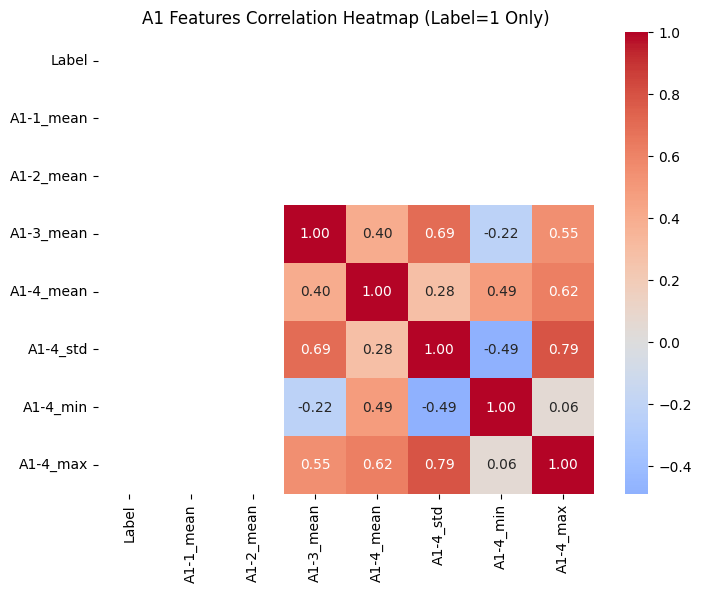

In [ ]:
# Label 1인 데이터만 필터링
a1_features_label1 = extract_a1_features(train_a1[train_a1['Label'] == 1])

corr_label1 = a1_features_label1.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_label1, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A1 Features Correlation Heatmap (Label=1 Only)")
plt.show()

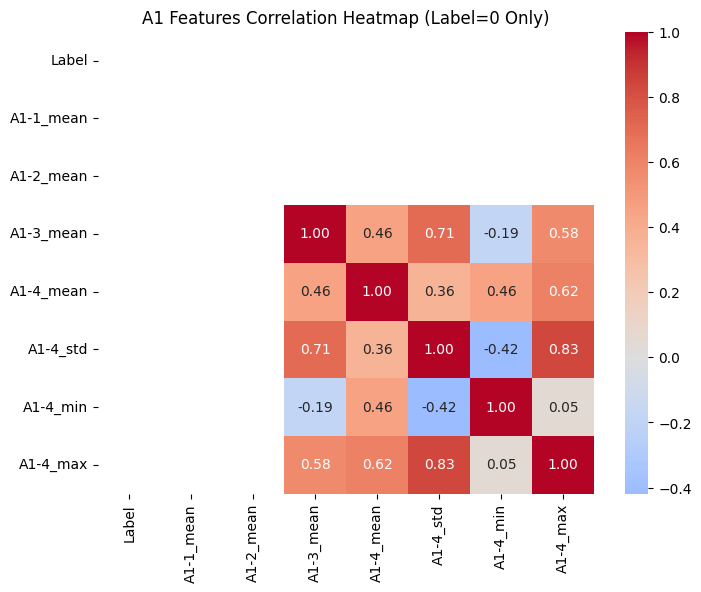

In [ ]:
# Label 1인 데이터만 필터링
a1_features_label1 = extract_a1_features(train_a1[train_a1['Label'] == 0])

corr_label1 = a1_features_label1.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_label1, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A1 Features Correlation Heatmap (Label=0 Only)")
plt.show()

## **A2 Test**

In [ ]:
train_a2 = train_a[['Label', 'Age', 'A2-1', 'A2-2', 'A2-3', 'A2-4']]
train_a2.head()

,Label,Age,A2-1,A2-2,A2-3,A2-4
0,0,50a,"2,3,3,2,2,1,2,1,3,3,1,3,1,1,3,1,2,2","1,1,3,2,2,1,1,2,2,2,2,3,3,3,1,1,3,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-80,-107,-111,-94,-74,-68,-33,-120,-74,-95,-45..."
1,0,60b,"3,2,3,2,2,1,1,3,1,1,2,2,1,3,2,3,3,1","2,3,1,1,2,1,2,3,3,1,1,2,3,3,3,2,1,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","8,-28,50,-40,-100,-91,-68,-8,-132,-56,1,7,-115..."
2,0,50a,"2,3,3,2,2,1,2,1,3,3,1,3,1,1,3,1,2,2","1,1,3,2,2,1,1,2,2,2,2,3,3,3,1,1,3,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-80,-107,-111,-94,-74,-68,-33,-120,-74,-95,-45..."
3,0,50a,"2,3,2,3,3,2,1,1,3,3,2,3,2,1,1,2,1,1","3,2,1,2,1,2,2,1,3,3,2,1,1,2,1,3,3,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-1,40,-67,-44,-50,-48,-2,-62,-61,-15,-27,-57,-..."
4,0,40b,"2,1,3,2,1,3,1,1,3,3,2,3,2,2,1,3,2,1","2,3,2,1,2,2,1,1,3,1,3,3,2,1,2,1,3,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","36,-45,16,1,-51,16,-2,42,47,-65,14,-23,29,-19,..."


In [ ]:
train_a2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647241 non-null  int64 
 1   Age     647241 non-null  object
 2   A2-1    647240 non-null  object
 3   A2-2    647240 non-null  object
 4   A2-3    647240 non-null  object
 5   A2-4    647240 non-null  object
dtypes: int64(1), object(5)
memory usage: 29.6+ MB


In [ ]:
train_a2 = train_a2.dropna()
train_a2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 647240 entries, 0 to 647240
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647240 non-null  int64 
 1   Age     647240 non-null  object
 2   A2-1    647240 non-null  object
 3   A2-2    647240 non-null  object
 4   A2-3    647240 non-null  object
 5   A2-4    647240 non-null  object
dtypes: int64(1), object(5)
memory usage: 34.6+ MB


In [ ]:
# 18 trials -> list
train_a2['A2-1'] = train_a2['A2-1'].apply(lambda x: list(map(int, x.split(','))))
train_a2['A2-2'] = train_a2['A2-2'].apply(lambda x: list(map(int, x.split(','))))
train_a2['A2-3'] = train_a2['A2-3'].apply(lambda x: list(map(int, x.split(','))))
train_a2['A2-4'] = train_a2['A2-4'].apply(lambda x: list(map(int, x.split(','))))

### A2-1

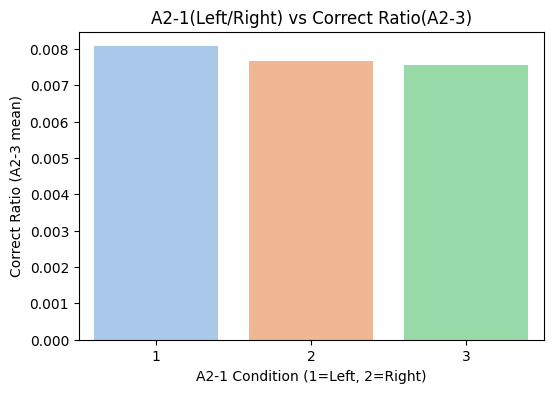

In [ ]:
#A2-1 - A2-3
a21_a23 = []
for _, row in train_a2.iterrows():
    for cond, resp in zip(row['A2-1'], row['A2-3']):
        a21_a23.append({'A2-1': cond, 'A2-3': resp, 'Label': row['Label']})
a21_a23 = pd.DataFrame(a21_a23)

plt.figure(figsize=(6,4))
sns.barplot(data=a21_a23, x='A2-1', y='A2-3', estimator=np.mean, ci=None, palette='pastel')
plt.title('A2-1(Left/Right) vs Correct Ratio(A2-3)')
plt.xlabel('A2-1 Condition')
plt.ylabel('Correct Ratio (A2-3 mean)')
plt.show()

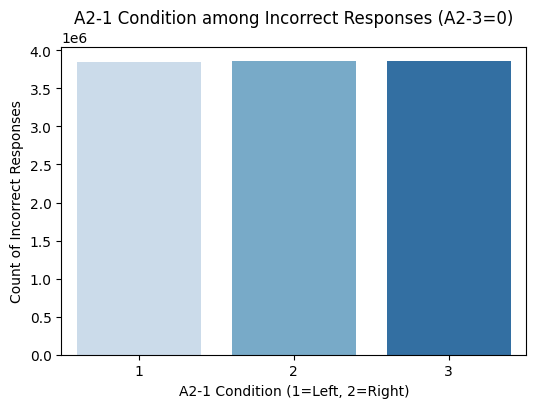

In [ ]:
# A2-3이 0인 응답만
a21_a23_resp0 = a21_a23[a21_a23['A2-3'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a21_a23_resp0, x='A2-1', palette='Blues')
plt.title('A2-1 Condition among Incorrect Responses (A2-3=0)')
plt.xlabel('A2-1 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


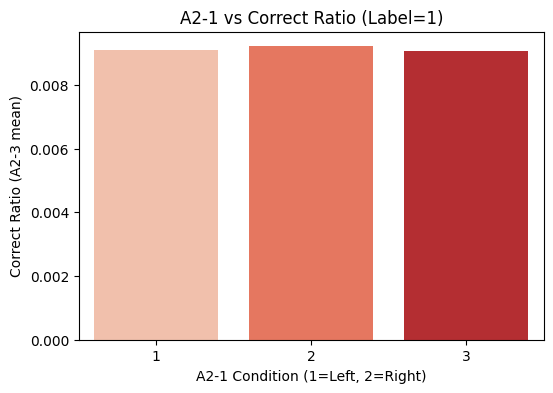

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A2-1와 관계없음 (별로 중요하지 않음)
a21_a23_label1 = a21_a23[a21_a23['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a21_a23_label1, x='A2-1', y='A2-3', estimator=np.mean, ci=None, palette='Reds')
plt.title('A2-1 vs Correct Ratio (Label=1)')
plt.xlabel('A2-1 Condition')
plt.ylabel('Correct Ratio (A2-3 mean)')
plt.show()

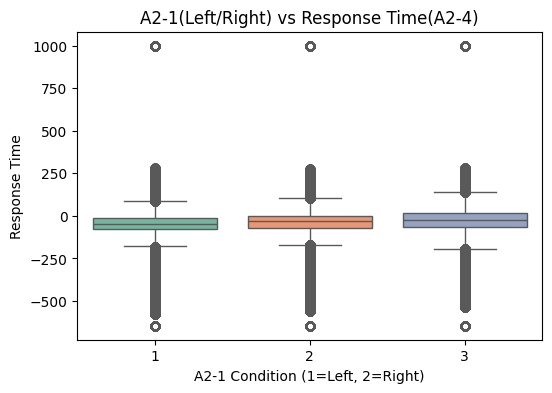

In [ ]:
#A2-1 - A2-4
a21_a24 = []
for _, row in train_a2.iterrows():
    for cond, rt in zip(row['A2-1'], row['A2-4']):
        a21_a24.append({'A2-1': cond, 'A2-4': rt})
a21_a24 = pd.DataFrame(a21_a24)

plt.figure(figsize=(6,4))
sns.boxplot(data=a21_a24, x='A2-1', y='A2-4', palette='Set2')
plt.title('A2-1(Left/Right) vs Response Time(A2-4)')
plt.xlabel('A2-1 Condition (1=Left, 2=Right)')
plt.ylabel('Response Time')
plt.show()


In [ ]:
summary_a214 = a21_a24.groupby("A2-1")["A2-4"].describe().T
display(summary_a214)

A2-1,1,2,3
count,3.883440e+06,3.883440e+06,3.883440e+06
mean,-4.453860e+01,-3.184056e+01,-2.266207e+01
std,9.238241e+01,9.105169e+01,9.324619e+01
min,-6.450000e+02,-6.450000e+02,-6.450000e+02
25%,-8.000000e+01,-6.900000e+01,-6.800000e+01
50%,-4.500000e+01,-3.300000e+01,-2.200000e+01
75%,-1.400000e+01,0.000000e+00,1.600000e+01
max,9.990000e+02,9.990000e+02,9.990000e+02


### A2-2

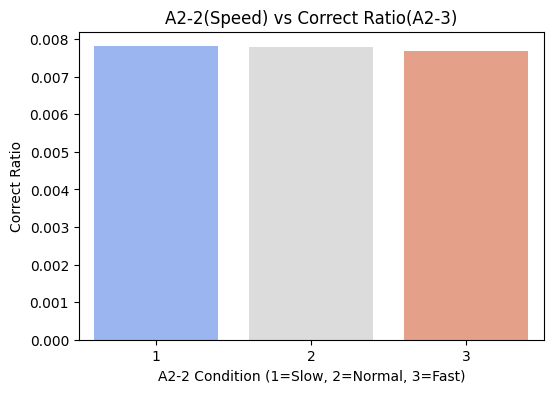

In [ ]:
#A2-2 - A2-3
a22_a23 = []
for _, row in train_a2.iterrows():
    for cond, resp in zip(row['A2-2'], row['A2-3']):
        a22_a23.append({'A2-2': cond, 'A2-3': resp, 'Label': row['Label']})
a22_a23 = pd.DataFrame(a22_a23)

plt.figure(figsize=(6,4))
sns.barplot(data=a22_a23, x='A2-2', y='A2-3', estimator=np.mean, ci=None, palette='coolwarm')
plt.title('A2-2(Speed) vs Correct Ratio(A2-3)')
plt.xlabel('A2-2 Condition (1=Slow, 2=Normal, 3=Fast)')
plt.ylabel('Correct Ratio')
plt.show()

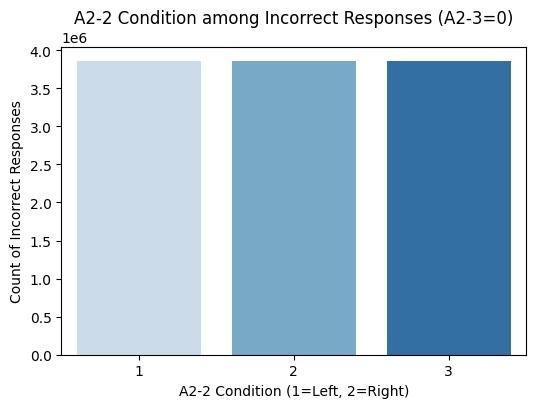

In [ ]:
# A2-3이 0인 응답만
a22_a23_resp0 = a22_a23[a22_a23['A2-3'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a22_a23_resp0, x='A2-2', palette='Blues')
plt.title('A2-2 Condition among Incorrect Responses (A2-3=0)')
plt.xlabel('A2-2 Condition (1=Left, 2=Right)')
plt.ylabel('Count of Incorrect Responses')
plt.show()


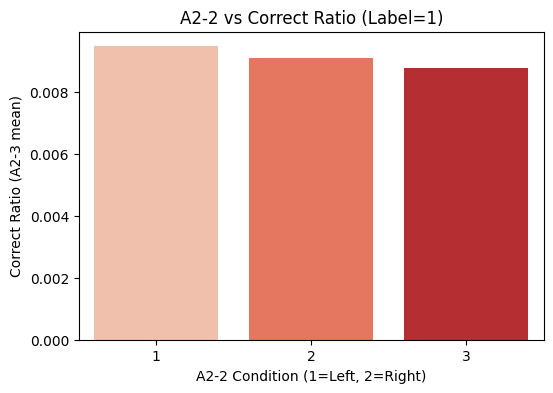

In [ ]:
# Label = 1인 데이터만
# 속도가 빠를 수록 Label - 1 증가
a22_a23_label1 = a22_a23[a22_a23['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a22_a23_label1, x='A2-2', y='A2-3', estimator=np.mean, ci=None, palette='Reds')
plt.title('A2-2 vs Correct Ratio (Label=1)')
plt.xlabel('A2-2 Condition (1=Left, 2=Right)')
plt.ylabel('Correct Ratio (A2-3 mean)')
plt.show()

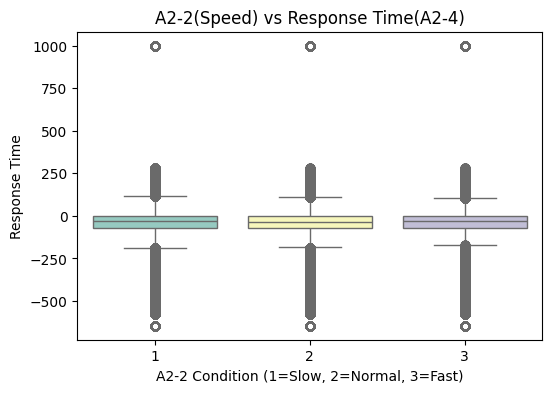

In [ ]:
#A2-2 - A2-4
a22_a24 = []
for _, row in train_a2.iterrows():
    for cond, rt in zip(row['A2-2'], row['A2-4']):
        a22_a24.append({'A2-2': cond, 'A2-4': rt})
a22_a24 = pd.DataFrame(a22_a24)

plt.figure(figsize=(6,4))
sns.boxplot(data=a22_a24, x='A2-2', y='A2-4', palette='Set3')
plt.title('A2-2(Speed) vs Response Time(A2-4)')
plt.xlabel('A2-2 Condition (1=Slow, 2=Normal, 3=Fast)')
plt.ylabel('Response Time')
plt.show()


In [ ]:
summary_a224 = a22_a24.groupby("A2-2")["A2-4"].describe().T
display(summary_a224)

A2-2,1,2,3
count,3.883440e+06,3.883440e+06,3.883440e+06
mean,-3.335422e+01,-3.337871e+01,-3.230829e+01
std,9.285201e+01,9.272753e+01,9.241476e+01
min,-6.450000e+02,-6.450000e+02,-6.450000e+02
25%,-7.400000e+01,-7.400000e+01,-6.900000e+01
50%,-3.300000e+01,-3.400000e+01,-3.300000e+01
75%,2.000000e+00,0.000000e+00,0.000000e+00
max,9.990000e+02,9.990000e+02,9.990000e+02


### A2-3

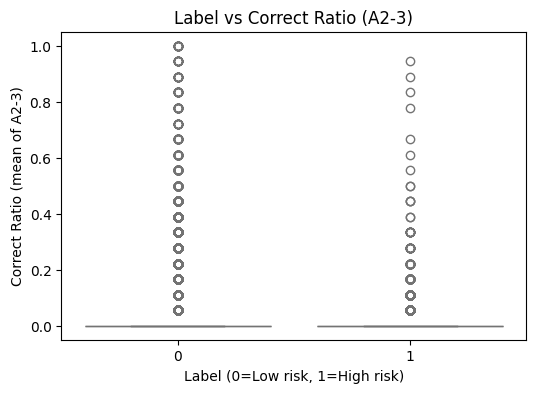

In [ ]:
# 참가자 단위로 평균 정답률 계산
train_a2['A2-3_ratio'] = train_a2['A2-3'].apply(lambda x: np.mean(x))

plt.figure(figsize=(6,4))
sns.boxplot(data=train_a2, x='Label', y='A2-3_ratio', palette='pastel')
plt.title('Label vs Correct Ratio (A2-3)')
plt.xlabel('Label (0=Low risk, 1=High risk)')
plt.ylabel('Correct Ratio (mean of A2-3)')
plt.show()

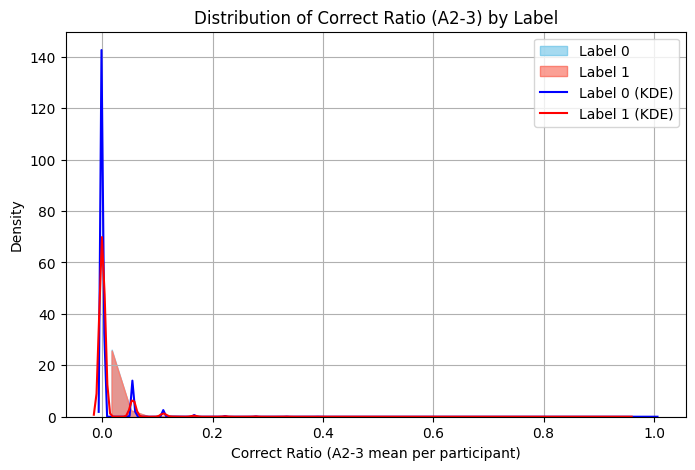

In [ ]:
# KDE Plot
# 이렇게 보면 Label 0, 1 둘다 정답률 0에 많이 모여있음
# 다른 검사의 정답률과 함께 봐야할듯
plt.figure(figsize=(8,5))

# 히스토그램을 밀도(density=True)로 계산해서 분포 비교
bins = np.linspace(0, 1, 30)  # 정답률 구간 0~1을 30개 구간으로 나눔

sns.histplot(train_a2[train_a2['Label'] == 0]['A2-3_ratio'],
             bins=bins, kde=False, stat='density', color='skyblue', label='Label 0', element='poly')
sns.histplot(train_a2[train_a2['Label'] == 1]['A2-3_ratio'],
             bins=bins, kde=False, stat='density', color='salmon', label='Label 1', element='poly')

# 각 히스토그램의 중앙을 선으로 연결
sns.kdeplot(train_a2[train_a2['Label'] == 0]['A2-3_ratio'], color='blue', label='Label 0 (KDE)')
sns.kdeplot(train_a2[train_a2['Label'] == 1]['A2-3_ratio'], color='red', label='Label 1 (KDE)')

plt.title('Distribution of Correct Ratio (A2-3) by Label')
plt.xlabel('Correct Ratio (A2-3 mean per participant)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

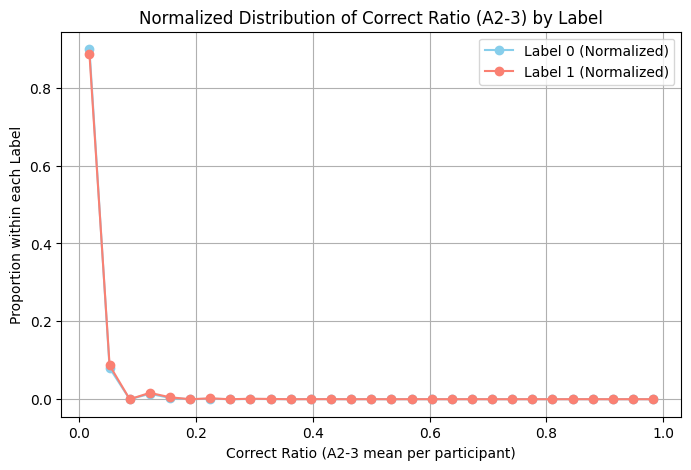

In [ ]:
# Normalized
bins = np.linspace(0, 1, 30)
counts_0, _ = np.histogram(train_a2[train_a2['Label'] == 0]['A2-3_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a2[train_a2['Label'] == 1]['A2-3_ratio'], bins=bins)

# 비율(정규화)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', label='Label 0 (Normalized)', color='skyblue')
plt.plot(bin_centers, counts_1, marker='o', label='Label 1 (Normalized)', color='salmon')

plt.title('Normalized Distribution of Correct Ratio (A2-3) by Label')
plt.xlabel('Correct Ratio (A2-3 mean per participant)')
plt.ylabel('Proportion within each Label')
plt.legend()
plt.grid(True)
plt.show()

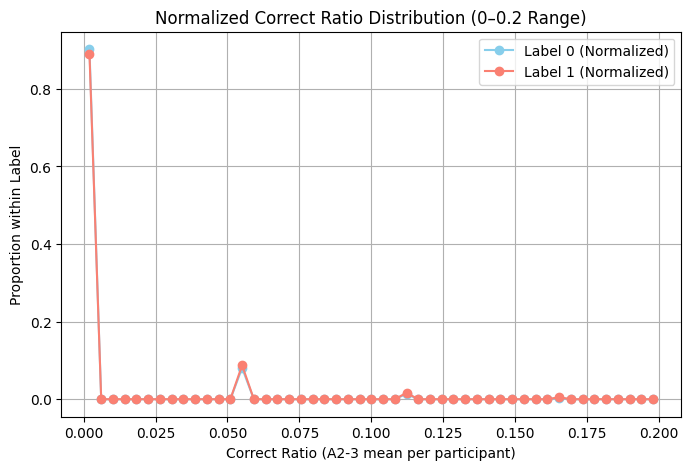

In [ ]:
# 세밀하게 구간 나누기 (0 ~ 0.2 사이를 50개 bin)
#
bins = np.linspace(0, 0.2, 50)

# 히스토그램 계산
counts_0, _ = np.histogram(train_a2[train_a2['Label'] == 0]['A2-3_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a2[train_a2['Label'] == 1]['A2-3_ratio'], bins=bins)

# Label별 정규화 (비율화)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()

# bin 중앙값 계산
bin_centers = (bins[:-1] + bins[1:]) / 2

# 시각화
plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', color='skyblue', label='Label 0 (Normalized)')
plt.plot(bin_centers, counts_1, marker='o', color='salmon', label='Label 1 (Normalized)')

plt.title('Normalized Correct Ratio Distribution (0–0.2 Range)')
plt.xlabel('Correct Ratio (A2-3 mean per participant)')
plt.ylabel('Proportion within Label')
plt.legend()
plt.grid(True)
plt.show()

### Correlation

In [ ]:
# A2 만으론 Label과의 뚜렷한 상관관계가 보이지 않음
def extract_a2_features(df):
    df = df.copy()
    for col in ['A2-1','A2-2','A2-3','A2-4']:
        df[col] = df[col].apply(lambda x: list(map(float, str(x).split(','))) if isinstance(x, str) else x)

    df['A2-1_mean'] = df['A2-1'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A2-2_mean'] = df['A2-2'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A2-3_mean'] = df['A2-3'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A2-4_mean'] = df['A2-4'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)

    df['A2-4_std']  = df['A2-4'].apply(lambda x: np.std(x) if isinstance(x, list) else np.nan)
    df['A2-4_min']  = df['A2-4'].apply(lambda x: np.min(x) if isinstance(x, list) else np.nan)
    df['A2-4_max']  = df['A2-4'].apply(lambda x: np.max(x) if isinstance(x, list) else np.nan)

    return df[['Label','A2-1_mean','A2-2_mean','A2-3_mean','A2-4_mean','A2-4_std','A2-4_min','A2-4_max']]


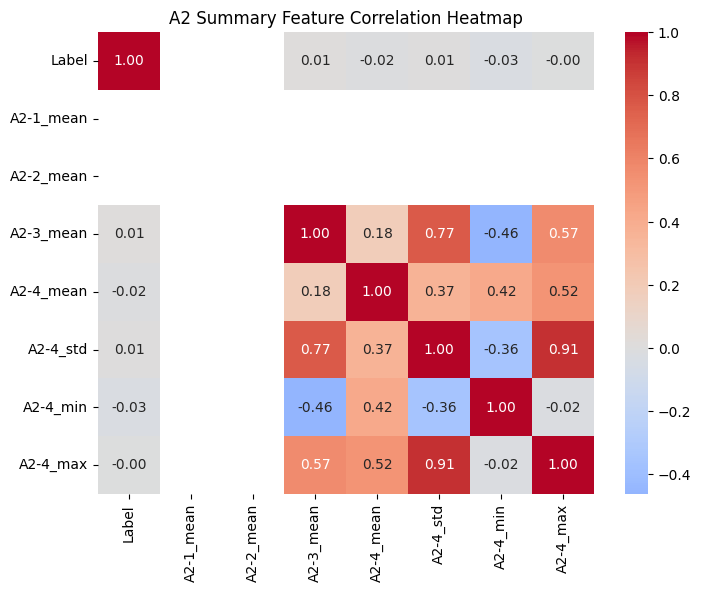

In [ ]:
# 요약 feature 생성
a2_features = extract_a2_features(train_a2)

# 상관계수 계산
corr = a2_features.corr()

# 히트맵 시각화
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A2 Summary Feature Correlation Heatmap")
plt.show()

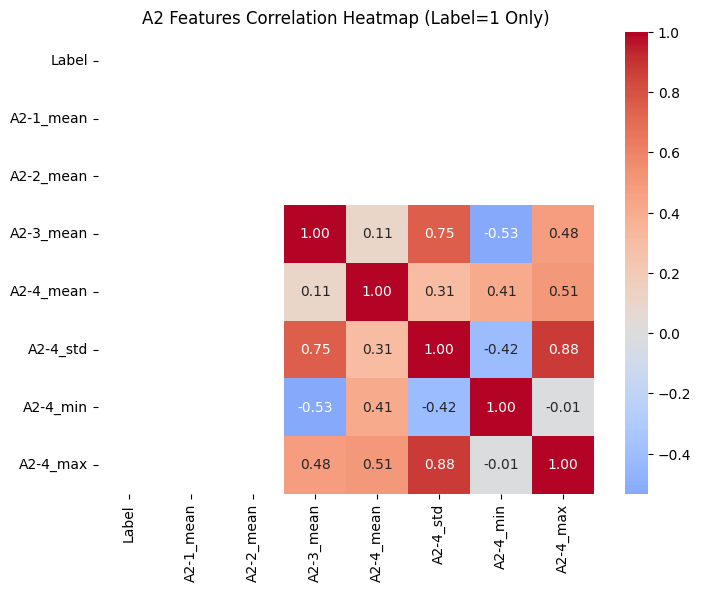

In [ ]:
# Label 1인 데이터만 필터링
a2_features_label1 = extract_a2_features(train_a2[train_a2['Label'] == 1])

# 상관계수 계산
corr_label1 = a2_features_label1.corr()

# 히트맵 시각화
plt.figure(figsize=(8,6))
sns.heatmap(corr_label1, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A2 Features Correlation Heatmap (Label=1 Only)")
plt.show()

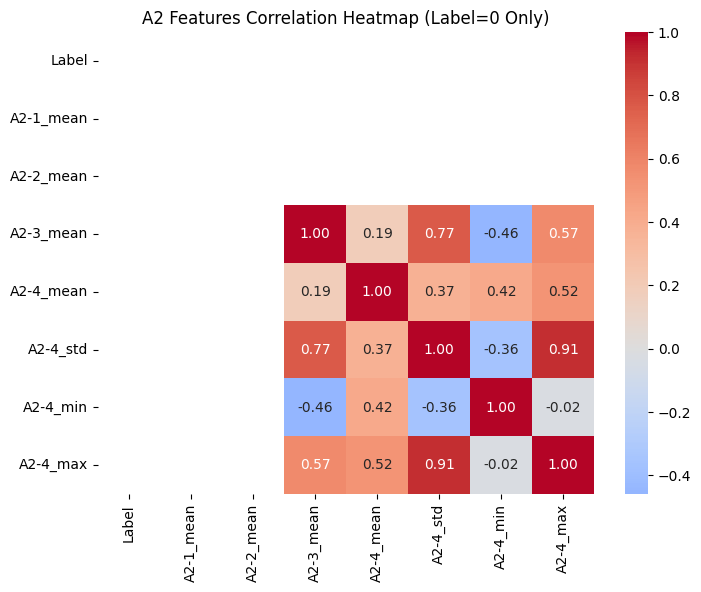

In [ ]:
# Label 1인 데이터만 필터링
a2_features_label1 = extract_a2_features(train_a2[train_a2['Label'] == 0])

# 상관계수 계산
corr_label1 = a2_features_label1.corr()

# 히트맵 시각화
plt.figure(figsize=(8,6))
sns.heatmap(corr_label1, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A2 Features Correlation Heatmap (Label=0 Only)")
plt.show()

## **A3 Test**

In [ ]:
train_a3 = train_a[['Label', 'Age', 'A3-1', 'A3-2', 'A3-3', 'A3-4', 'A3-5', 'A3-6', 'A3-7']]
train_a3.head()

,Label,Age,A3-1,A3-2,A3-3,A3-4,A3-5,A3-6,A3-7
0,0,50a,"1,2,1,1,2,2,1,2,2,2,2,1,1,1,1,2,1,2,1,1,1,1,2,...","4,7,2,6,7,7,8,5,1,5,3,8,8,4,2,5,6,3,6,2,4,2,5,...","1,2,2,1,2,1,1,2,1,1,2,2,2,2,1,1,2,1,1,2,1,1,2,...","4,7,2,6,5,7,8,5,1,5,3,7,2,4,2,5,6,3,6,4,4,3,5,...","1,1,1,1,3,1,1,1,1,1,1,3,3,1,1,1,1,1,1,3,1,3,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","634,700,750,1167,1368,750,701,634,801,650,700,..."
1,0,60b,"1,2,1,1,1,2,1,1,2,1,1,2,2,2,2,1,2,2,2,2,1,1,1,...","4,5,6,2,6,3,6,6,3,8,4,5,7,1,5,8,7,3,1,5,4,8,2,...","2,2,2,1,1,2,2,1,1,1,1,1,1,2,2,2,2,1,1,1,1,2,2,...","6,5,6,2,6,7,7,6,3,8,2,5,5,1,5,8,7,3,1,5,5,8,3,...","3,1,1,1,1,3,3,1,1,1,3,1,3,1,1,1,1,1,1,1,3,1,3,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","934,1117,1251,1101,1451,650,1101,1200,733,1000..."
2,0,50a,"1,2,1,1,2,2,1,2,2,2,2,1,1,1,1,2,1,2,1,1,1,1,2,...","4,7,2,6,7,7,8,5,1,5,3,8,8,4,2,5,6,3,6,2,4,2,5,...","1,2,2,1,2,1,1,2,1,1,2,2,2,2,1,1,2,1,1,2,1,1,2,...","4,7,2,6,5,7,8,5,1,5,3,7,2,4,2,5,6,3,6,4,4,3,5,...","1,1,1,1,3,1,1,1,1,1,1,3,3,1,1,1,1,1,1,3,1,3,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","634,700,750,1167,1368,750,701,634,801,650,700,..."
3,0,50a,"2,2,1,2,1,2,1,2,1,2,1,2,1,1,2,2,1,1,2,2,1,1,2,...","5,1,4,7,8,1,8,3,4,7,2,5,2,6,5,3,6,4,3,1,2,8,1,...","2,2,1,2,2,2,1,2,2,1,2,1,2,2,1,1,2,2,1,1,1,1,1,...","5,1,3,6,8,1,8,3,6,7,5,5,2,6,5,3,3,4,3,1,2,8,4,...","1,1,3,4,1,1,1,1,3,1,3,1,1,1,1,1,3,1,1,1,1,1,3,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","667,736,1350,1836,2019,700,666,635,1218,684,11..."
4,0,40b,"2,1,2,2,1,2,1,1,1,1,2,1,2,1,1,1,2,1,2,2,1,2,1,...","5,2,7,7,8,3,2,8,8,2,1,4,1,6,8,6,5,4,3,1,4,7,6,...","1,1,2,1,2,2,2,1,2,1,2,1,2,1,1,2,1,2,1,1,2,2,1,...","7,2,7,7,8,3,2,2,8,4,1,5,5,6,8,6,5,4,2,1,4,4,6,...","3,1,1,1,1,1,1,3,1,3,1,3,3,1,1,1,1,1,3,1,1,3,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","1417,1000,951,684,1000,1051,550,901,633,1518,6..."


In [ ]:
train_a3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647241 non-null  int64 
 1   Age     647241 non-null  object
 2   A3-1    647240 non-null  object
 3   A3-2    647240 non-null  object
 4   A3-3    647240 non-null  object
 5   A3-4    647240 non-null  object
 6   A3-5    647240 non-null  object
 7   A3-6    647240 non-null  object
 8   A3-7    647240 non-null  object
dtypes: int64(1), object(8)
memory usage: 44.4+ MB


In [ ]:
train_a3 = train_a3.dropna()
train_a3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 647240 entries, 0 to 647240
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647240 non-null  int64 
 1   Age     647240 non-null  object
 2   A3-1    647240 non-null  object
 3   A3-2    647240 non-null  object
 4   A3-3    647240 non-null  object
 5   A3-4    647240 non-null  object
 6   A3-5    647240 non-null  object
 7   A3-6    647240 non-null  object
 8   A3-7    647240 non-null  object
dtypes: int64(1), object(8)
memory usage: 49.4+ MB


In [ ]:
# 32 trials -> list
train_a3['A3-1'] = train_a3['A3-1'].apply(lambda x: list(map(int, x.split(','))))
train_a3['A3-2'] = train_a3['A3-2'].apply(lambda x: list(map(int, x.split(','))))
train_a3['A3-3'] = train_a3['A3-3'].apply(lambda x: list(map(int, x.split(','))))
train_a3['A3-4'] = train_a3['A3-4'].apply(lambda x: list(map(int, x.split(','))))
train_a3['A3-5'] = train_a3['A3-5'].apply(lambda x: list(map(int, x.split(','))))
train_a3['A3-6'] = train_a3['A3-6'].apply(lambda x: list(map(int, x.split(','))))
train_a3['A3-7'] = train_a3['A3-7'].apply(lambda x: list(map(int, x.split(','))))

### A3-1

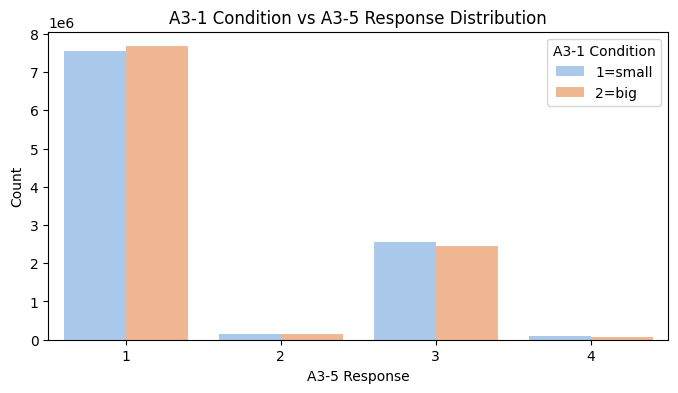

In [ ]:
#A3-1 - A3-5
a31_a35 = []
for _, row in train_a3.iterrows():
    for cond, resp1, resp2 in zip(row['A3-1'], row['A3-5'], row['A3-6']):
        a31_a35.append({'A3-1': cond, 'A3-5': resp1, 'A3-6': resp2, 'Label': row['Label']})
a31_a35 = pd.DataFrame(a31_a35)

# A3-1 별 A3-5 분포
plt.figure(figsize=(8,4))
sns.countplot(data=a31_a35, x='A3-5', hue='A3-1', palette='pastel')
plt.title('A3-1 Condition vs A3-5 Response Distribution')
plt.xlabel('A3-5 Response')
plt.ylabel('Count')
plt.legend(title='A3-1 Condition', labels=['1=small','2=big'])
plt.show()

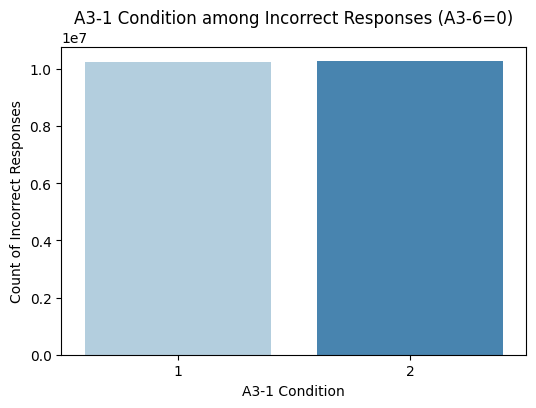

In [ ]:
# A3-6이 0인 응답만
a31_a35_resp0 = a31_a35[a31_a35['A3-6'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a31_a35_resp0, x='A3-1', palette='Blues')
plt.title('A3-1 Condition among Incorrect Responses (A3-6=0)')
plt.xlabel('A3-1 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


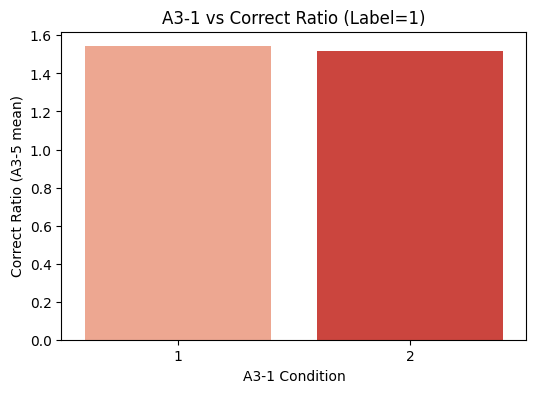

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A3-1와 관계없음 (별로 중요하지 않음)
a31_a35_label1 = a31_a35[a31_a35['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a31_a35_label1, x='A3-1', y='A3-5', estimator=np.mean, ci=None, palette='Reds')
plt.title('A3-1 vs Correct Ratio (Label=1)')
plt.xlabel('A3-1 Condition')
plt.ylabel('Correct Ratio (A3-5 mean)')
plt.show()

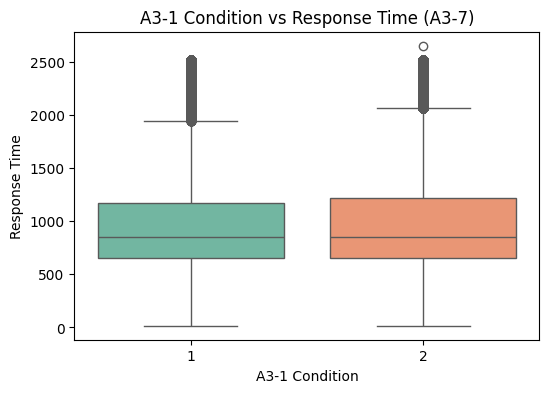

In [ ]:
#A3-1 - A3-7
a31_a37 = train_a3[['A3-1','A3-7']].explode(['A3-1','A3-7'])

plt.figure(figsize=(6,4))
sns.boxplot(data=a31_a37, x='A3-1', y='A3-7', palette='Set2')
plt.title('A3-1 Condition vs Response Time (A3-7)')
plt.xlabel('A3-1 Condition')
plt.ylabel('Response Time')
plt.show()


In [ ]:
a31_a37['A3-7'] = a31_a37['A3-7'].astype(float)
summary_a317 = a31_a37.groupby("A3-1")["A3-7"].describe().T
display(summary_a317)

A3-1,1,2
count,1.035584e+07,1.035584e+07
mean,9.738960e+02,9.729000e+02
std,4.107793e+02,4.188002e+02
min,1.600000e+01,1.600000e+01
25%,6.500000e+02,6.500000e+02
50%,8.500000e+02,8.500000e+02
75%,1.167000e+03,1.217000e+03
max,2.521000e+03,2.652000e+03


### A3-2

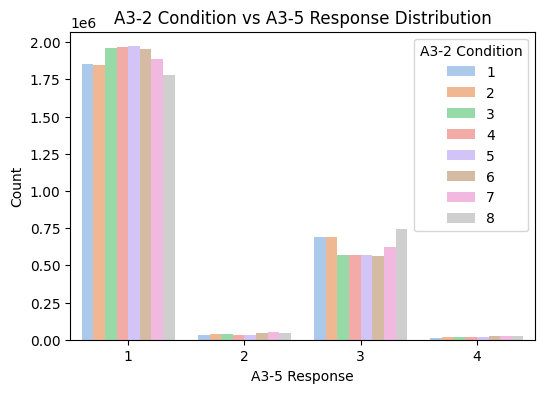

In [ ]:
#A3-2 - A3-5
a3 = train_a3[['A3-2','A3-5','A3-6','Label']].explode(['A3-2','A3-5','A3-6']).copy()

# A3-2 별 A3-5 분포
plt.figure(figsize=(6,4))
sns.countplot(data=a3, x='A3-5', hue='A3-2', palette='pastel')
plt.title('A3-2 Condition vs A3-5 Response Distribution')
plt.xlabel('A3-5 Response')
plt.ylabel('Count')
plt.legend(title='A3-2 Condition')
plt.show()

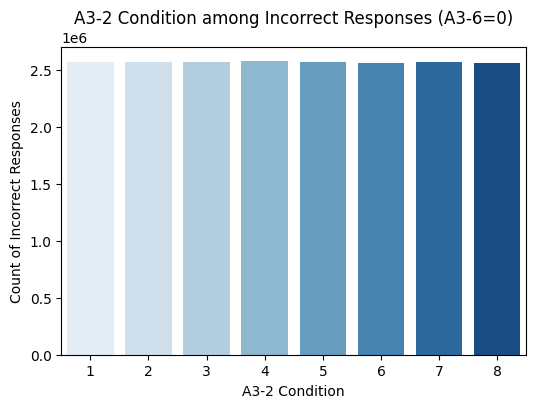

In [ ]:
# A3-6이 0인 응답만
a3_resp0 = a3[a3['A3-6'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a3_resp0, x='A3-2', palette='Blues')
plt.title('A3-2 Condition among Incorrect Responses (A3-6=0)')
plt.xlabel('A3-2 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


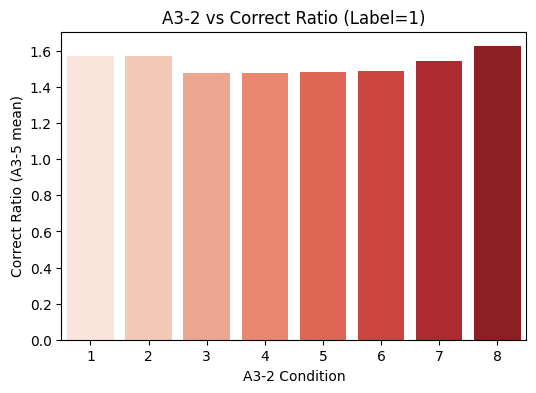

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A3-2와 관계없음 (별로 중요하지 않음)
a3_label1 = a3[a3['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a3_label1, x='A3-2', y='A3-5', estimator=np.mean, ci=None, palette='Reds')
plt.title('A3-2 vs Correct Ratio (Label=1)')
plt.xlabel('A3-2 Condition')
plt.ylabel('Correct Ratio (A3-5 mean)')
plt.show()

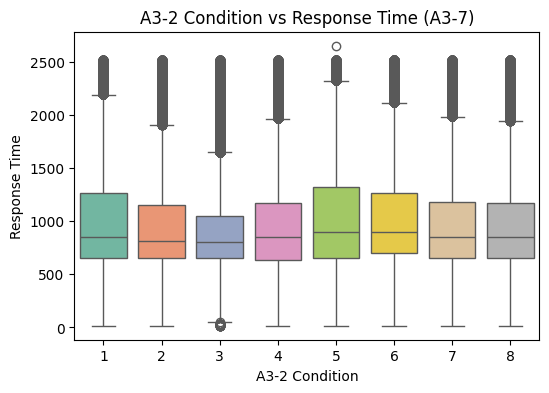

In [ ]:
#A3-2 - A3-7
a3 = train_a3[['A3-2','A3-7']].explode(['A3-2','A3-7'])

plt.figure(figsize=(6,4))
sns.boxplot(data=a3, x='A3-2', y='A3-7', palette='Set2')
plt.title('A3-2 Condition vs Response Time (A3-7)')
plt.xlabel('A3-2 Condition')
plt.ylabel('Response Time')
plt.show()


In [ ]:
a3['A3-7'] = a3['A3-7'].astype(float)
summary_a3 = a3.groupby("A3-2")["A3-7"].describe().T
display(summary_a3)

A3-2,1,2,3,4,5,6,7,8
count,2.588960e+06,2.588960e+06,2.588960e+06,2.588960e+06,2.588960e+06,2.588960e+06,2.588960e+06,2.588960e+06
mean,9.921987e+02,9.501642e+02,9.042055e+02,9.473531e+02,1.022577e+03,1.020161e+03,9.726191e+02,9.779054e+02
std,4.191183e+02,3.968469e+02,3.683695e+02,3.795221e+02,4.504754e+02,4.352778e+02,4.239469e+02,4.249038e+02
min,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01
25%,6.500000e+02,6.500000e+02,6.500000e+02,6.340000e+02,6.500000e+02,7.000000e+02,6.500000e+02,6.500000e+02
50%,8.510000e+02,8.170000e+02,8.010000e+02,8.500000e+02,9.000000e+02,9.000000e+02,8.500000e+02,8.500000e+02
75%,1.267000e+03,1.151000e+03,1.050000e+03,1.167000e+03,1.318000e+03,1.267000e+03,1.184000e+03,1.167000e+03
max,2.520000e+03,2.520000e+03,2.520000e+03,2.521000e+03,2.652000e+03,2.520000e+03,2.520000e+03,2.520000e+03


### A3-3

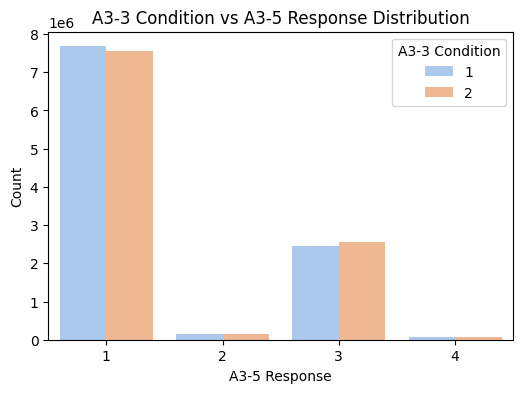

In [ ]:
# A3-3 - A3-5
a3 = train_a3[['A3-3','A3-5','A3-6','Label']].explode(['A3-3','A3-5','A3-6']).copy()

# A3-3 별 A3-5 분포
plt.figure(figsize=(6,4))
sns.countplot(data=a3, x='A3-5', hue='A3-3', palette='pastel')
plt.title('A3-3 Condition vs A3-5 Response Distribution')
plt.xlabel('A3-5 Response')
plt.ylabel('Count')
plt.legend(title='A3-3 Condition')
plt.show()

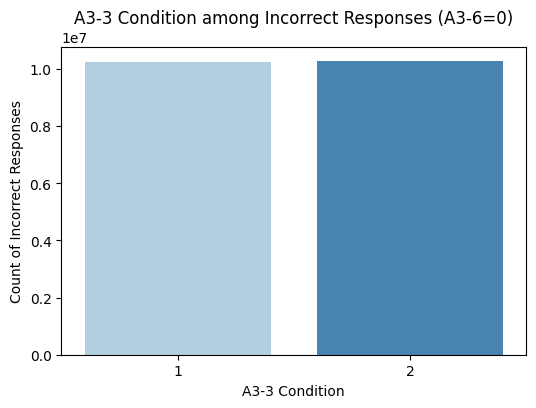

In [ ]:
# A3-6이 0인 응답만
a3_resp0 = a3[a3['A3-6'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a3_resp0, x='A3-3', palette='Blues')
plt.title('A3-3 Condition among Incorrect Responses (A3-6=0)')
plt.xlabel('A3-3 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


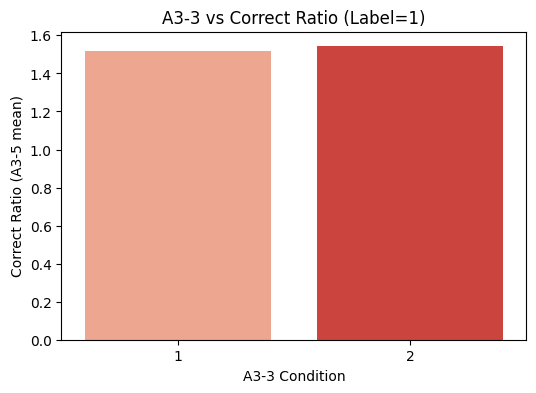

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A3-3와 관계없음 (별로 중요하지 않음)
a3_label1 = a3[a3['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a3_label1, x='A3-3', y='A3-5', estimator=np.mean, ci=None, palette='Reds')
plt.title('A3-3 vs Correct Ratio (Label=1)')
plt.xlabel('A3-3 Condition')
plt.ylabel('Correct Ratio (A3-5 mean)')
plt.show()

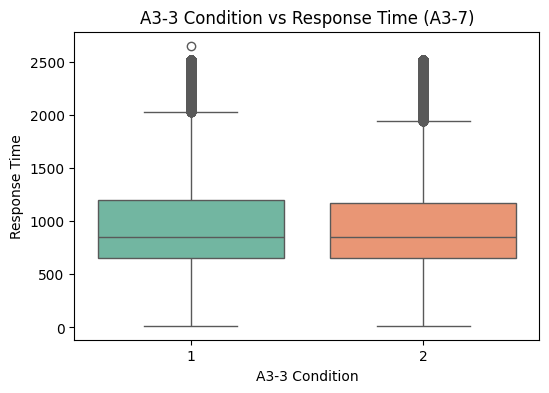

In [ ]:
# A3-3 - A3-7
a3 = train_a3[['A3-3','A3-7']].explode(['A3-3','A3-7'])

plt.figure(figsize=(6,4))
sns.boxplot(data=a3, x='A3-3', y='A3-7', palette='Set2')
plt.title('A3-3 Condition vs Response Time (A3-7)')
plt.xlabel('A3-3 Condition')
plt.ylabel('Response Time')
plt.show()


In [ ]:
a3['A3-7'] = a3['A3-7'].astype(float)
summary_a3 = a3.groupby("A3-3")["A3-7"].describe().T
display(summary_a3)

A3-3,1,2
count,1.035584e+07,1.035584e+07
mean,9.781470e+02,9.686490e+02
std,4.217141e+02,4.077325e+02
min,1.600000e+01,1.600000e+01
25%,6.500000e+02,6.500000e+02
50%,8.500000e+02,8.500000e+02
75%,1.201000e+03,1.167000e+03
max,2.652000e+03,2.520000e+03


### A3-4

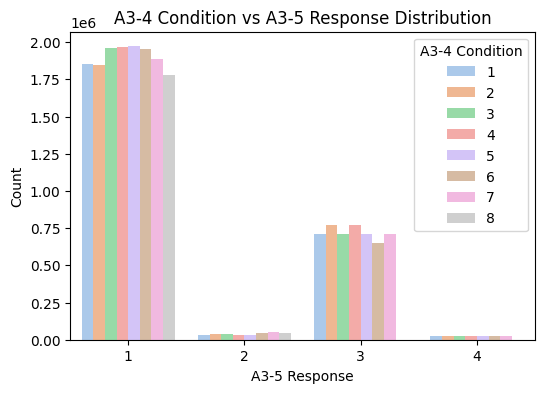

In [ ]:
# A3-4 - A3-5
a3 = train_a3[['A3-4','A3-5','A3-6','Label']].explode(['A3-4','A3-5','A3-6']).copy()

# A3-4 별 A3-5 분포
plt.figure(figsize=(6,4))
sns.countplot(data=a3, x='A3-5', hue='A3-4', palette='pastel')
plt.title('A3-4 Condition vs A3-5 Response Distribution')
plt.xlabel('A3-5 Response')
plt.ylabel('Count')
plt.legend(title='A3-4 Condition')
plt.show()

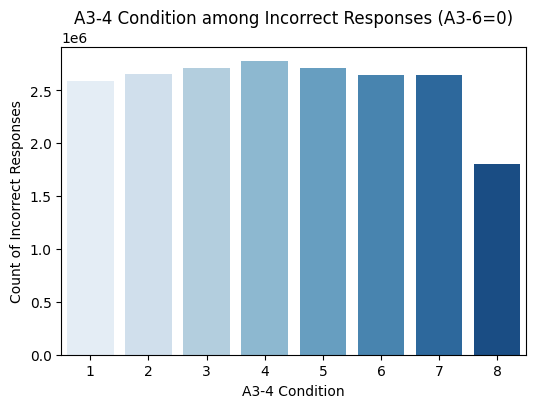

In [ ]:
# A3-6이 0인 응답만
a3_resp0 = a3[a3['A3-6'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a3_resp0, x='A3-4', palette='Blues')
plt.title('A3-4 Condition among Incorrect Responses (A3-6=0)')
plt.xlabel('A3-4 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


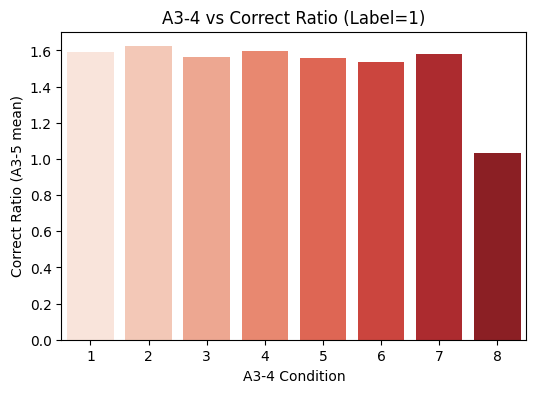

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A3-4와 관계없음 (별로 중요하지 않음)
a3_label1 = a3[a3['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a3_label1, x='A3-4', y='A3-5', estimator=np.mean, ci=None, palette='Reds')
plt.title('A3-4 vs Correct Ratio (Label=1)')
plt.xlabel('A3-4 Condition')
plt.ylabel('Correct Ratio (A3-5 mean)')
plt.show()

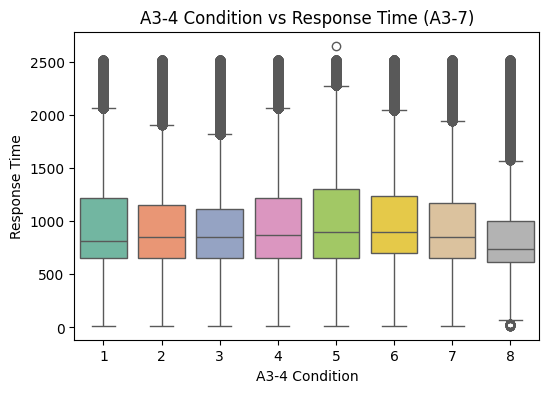

In [ ]:
# A3-4 - A3-7
a3 = train_a3[['A3-4','A3-7']].explode(['A3-4','A3-7'])

plt.figure(figsize=(6,4))
sns.boxplot(data=a3, x='A3-4', y='A3-7', palette='Set2')
plt.title('A3-4 Condition vs Response Time (A3-7)')
plt.xlabel('A3-4 Condition')
plt.ylabel('Response Time')
plt.show()


In [ ]:
a3['A3-7'] = a3['A3-7'].astype(float)
summary_a3 = a3.groupby("A3-4")["A3-7"].describe().T
display(summary_a3)

A3-4,1,2,3,4,5,6,7,8
count,2.611263e+06,2.674028e+06,2.733586e+06,2.793451e+06,2.733641e+06,2.673512e+06,2.670987e+06,1.821212e+06
mean,9.789039e+02,9.672290e+02,9.457133e+02,9.808799e+02,1.007445e+03,1.010168e+03,9.819857e+02,8.869624e+02
std,4.210130e+02,4.064625e+02,3.945842e+02,3.962628e+02,4.312008e+02,4.231143e+02,4.231595e+02,4.103784e+02
min,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01,1.600000e+01
25%,6.500000e+02,6.500000e+02,6.500000e+02,6.500000e+02,6.500000e+02,7.000000e+02,6.500000e+02,6.170000e+02
50%,8.170000e+02,8.500000e+02,8.500000e+02,8.670000e+02,9.000000e+02,9.000000e+02,8.500000e+02,7.340000e+02
75%,1.217000e+03,1.151000e+03,1.117000e+03,1.217000e+03,1.301000e+03,1.239000e+03,1.167000e+03,1.000000e+03
max,2.520000e+03,2.520000e+03,2.520000e+03,2.522000e+03,2.652000e+03,2.520000e+03,2.520000e+03,2.520000e+03


### A3-6

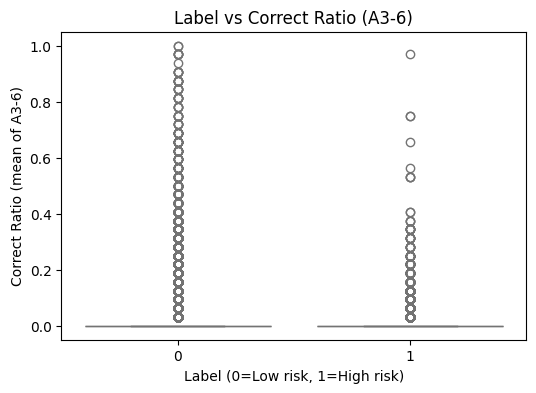

In [ ]:
# 참가자 단위로 평균 정답률 계산
train_a3['A3-6_ratio'] = train_a3['A3-6'].apply(lambda x: np.mean(x))

plt.figure(figsize=(6,4))
sns.boxplot(data=train_a3, x='Label', y='A3-6_ratio', palette='pastel')
plt.title('Label vs Correct Ratio (A3-6)')
plt.xlabel('Label (0=Low risk, 1=High risk)')
plt.ylabel('Correct Ratio (mean of A3-6)')
plt.show()

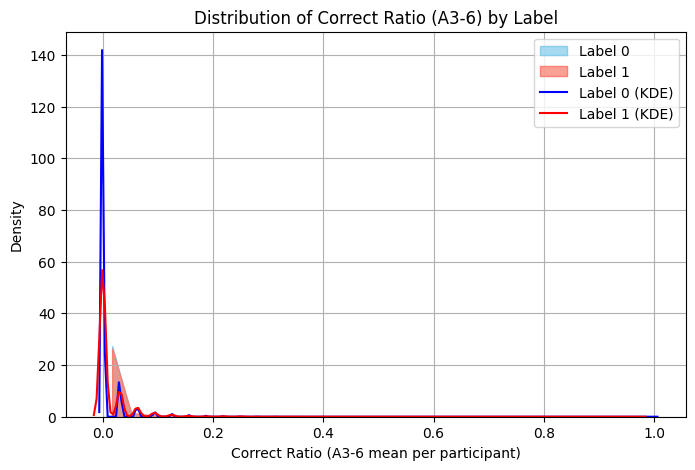

In [ ]:
# KDE Plot
# 이렇게 보면 Label 0, 1 둘다 정답률 0에 많이 모여있음
# 다른 검사의 정답률과 함께 봐야할듯
bins = np.linspace(0, 1, 30)

plt.figure(figsize=(8,5))
sns.histplot(train_a3[train_a3['Label'] == 0]['A3-6_ratio'],
             bins=bins, kde=False, stat='density', color='skyblue', label='Label 0', element='poly')
sns.histplot(train_a3[train_a3['Label'] == 1]['A3-6_ratio'],
             bins=bins, kde=False, stat='density', color='salmon', label='Label 1', element='poly')

sns.kdeplot(train_a3[train_a3['Label'] == 0]['A3-6_ratio'], color='blue', label='Label 0 (KDE)')
sns.kdeplot(train_a3[train_a3['Label'] == 1]['A3-6_ratio'], color='red', label='Label 1 (KDE)')

plt.title('Distribution of Correct Ratio (A3-6) by Label')
plt.xlabel('Correct Ratio (A3-6 mean per participant)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

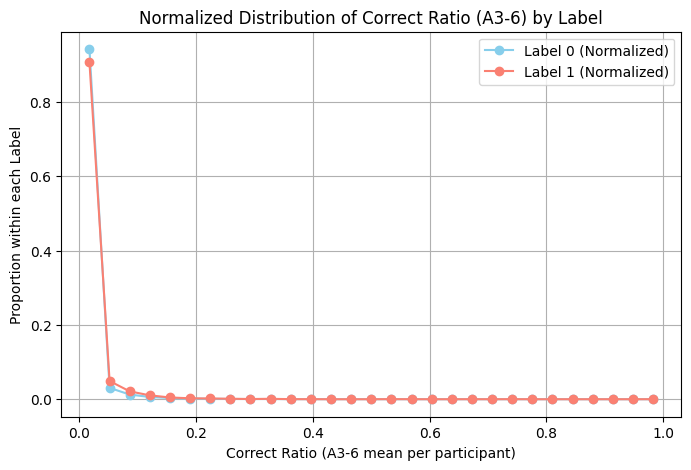

In [ ]:
# Normalized
counts_0, _ = np.histogram(train_a3[train_a3['Label'] == 0]['A3-6_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a3[train_a3['Label'] == 1]['A3-6_ratio'], bins=bins)

counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', label='Label 0 (Normalized)', color='skyblue')
plt.plot(bin_centers, counts_1, marker='o', label='Label 1 (Normalized)', color='salmon')
plt.title('Normalized Distribution of Correct Ratio (A3-6) by Label')
plt.xlabel('Correct Ratio (A3-6 mean per participant)')
plt.ylabel('Proportion within each Label')
plt.legend()
plt.grid(True)
plt.show()

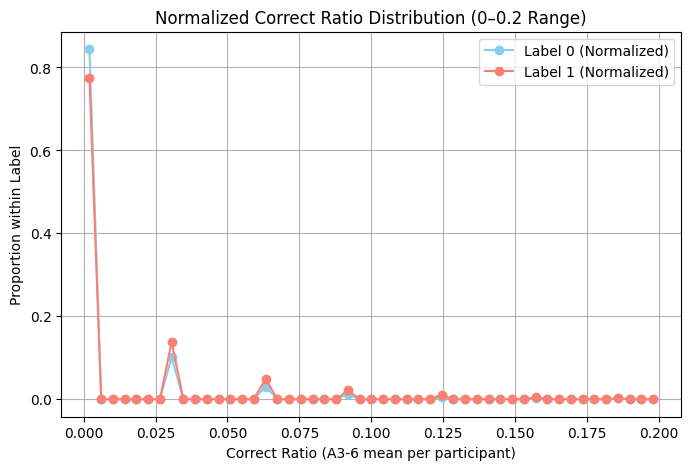

In [ ]:
bins = np.linspace(0, 0.2, 50)
counts_0, _ = np.histogram(train_a3[train_a3['Label'] == 0]['A3-6_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a3[train_a3['Label'] == 1]['A3-6_ratio'], bins=bins)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', color='skyblue', label='Label 0 (Normalized)')
plt.plot(bin_centers, counts_1, marker='o', color='salmon', label='Label 1 (Normalized)')
plt.title('Normalized Correct Ratio Distribution (0–0.2 Range)')
plt.xlabel('Correct Ratio (A3-6 mean per participant)')
plt.ylabel('Proportion within Label')
plt.legend()
plt.grid(True)
plt.show()

### Correlation

In [ ]:
def extract_a3_features(df):
    df = df.copy()

    # A3-5 → 최빈값
    def safe_mode(x):
        try:
            return mode(x)
        except StatisticsError:
            return np.nan

    df['A3-5_mode'] = df['A3-5'].apply(lambda x: safe_mode(x) if isinstance(x, list) and len(x) > 0 else np.nan)

    # A3-6 → 1의 개수
    df['A3-6_count_1'] = df['A3-6'].apply(lambda x: x.count(1) if isinstance(x, list) else np.nan)

    # A3-7 → 통계량
    df['A3-7_mean'] = df['A3-7'].apply(lambda x: np.mean(x) if isinstance(x, list) and len(x) > 0 else np.nan)
    df['A3-7_std']  = df['A3-7'].apply(lambda x: np.std(x) if isinstance(x, list) and len(x) > 0 else np.nan)
    df['A3-7_min']  = df['A3-7'].apply(lambda x: np.min(x) if isinstance(x, list) and len(x) > 0 else np.nan)
    df['A3-7_max']  = df['A3-7'].apply(lambda x: np.max(x) if isinstance(x, list) and len(x) > 0 else np.nan)

    return df[['Label', 'A3-5_mode', 'A3-6_count_1', 'A3-7_mean', 'A3-7_std', 'A3-7_min', 'A3-7_max']]


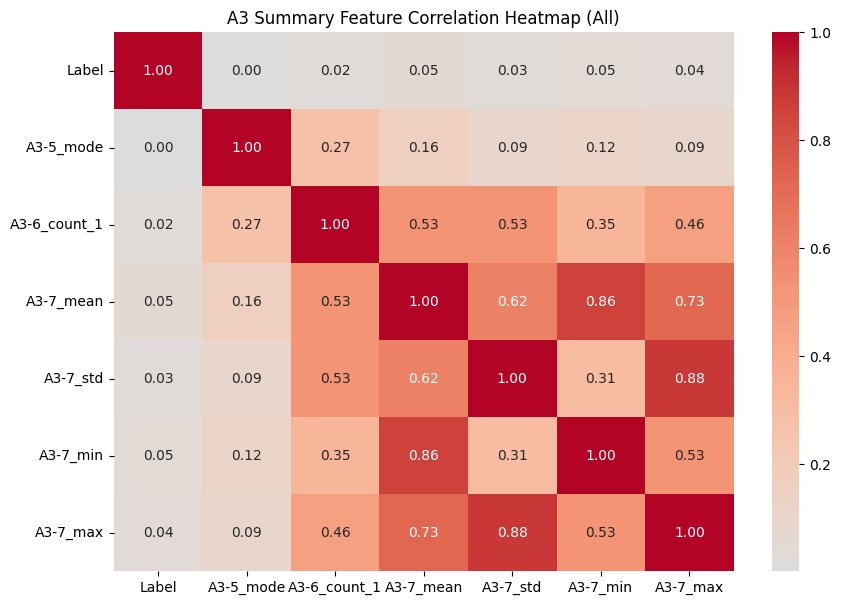

In [ ]:
a3_features = extract_a3_features(train_a3)
corr = a3_features.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A3 Summary Feature Correlation Heatmap (All)")
plt.show()

## **A4 Test**

In [ ]:
train_a4 = train_a[['Label', 'Age', 'A4-1', 'A4-2', 'A4-3', 'A4-4', 'A4-5']]
train_a4.head()

,Label,Age,A4-1,A4-2,A4-3,A4-4,A4-5
0,0,50a,"2,2,1,1,2,2,1,1,2,1,1,1,1,1,1,2,2,2,1,2,2,2,1,...","2,1,1,1,1,2,1,2,1,2,1,2,2,1,1,1,1,2,2,2,1,1,1,...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","600,685,583,603,633,500,698,650,585,598,553,68..."
1,0,60b,"2,2,1,2,1,1,2,1,1,2,2,2,2,1,2,2,1,2,1,1,1,2,2,...","1,1,1,1,2,1,1,2,2,1,2,1,1,2,2,2,2,2,1,1,1,2,2,...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","1084,534,651,583,650,583,584,600,533,584,650,4..."
2,0,50a,"2,2,1,1,2,2,1,1,2,1,1,1,1,1,1,2,2,2,1,2,2,2,1,...","2,1,1,1,1,2,1,2,1,2,1,2,2,1,1,1,1,2,2,2,1,1,1,...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","600,685,583,603,633,500,698,650,585,598,553,68..."
3,0,50a,"2,2,2,1,1,1,2,2,2,1,1,2,2,1,1,1,2,2,1,2,2,2,1,...","1,2,2,1,2,1,1,1,1,1,1,1,1,1,2,1,1,2,1,2,1,2,2,...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","650,650,600,916,534,500,767,550,600,450,667,60..."
4,0,40b,"2,2,2,2,1,1,1,2,1,1,2,1,2,2,1,1,2,1,2,2,1,2,2,...","1,2,2,1,2,2,1,2,2,2,1,2,1,2,2,1,1,2,2,1,2,1,2,...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","667,700,633,550,684,500,433,700,633,483,650,53..."


In [ ]:
train_a4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647241 non-null  int64 
 1   Age     647241 non-null  object
 2   A4-1    647241 non-null  object
 3   A4-2    647241 non-null  object
 4   A4-3    647241 non-null  object
 5   A4-4    647241 non-null  object
 6   A4-5    647241 non-null  object
dtypes: int64(1), object(6)
memory usage: 34.6+ MB


In [ ]:
# 80 trials -> list
train_a4['A4-1'] = train_a4['A4-1'].apply(lambda x: list(map(int, x.split(','))))
train_a4['A4-2'] = train_a4['A4-2'].apply(lambda x: list(map(int, x.split(','))))
train_a4['A4-3'] = train_a4['A4-3'].apply(lambda x: list(map(int, x.split(','))))
train_a4['A4-4'] = train_a4['A4-4'].apply(lambda x: list(map(int, x.split(','))))
train_a4['A4-5'] = train_a4['A4-5'].apply(lambda x: list(map(int, x.split(','))))

In [ ]:
a4 = train_a4[['A4-1', 'A4-2', 'A4-3','A4-4','A4-5','Label']].explode(['A4-1', 'A4-2', 'A4-3','A4-4','A4-5']).copy()


### A4-1

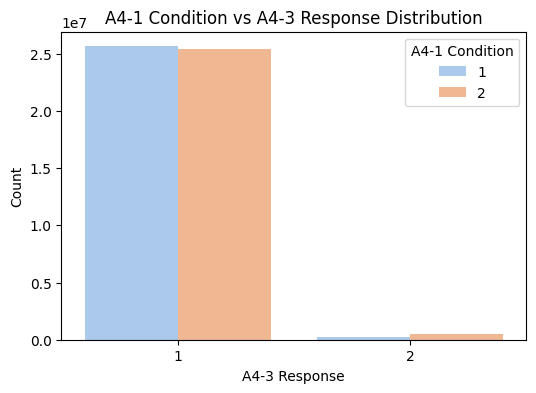

In [ ]:
# A4-1 별 A4-3 분포
plt.figure(figsize=(6,4))
sns.countplot(data=a4, x='A4-3', hue='A4-1', palette='pastel')
plt.title('A4-1 Condition vs A4-3 Response Distribution')
plt.xlabel('A4-3 Response')
plt.ylabel('Count')
plt.legend(title='A4-1 Condition')
plt.show()

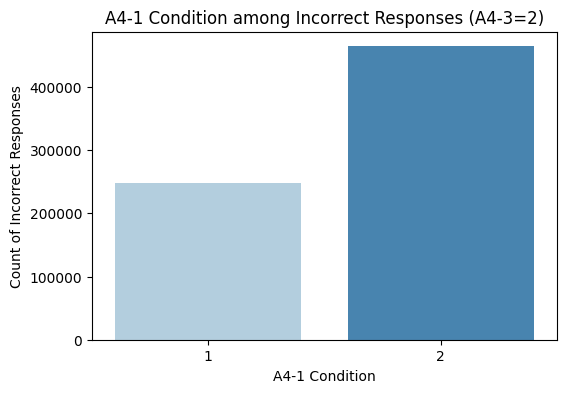

In [ ]:
# A4-3이 2인 응답만
a4_resp1 = a4[a4['A4-3'] == 2]

plt.figure(figsize=(6,4))
sns.countplot(data=a4_resp1, x='A4-1', palette='Blues')
plt.title('A4-1 Condition among Incorrect Responses (A4-3=2)')
plt.xlabel('A4-1 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


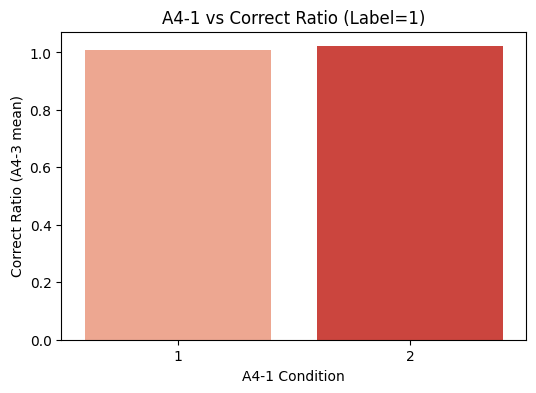

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A4-1와 관계없음 (별로 중요하지 않음)
a4_label1 = a4[a4['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a4_label1, x='A4-1', y='A4-3', estimator=np.mean, ci=None, palette='Reds')
plt.title('A4-1 vs Correct Ratio (Label=1)')
plt.xlabel('A4-1 Condition')
plt.ylabel('Correct Ratio (A4-3 mean)')
plt.show()

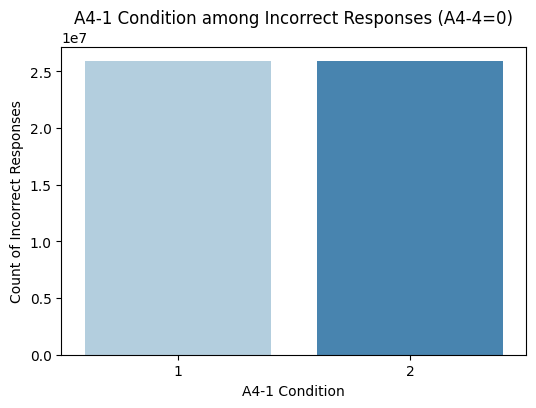

In [ ]:
# A4-4이 0인 응답만
a4_resp2 = a4[a4['A4-4'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a4_resp2, x='A4-1', palette='Blues')
plt.title('A4-1 Condition among Incorrect Responses (A4-4=0)')
plt.xlabel('A4-1 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


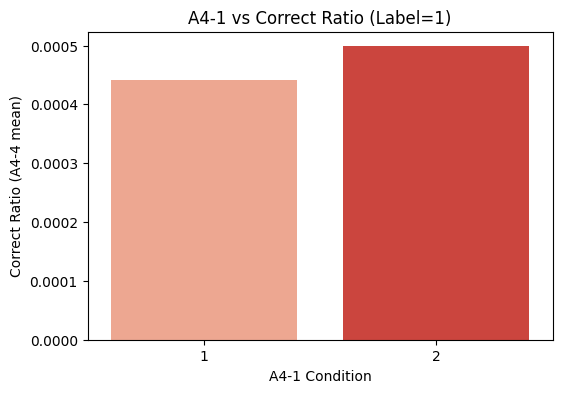

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A4-1와 관계없음 (별로 중요하지 않음)
a4_label1 = a4[a4['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a4_label1, x='A4-1', y='A4-4', estimator=np.mean, ci=None, palette='Reds')
plt.title('A4-1 vs Correct Ratio (Label=1)')
plt.xlabel('A4-1 Condition')
plt.ylabel('Correct Ratio (A4-4 mean)')
plt.show()

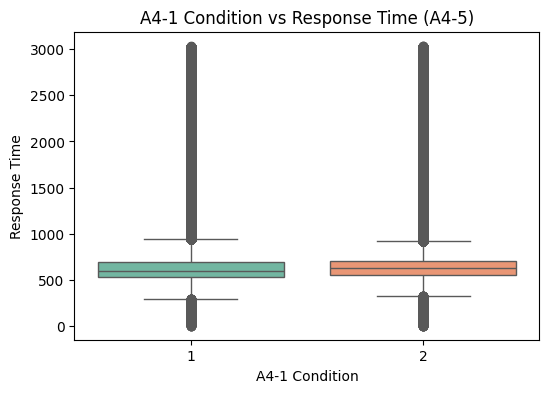

In [ ]:
#A4-1 - A4-5
plt.figure(figsize=(6,4))
sns.boxplot(data=a4, x='A4-1', y='A4-5', palette='Set2')
plt.title('A4-1 Condition vs Response Time (A4-5)')
plt.xlabel('A4-1 Condition')
plt.ylabel('Response Time')
plt.show()

In [ ]:
a4['A4-5'] = a4['A4-5'].astype(float)
summary_a4 = a4.groupby("A4-1")["A4-5"].describe().T
display(summary_a4)

A4-1,1,2
count,2.588964e+07,2.588964e+07
mean,6.255254e+02,6.440350e+02
std,1.427554e+02,1.369896e+02
min,2.000000e+00,2.000000e+00
25%,5.350000e+02,5.500000e+02
50%,6.000000e+02,6.330000e+02
75%,6.980000e+02,7.000000e+02
max,3.030000e+03,3.038000e+03


### A4-2

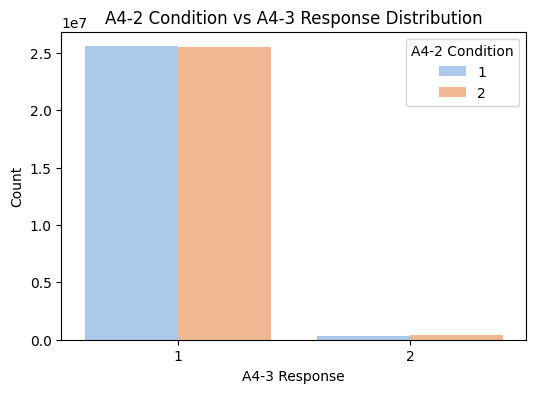

In [ ]:
# A4-2 별 A4-3 분포
plt.figure(figsize=(6,4))
sns.countplot(data=a4, x='A4-3', hue='A4-2', palette='pastel')
plt.title('A4-2 Condition vs A4-3 Response Distribution')
plt.xlabel('A4-3 Response')
plt.ylabel('Count')
plt.legend(title='A4-2 Condition')
plt.show()

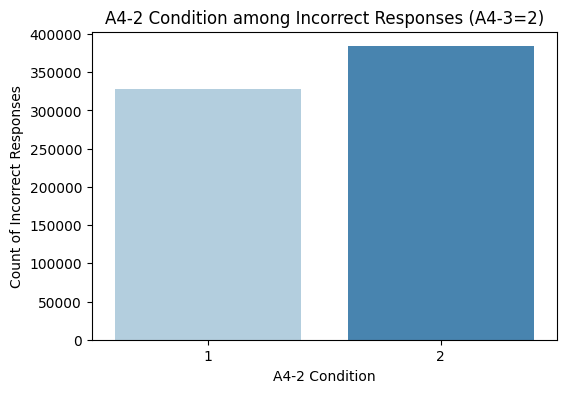

In [ ]:
# A4-3이 2인 응답만
a4_resp1 = a4[a4['A4-3'] == 2]

plt.figure(figsize=(6,4))
sns.countplot(data=a4_resp1, x='A4-2', palette='Blues')
plt.title('A4-2 Condition among Incorrect Responses (A4-3=2)')
plt.xlabel('A4-2 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


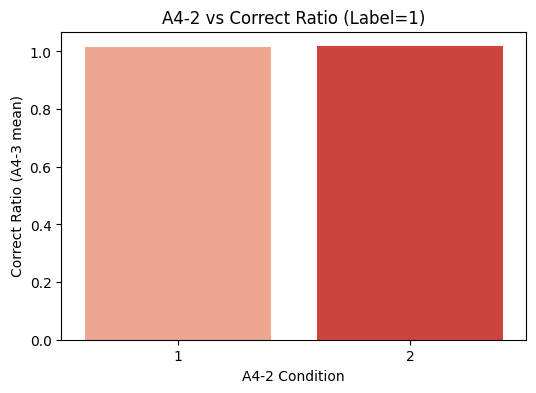

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A4-2와 관계없음 (별로 중요하지 않음)
a4_label1 = a4[a4['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a4_label1, x='A4-2', y='A4-3', estimator=np.mean, ci=None, palette='Reds')
plt.title('A4-2 vs Correct Ratio (Label=1)')
plt.xlabel('A4-2 Condition')
plt.ylabel('Correct Ratio (A4-3 mean)')
plt.show()

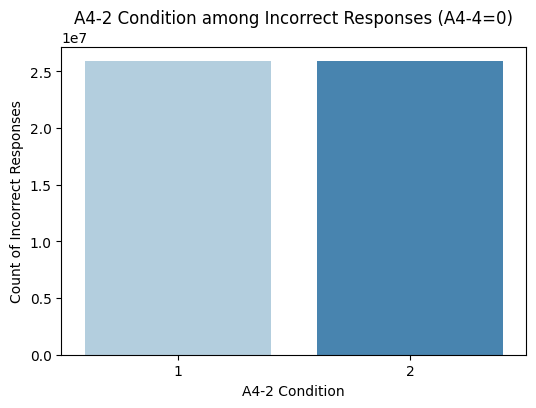

In [ ]:
# A4-4이 0인 응답만
a4_resp2 = a4[a4['A4-4'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a4_resp2, x='A4-2', palette='Blues')
plt.title('A4-2 Condition among Incorrect Responses (A4-4=0)')
plt.xlabel('A4-2 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()


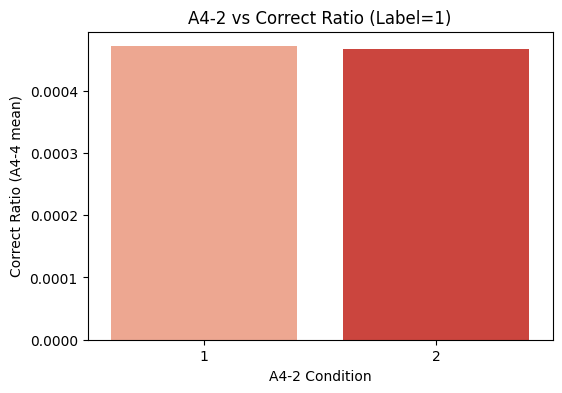

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A4-2와 관계없음 (별로 중요하지 않음)
a4_label1 = a4[a4['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a4_label1, x='A4-2', y='A4-4', estimator=np.mean, ci=None, palette='Reds')
plt.title('A4-2 vs Correct Ratio (Label=1)')
plt.xlabel('A4-2 Condition')
plt.ylabel('Correct Ratio (A4-4 mean)')
plt.show()

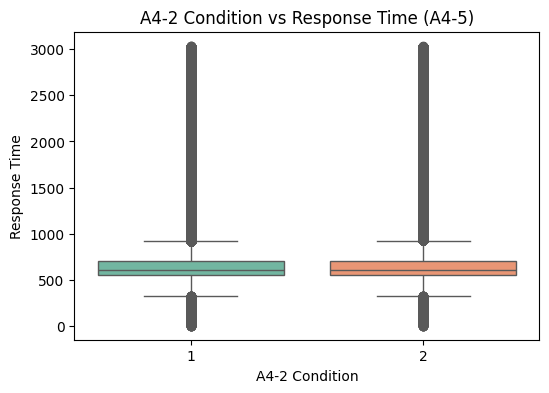

In [ ]:
# A4-2 - A4-5
plt.figure(figsize=(6,4))
sns.boxplot(data=a4, x='A4-2', y='A4-5', palette='Set2')
plt.title('A4-2 Condition vs Response Time (A4-5)')
plt.xlabel('A4-2 Condition')
plt.ylabel('Response Time')
plt.show()

In [ ]:
a4['A4-5'] = a4['A4-5'].astype(float)
summary_a4 = a4.groupby("A4-2")["A4-5"].describe().T
display(summary_a4)

A4-2,1,2
count,2.588964e+07,2.588964e+07
mean,6.375361e+02,6.320243e+02
std,1.397993e+02,1.405615e+02
min,2.000000e+00,2.000000e+00
25%,5.500000e+02,5.490000e+02
50%,6.020000e+02,6.010000e+02
75%,7.000000e+02,7.000000e+02
max,3.038000e+03,3.032000e+03


### A4-3

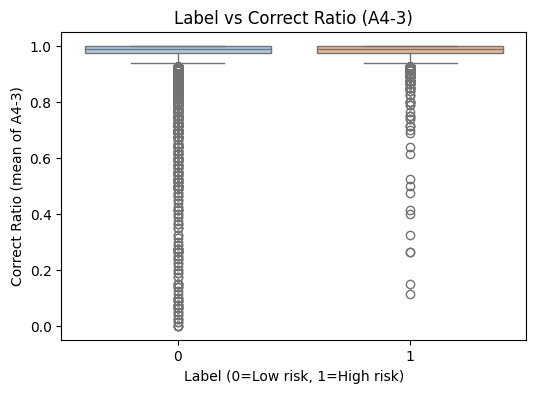

In [ ]:
# 참가자 단위로 평균 정답률 계산
train_a4['A4-3_ratio'] = train_a4['A4-3'].apply(lambda x: x.count(1)/len(x))

plt.figure(figsize=(6,4))
sns.boxplot(data=train_a4, x='Label', y='A4-3_ratio', palette='pastel')
plt.title('Label vs Correct Ratio (A4-3)')
plt.xlabel('Label (0=Low risk, 1=High risk)')
plt.ylabel('Correct Ratio (mean of A4-3)')
plt.show()

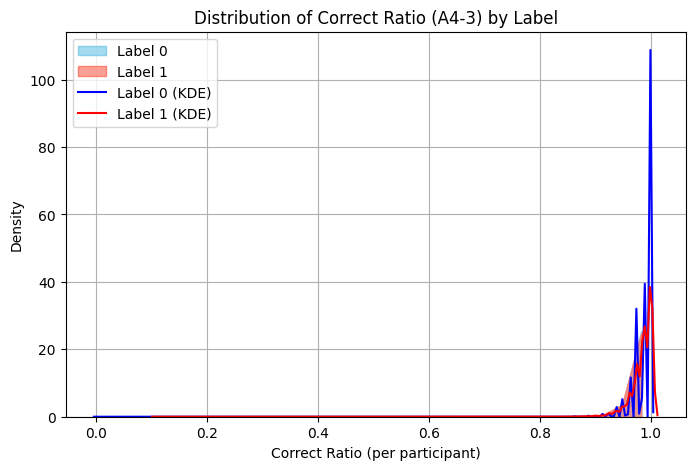

In [ ]:
# KDE Plot
bins = np.linspace(0, 1, 30)

plt.figure(figsize=(8,5))
sns.histplot(train_a4[train_a4['Label'] == 0]['A4-3_ratio'], bins=bins, kde=False, stat='density', color='skyblue', label='Label 0', element='poly')
sns.histplot(train_a4[train_a4['Label'] == 1]['A4-3_ratio'], bins=bins, kde=False, stat='density', color='salmon', label='Label 1', element='poly')

sns.kdeplot(train_a4[train_a4['Label'] == 0]['A4-3_ratio'], color='blue', label='Label 0 (KDE)')
sns.kdeplot(train_a4[train_a4['Label'] == 1]['A4-3_ratio'], color='red', label='Label 1 (KDE)')

plt.title('Distribution of Correct Ratio (A4-3) by Label')
plt.xlabel('Correct Ratio (per participant)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

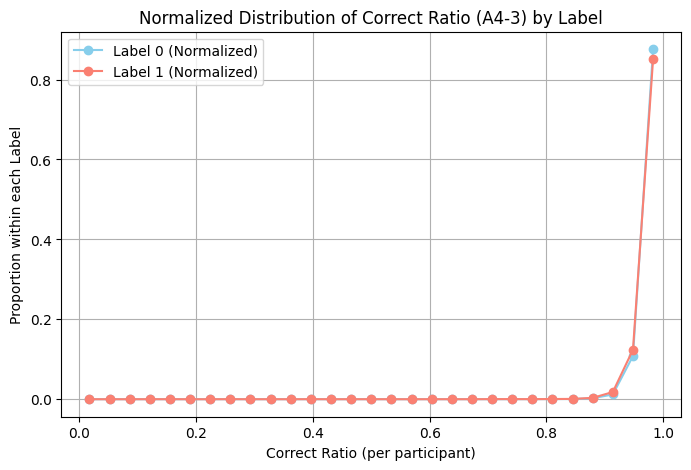

In [ ]:
# Normalized
counts_0, _ = np.histogram(train_a4[train_a4['Label']==0]['A4-3_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a4[train_a4['Label']==1]['A4-3_ratio'], bins=bins)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()
bin_centers = (bins[:-1]+bins[1:])/2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', color='skyblue', label='Label 0 (Normalized)')
plt.plot(bin_centers, counts_1, marker='o', color='salmon', label='Label 1 (Normalized)')
plt.title('Normalized Distribution of Correct Ratio (A4-3) by Label')
plt.xlabel('Correct Ratio (per participant)')
plt.ylabel('Proportion within each Label')
plt.legend()
plt.grid(True)
plt.show()

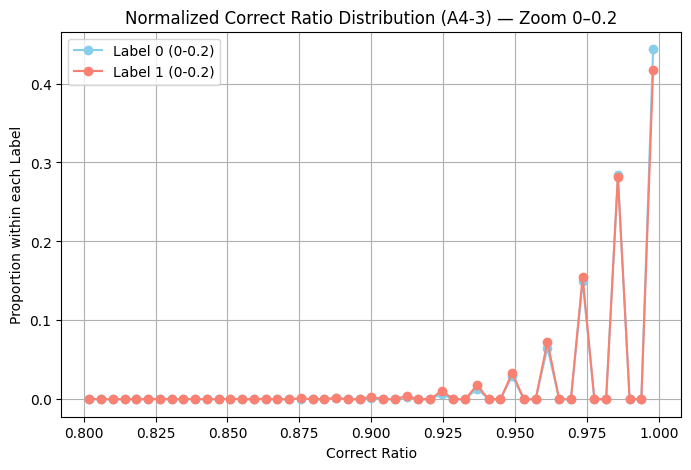

In [ ]:
bins_low = np.linspace(0.8, 1., 50)
c0_low, _ = np.histogram(train_a4[train_a4['Label'] == 0]['A4-3_ratio'].dropna(), bins=bins_low)
c1_low, _ = np.histogram(train_a4[train_a4['Label'] == 1]['A4-3_ratio'].dropna(), bins=bins_low)
c0_low = c0_low / c0_low.sum() if c0_low.sum()>0 else c0_low
c1_low = c1_low / c1_low.sum() if c1_low.sum()>0 else c1_low
centers_low = (bins_low[:-1] + bins_low[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(centers_low, c0_low, marker='o', color='skyblue', label='Label 0 (0-0.2)')
plt.plot(centers_low, c1_low, marker='o', color='salmon', label='Label 1 (0-0.2)')
plt.title('Normalized Correct Ratio Distribution (A4-3) — Zoom 0–0.2')
plt.xlabel('Correct Ratio')
plt.ylabel('Proportion within each Label')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def extract_a4_features(df):
    df = df.copy()

    df['A4-3_correct_count'] = df['A4-3'].apply(lambda x: x.count(1) if isinstance(x, list) else np.nan)
    df['A4-3_incorrect_count'] = df['A4-3'].apply(lambda x: x.count(2) if isinstance(x, list) else np.nan)
    df['A4-3_total'] = df['A4-3'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['A4-3_ratio'] = df.apply(lambda r: (r['A4-3_correct_count']/r['A4-3_total']) if r['A4-3_total']>0 else np.nan, axis=1)

    return df[['Label','A4-3_correct_count','A4-3_incorrect_count','A4-3_total','A4-3_ratio']]

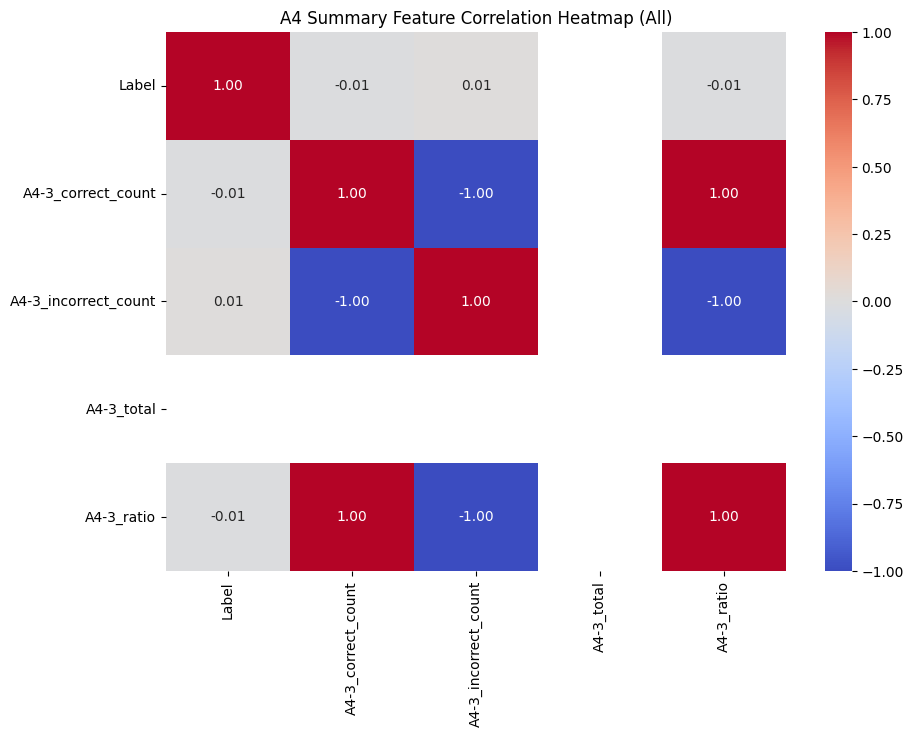

In [ ]:
a4_features = extract_a4_features(train_a4)
corr = a4_features.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A4 Summary Feature Correlation Heatmap (All)")
plt.show()

### A4-4

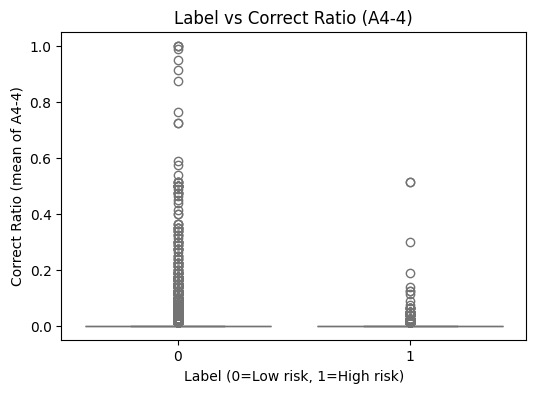

In [ ]:
# 참가자 단위로 평균 정답률 계산
train_a4['A4-4_ratio'] = train_a4['A4-4'].apply(lambda x: np.mean(x))

plt.figure(figsize=(6,4))
sns.boxplot(data=train_a4, x='Label', y='A4-4_ratio', palette='pastel')
plt.title('Label vs Correct Ratio (A4-4)')
plt.xlabel('Label (0=Low risk, 1=High risk)')
plt.ylabel('Correct Ratio (mean of A4-4)')
plt.show()

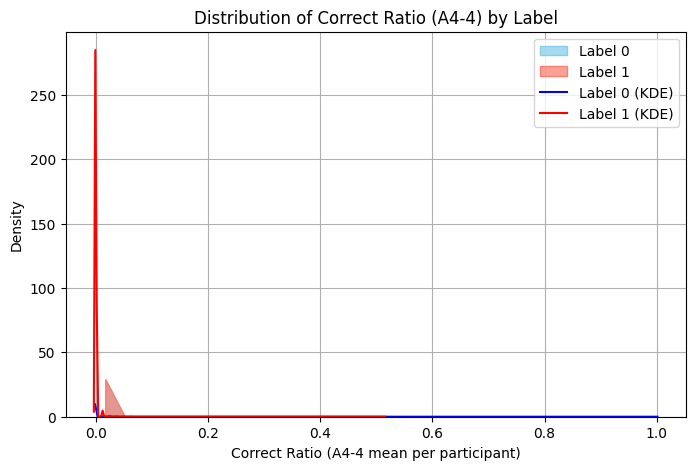

In [ ]:
# KDE Plot
# 이렇게 보면 Label 0, 1 둘다 정답률 0에 많이 모여있음
# 다른 검사의 정답률과 함께 봐야할듯
bins = np.linspace(0, 1, 30)

plt.figure(figsize=(8,5))
sns.histplot(train_a4[train_a4['Label'] == 0]['A4-4_ratio'],
             bins=bins, kde=False, stat='density', color='skyblue', label='Label 0', element='poly')
sns.histplot(train_a4[train_a4['Label'] == 1]['A4-4_ratio'],
             bins=bins, kde=False, stat='density', color='salmon', label='Label 1', element='poly')

sns.kdeplot(train_a4[train_a4['Label'] == 0]['A4-4_ratio'], color='blue', label='Label 0 (KDE)')
sns.kdeplot(train_a4[train_a4['Label'] == 1]['A4-4_ratio'], color='red', label='Label 1 (KDE)')

plt.title('Distribution of Correct Ratio (A4-4) by Label')
plt.xlabel('Correct Ratio (A4-4 mean per participant)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

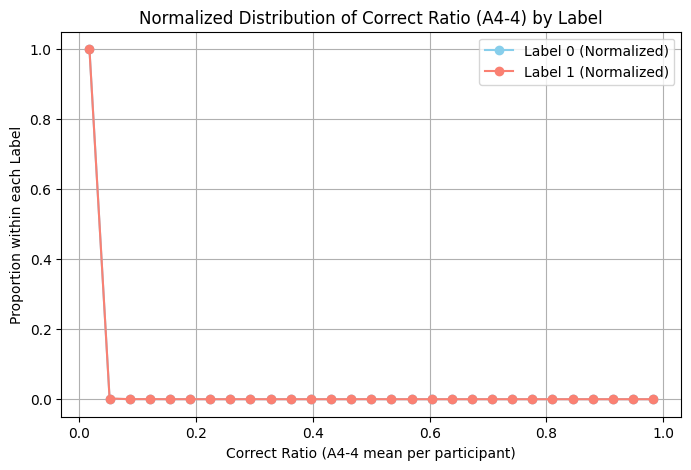

In [ ]:
# Normalized
counts_0, _ = np.histogram(train_a4[train_a4['Label'] == 0]['A4-4_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a4[train_a4['Label'] == 1]['A4-4_ratio'], bins=bins)

counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', label='Label 0 (Normalized)', color='skyblue')
plt.plot(bin_centers, counts_1, marker='o', label='Label 1 (Normalized)', color='salmon')
plt.title('Normalized Distribution of Correct Ratio (A4-4) by Label')
plt.xlabel('Correct Ratio (A4-4 mean per participant)')
plt.ylabel('Proportion within each Label')
plt.legend()
plt.grid(True)
plt.show()

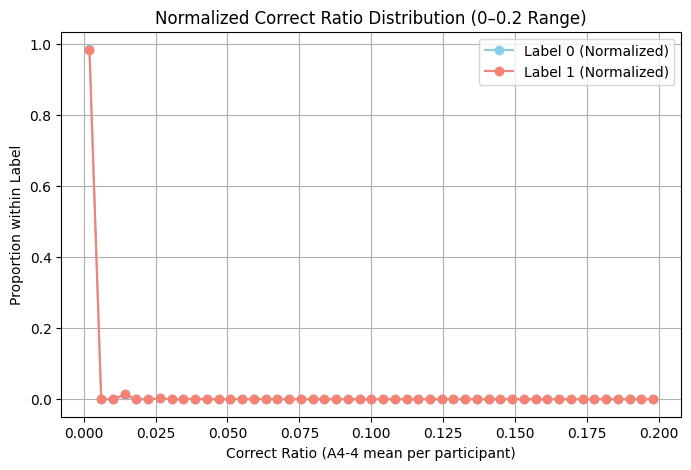

In [ ]:
bins = np.linspace(0, 0.2, 50)
counts_0, _ = np.histogram(train_a4[train_a4['Label'] == 0]['A4-4_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a4[train_a4['Label'] == 1]['A4-4_ratio'], bins=bins)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', color='skyblue', label='Label 0 (Normalized)')
plt.plot(bin_centers, counts_1, marker='o', color='salmon', label='Label 1 (Normalized)')
plt.title('Normalized Correct Ratio Distribution (0–0.2 Range)')
plt.xlabel('Correct Ratio (A4-4 mean per participant)')
plt.ylabel('Proportion within Label')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def extract_a4_features(df):
    df = df.copy()
    df['A4-4_ratio'] = df['A4-4'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A4-4_correct_count'] = df['A4-4'].apply(lambda x: x.count(1) if isinstance(x, list) else np.nan)
    df['A4-4_incorrect_count'] = df['A4-4'].apply(lambda x: x.count(0) if isinstance(x, list) else np.nan)
    df['A4-4_total'] = df['A4-4'].apply(lambda x: len(x) if isinstance(x, list) else 0)

    return df[['Label','A4-4_correct_count','A4-4_incorrect_count','A4-4_total','A4-4_ratio']]

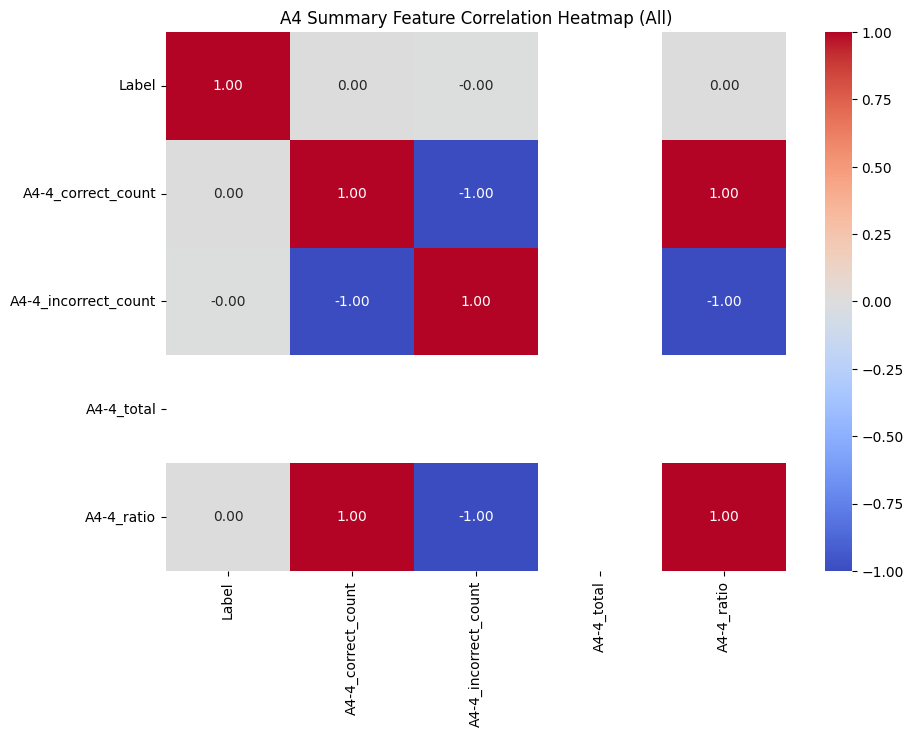

In [ ]:
a4_features = extract_a4_features(train_a4)
corr = a4_features.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A4 Summary Feature Correlation Heatmap (All)")
plt.show()

## **A5 Test**

In [ ]:
train_a5 = train_a[['Label', 'Age', 'A5-1', 'A5-2', 'A5-3']]
train_a5.head()

,Label,Age,A5-1,A5-2,A5-3
0,0,50a,"1,1,4,1,4,4,1,1,4,1,1,3,1,2,2,1,3,2,4,1,3,2,4,...","1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,..."
1,0,60b,"1,4,2,1,1,3,1,1,1,2,1,4,4,1,4,1,2,2,1,4,3,1,3,...","1,1,1,1,1,2,1,1,1,1,1,2,2,1,1,1,1,1,1,1,2,1,2,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,..."
2,0,50a,"1,1,4,1,4,4,1,1,4,1,1,3,1,2,2,1,3,2,4,1,3,2,4,...","1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,..."
3,0,50a,"3,2,1,1,1,1,3,4,4,3,1,3,2,4,4,1,1,1,2,1,1,2,2,...","1,1,1,1,1,1,2,2,2,1,1,2,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,..."
4,0,40b,"1,1,3,4,3,4,4,4,1,1,1,1,2,3,1,1,1,2,2,2,2,2,3,...","1,1,2,2,2,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,...","0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,..."


In [ ]:
train_a5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647241 non-null  int64 
 1   Age     647241 non-null  object
 2   A5-1    647239 non-null  object
 3   A5-2    647239 non-null  object
 4   A5-3    647239 non-null  object
dtypes: int64(1), object(4)
memory usage: 24.7+ MB


In [ ]:
train_a5 = train_a5.dropna()
train_a5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 647239 entries, 0 to 647240
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647239 non-null  int64 
 1   Age     647239 non-null  object
 2   A5-1    647239 non-null  object
 3   A5-2    647239 non-null  object
 4   A5-3    647239 non-null  object
dtypes: int64(1), object(4)
memory usage: 29.6+ MB


In [ ]:
# 36 trials -> list
train_a5['A5-1'] = train_a5['A5-1'].apply(lambda x: list(map(int, x.split(','))))
train_a5['A5-2'] = train_a5['A5-2'].apply(lambda x: list(map(int, x.split(','))))
train_a5['A5-3'] = train_a5['A5-3'].apply(lambda x: list(map(int, x.split(','))))

In [ ]:
a5 = train_a5[['A5-1', 'A5-2', 'A5-3','Label']].explode(['A5-1', 'A5-2', 'A5-3']).copy()

### A5-1

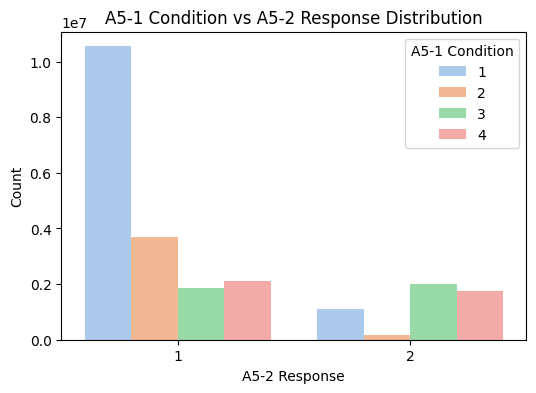

In [ ]:
# A5-1 별 A5-2 분포
plt.figure(figsize=(6,4))
sns.countplot(data=a5, x='A5-2', hue='A5-1', palette='pastel')
plt.title('A5-1 Condition vs A5-2 Response Distribution')
plt.xlabel('A5-2 Response')
plt.ylabel('Count')
plt.legend(title='A5-1 Condition')
plt.show()

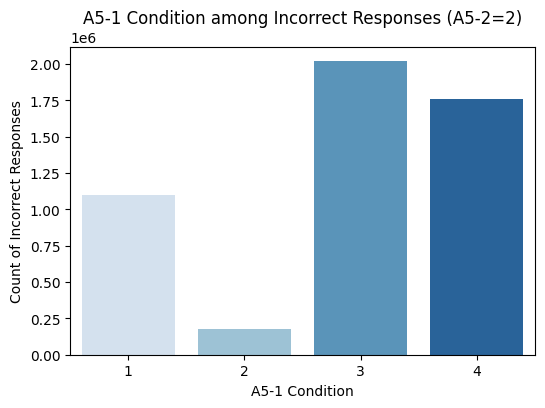

In [ ]:
# A5-2이 2인 응답만
a5_resp1 = a5[a5['A5-2'] == 2]

plt.figure(figsize=(6,4))
sns.countplot(data=a5_resp1, x='A5-1', palette='Blues')
plt.title('A5-1 Condition among Incorrect Responses (A5-2=2)')
plt.xlabel('A5-1 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()

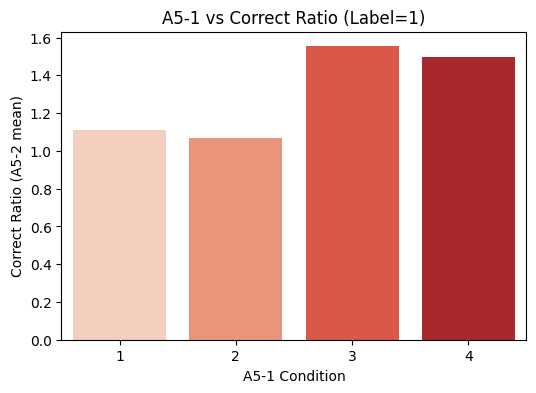

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Respose, Label은 A5-1와 관계없음 (별로 중요하지 않음)
a5_label1 = a5[a5['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a5_label1, x='A5-1', y='A5-2', estimator=np.mean, ci=None, palette='Reds')
plt.title('A5-1 vs Correct Ratio (Label=1)')
plt.xlabel('A5-1 Condition')
plt.ylabel('Correct Ratio (A5-2 mean)')
plt.show()

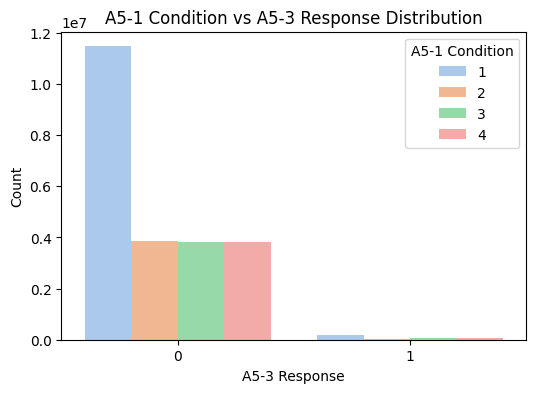

In [ ]:
# A5-1 별 A5-3 분포
plt.figure(figsize=(6,4))
sns.countplot(data=a5, x='A5-3', hue='A5-1', palette='pastel')
plt.title('A5-1 Condition vs A5-3 Response Distribution')
plt.xlabel('A5-3 Response')
plt.ylabel('Count')
plt.legend(title='A5-1 Condition')
plt.show()

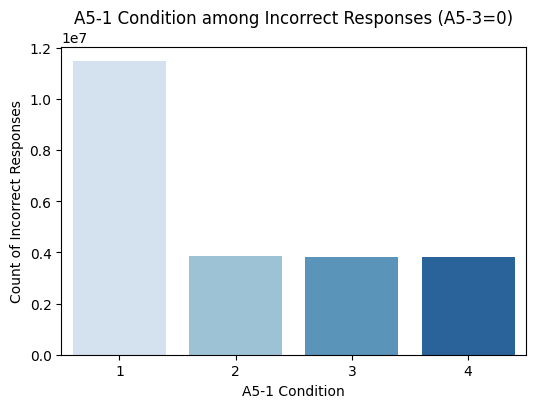

In [ ]:
# A5-3이 0인 응답만
a5_resp1 = a5[a5['A5-3'] == 0]

plt.figure(figsize=(6,4))
sns.countplot(data=a5_resp1, x='A5-1', palette='Blues')
plt.title('A5-1 Condition among Incorrect Responses (A5-3=0)')
plt.xlabel('A5-1 Condition')
plt.ylabel('Count of Incorrect Responses')
plt.show()

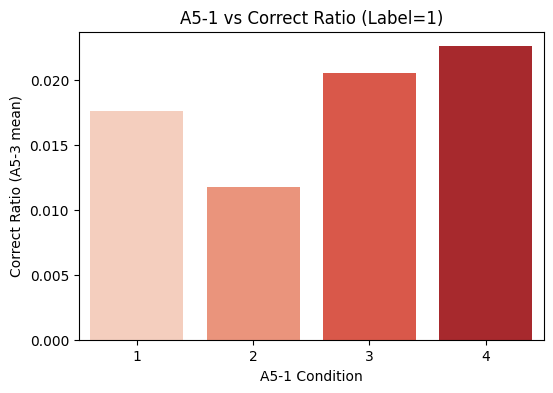

In [ ]:
# Label = 1인 데이터만
# 확인 결과 Response, Label은 A5-1와 관계없음 (별로 중요하지 않음)
a5_label1 = a5[a5['Label'] == 1]

plt.figure(figsize=(6,4))
sns.barplot(data=a5_label1, x='A5-1', y='A5-3', estimator=np.mean, ci=None, palette='Reds')
plt.title('A5-1 vs Correct Ratio (Label=1)')
plt.xlabel('A5-1 Condition')
plt.ylabel('Correct Ratio (A5-3 mean)')
plt.show()

### A5-2

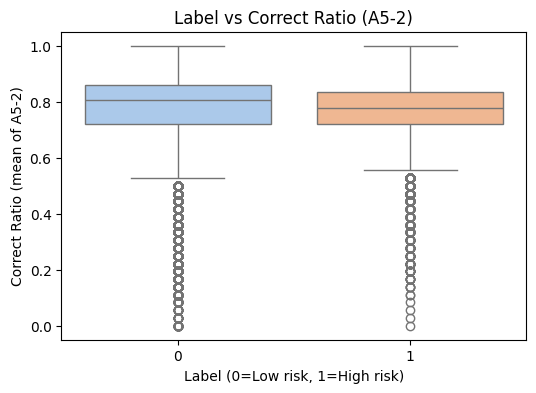

In [ ]:
# 참가자 단위로 평균 정답률 계산
train_a5['A5-2_ratio'] = train_a5['A5-2'].apply(lambda x: x.count(1)/len(x))

plt.figure(figsize=(6,4))
sns.boxplot(data=train_a5, x='Label', y='A5-2_ratio', palette='pastel')
plt.title('Label vs Correct Ratio (A5-2)')
plt.xlabel('Label (0=Low risk, 1=High risk)')
plt.ylabel('Correct Ratio (mean of A5-2)')
plt.show()

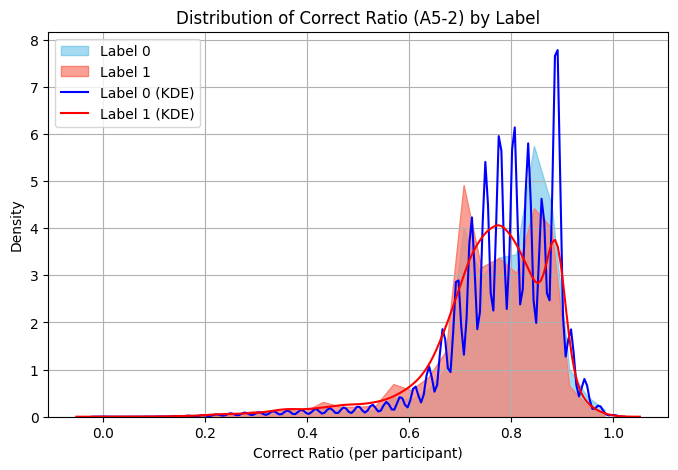

In [ ]:
# KDE Plot
bins = np.linspace(0, 1, 30)

plt.figure(figsize=(8,5))
sns.histplot(train_a5[train_a5['Label'] == 0]['A5-2_ratio'], bins=bins, kde=False, stat='density', color='skyblue', label='Label 0', element='poly')
sns.histplot(train_a5[train_a5['Label'] == 1]['A5-2_ratio'], bins=bins, kde=False, stat='density', color='salmon', label='Label 1', element='poly')

sns.kdeplot(train_a5[train_a5['Label'] == 0]['A5-2_ratio'], color='blue', label='Label 0 (KDE)')
sns.kdeplot(train_a5[train_a5['Label'] == 1]['A5-2_ratio'], color='red', label='Label 1 (KDE)')

plt.title('Distribution of Correct Ratio (A5-2) by Label')
plt.xlabel('Correct Ratio (per participant)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

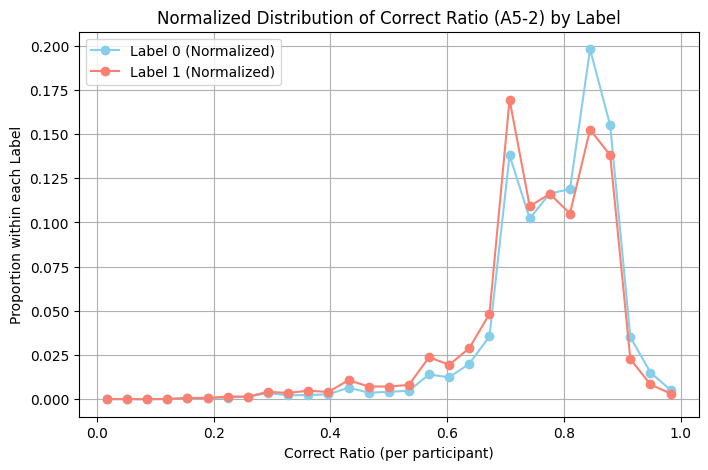

In [ ]:
# Normalized
counts_0, _ = np.histogram(train_a5[train_a5['Label']==0]['A5-2_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a5[train_a5['Label']==1]['A5-2_ratio'], bins=bins)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()
bin_centers = (bins[:-1]+bins[1:])/2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', color='skyblue', label='Label 0 (Normalized)')
plt.plot(bin_centers, counts_1, marker='o', color='salmon', label='Label 1 (Normalized)')
plt.title('Normalized Distribution of Correct Ratio (A5-2) by Label')
plt.xlabel('Correct Ratio (per participant)')
plt.ylabel('Proportion within each Label')
plt.legend()
plt.grid(True)
plt.show()

### A5-3

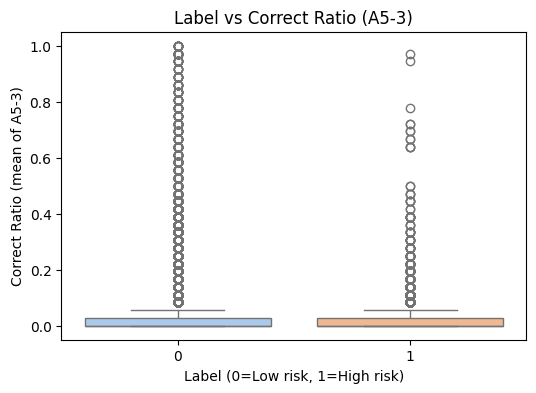

In [ ]:
# 참가자 단위로 평균 정답률 계산
train_a5['A5-3_ratio'] = train_a5['A5-3'].apply(lambda x: x.count(1)/len(x))

plt.figure(figsize=(6,4))
sns.boxplot(data=train_a5, x='Label', y='A5-3_ratio', palette='pastel')
plt.title('Label vs Correct Ratio (A5-3)')
plt.xlabel('Label (0=Low risk, 1=High risk)')
plt.ylabel('Correct Ratio (mean of A5-3)')
plt.show()

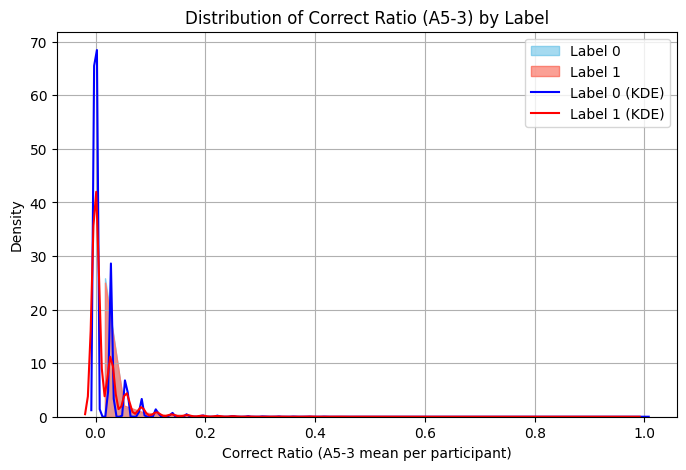

In [ ]:
# KDE Plot
# 이렇게 보면 Label 0, 1 둘다 정답률 0에 많이 모여있음
# 다른 검사의 정답률과 함께 봐야할듯
bins = np.linspace(0, 1, 30)

plt.figure(figsize=(8,5))
sns.histplot(train_a5[train_a5['Label'] == 0]['A5-3_ratio'],
             bins=bins, kde=False, stat='density', color='skyblue', label='Label 0', element='poly')
sns.histplot(train_a5[train_a5['Label'] == 1]['A5-3_ratio'],
             bins=bins, kde=False, stat='density', color='salmon', label='Label 1', element='poly')

sns.kdeplot(train_a5[train_a5['Label'] == 0]['A5-3_ratio'], color='blue', label='Label 0 (KDE)')
sns.kdeplot(train_a5[train_a5['Label'] == 1]['A5-3_ratio'], color='red', label='Label 1 (KDE)')

plt.title('Distribution of Correct Ratio (A5-3) by Label')
plt.xlabel('Correct Ratio (A5-3 mean per participant)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

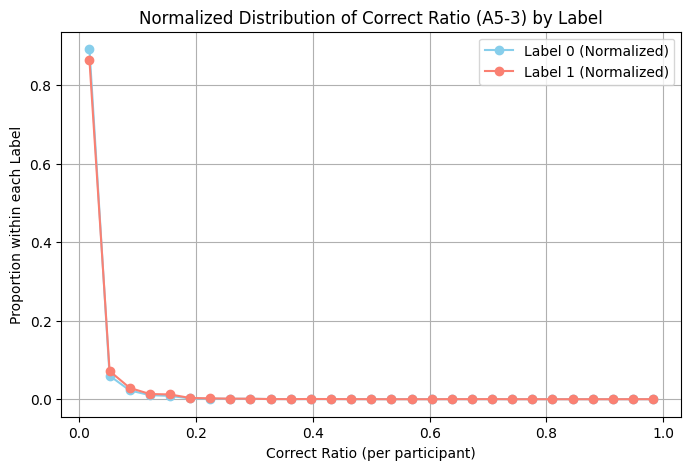

In [ ]:
# Normalized
counts_0, _ = np.histogram(train_a5[train_a5['Label']==0]['A5-3_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a5[train_a5['Label']==1]['A5-3_ratio'], bins=bins)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()
bin_centers = (bins[:-1]+bins[1:])/2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', color='skyblue', label='Label 0 (Normalized)')
plt.plot(bin_centers, counts_1, marker='o', color='salmon', label='Label 1 (Normalized)')
plt.title('Normalized Distribution of Correct Ratio (A5-3) by Label')
plt.xlabel('Correct Ratio (per participant)')
plt.ylabel('Proportion within each Label')
plt.legend()
plt.grid(True)
plt.show()

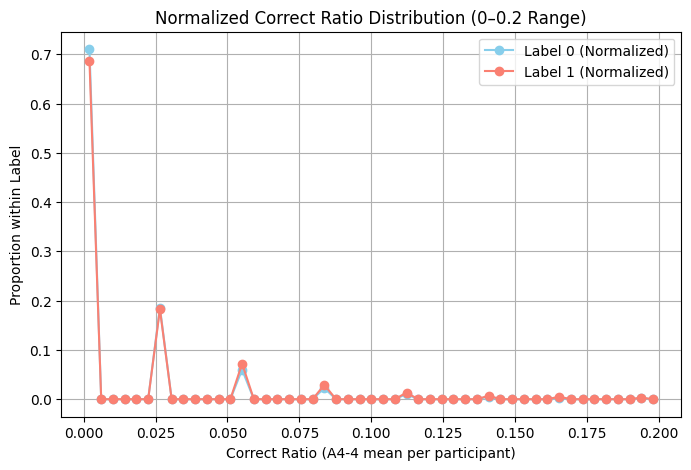

In [ ]:
bins = np.linspace(0, 0.2, 50)
counts_0, _ = np.histogram(train_a5[train_a5['Label'] == 0]['A5-3_ratio'], bins=bins)
counts_1, _ = np.histogram(train_a5[train_a5['Label'] == 1]['A5-3_ratio'], bins=bins)
counts_0 = counts_0 / counts_0.sum()
counts_1 = counts_1 / counts_1.sum()
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(8,5))
plt.plot(bin_centers, counts_0, marker='o', color='skyblue', label='Label 0 (Normalized)')
plt.plot(bin_centers, counts_1, marker='o', color='salmon', label='Label 1 (Normalized)')
plt.title('Normalized Correct Ratio Distribution (0–0.2 Range)')
plt.xlabel('Correct Ratio (A4-4 mean per participant)')
plt.ylabel('Proportion within Label')
plt.legend()
plt.grid(True)
plt.show()

### Correlation

In [ ]:
def extract_a5_features(df):
    df = df.copy()

    df['A5-2_ratio'] = df['A5-2'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A5-2_correct_count'] = df['A5-2'].apply(lambda x: x.count(1) if isinstance(x, list) else np.nan)
    df['A5-2_incorrect_count'] = df['A5-2'].apply(lambda x: x.count(2) if isinstance(x, list) else np.nan)
    df['A5-2_total'] = df['A5-2'].apply(lambda x: len(x) if isinstance(x, list) else 0)

    df['A5-3_ratio'] = df['A5-3'].apply(lambda x: np.mean(x) if isinstance(x, list) else np.nan)
    df['A5-3_correct_count'] = df['A5-3'].apply(lambda x: x.count(1) if isinstance(x, list) else np.nan)
    df['A5-3_incorrect_count'] = df['A5-3'].apply(lambda x: x.count(0) if isinstance(x, list) else np.nan)
    df['A5-3_total'] = df['A5-3'].apply(lambda x: len(x) if isinstance(x, list) else 0)

    return df[['Label','A5-2_correct_count','A5-2_incorrect_count','A5-2_ratio', 'A5-3_correct_count','A5-3_incorrect_count','A5-3_ratio']]

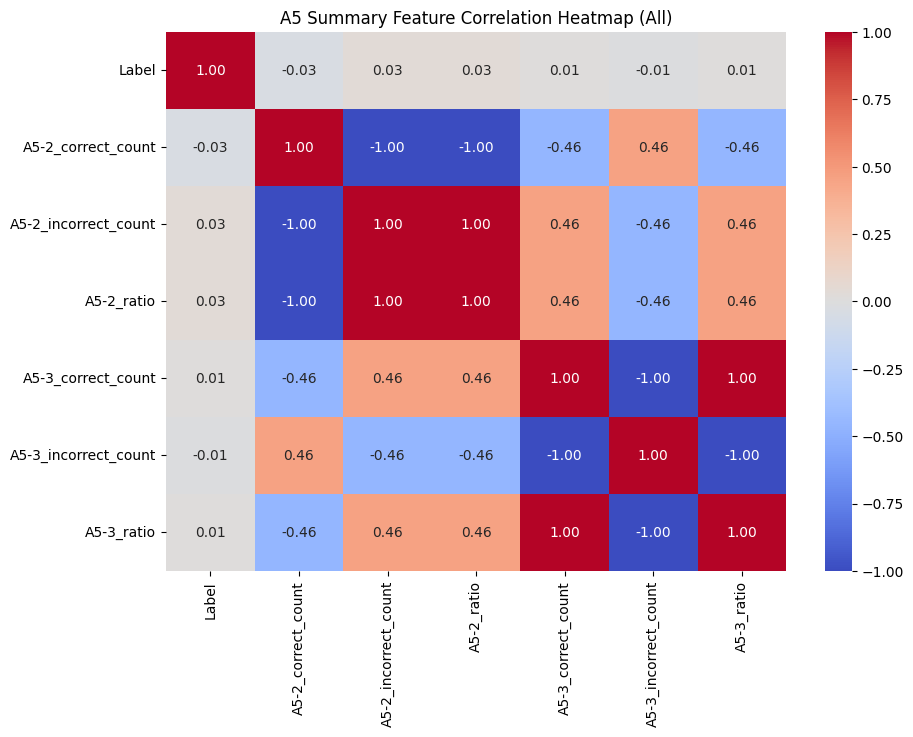

In [ ]:
a5_features = extract_a5_features(train_a5)
corr = a5_features.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A5 Summary Feature Correlation Heatmap (All)")
plt.show()

## **A6 Test**

In [ ]:
train_a6 = train_a[['Label', 'Age', 'A6-1']]
train_a6.head()

,Label,Age,A6-1
0,0,50a,12
1,0,60b,10
2,0,50a,12
3,0,50a,13
4,0,40b,13


In [ ]:
train_a6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647241 non-null  int64 
 1   Age     647241 non-null  object
 2   A6-1    647241 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 14.8+ MB


### A6-1

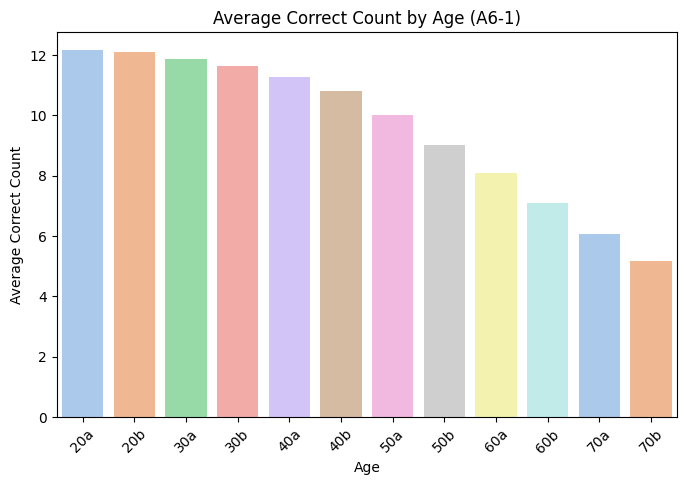

In [ ]:
# 연령대 별 맞춘 문제 개수의 평균
age_mean = train_a6.groupby('Age')['A6-1'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=age_mean, x='Age', y='A6-1', palette='pastel')
plt.title('Average Correct Count by Age (A6-1)')
plt.xlabel('Age')
plt.ylabel('Average Correct Count')
plt.xticks(rotation=45)
plt.show()

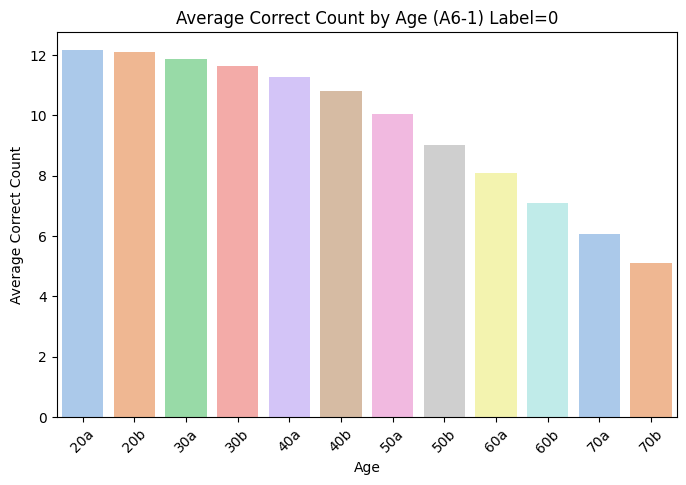

In [ ]:
age_mean = train_a6[train_a6['Label'] == 0].groupby('Age')['A6-1'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=age_mean, x='Age', y='A6-1', palette='pastel')
plt.title('Average Correct Count by Age (A6-1) Label=0')
plt.xlabel('Age')
plt.ylabel('Average Correct Count')
plt.xticks(rotation=45)
plt.show()

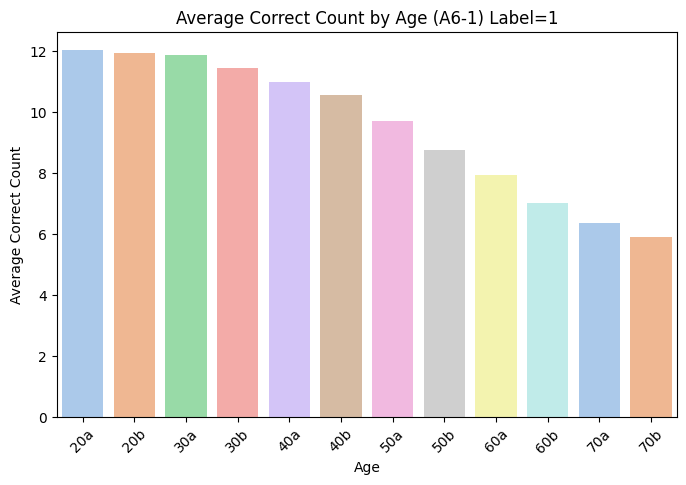

In [ ]:
age_mean = train_a6[train_a6['Label'] == 1].groupby('Age')['A6-1'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=age_mean, x='Age', y='A6-1', palette='pastel')
plt.title('Average Correct Count by Age (A6-1) Label=1')
plt.xlabel('Age')
plt.ylabel('Average Correct Count')
plt.xticks(rotation=45)
plt.show()

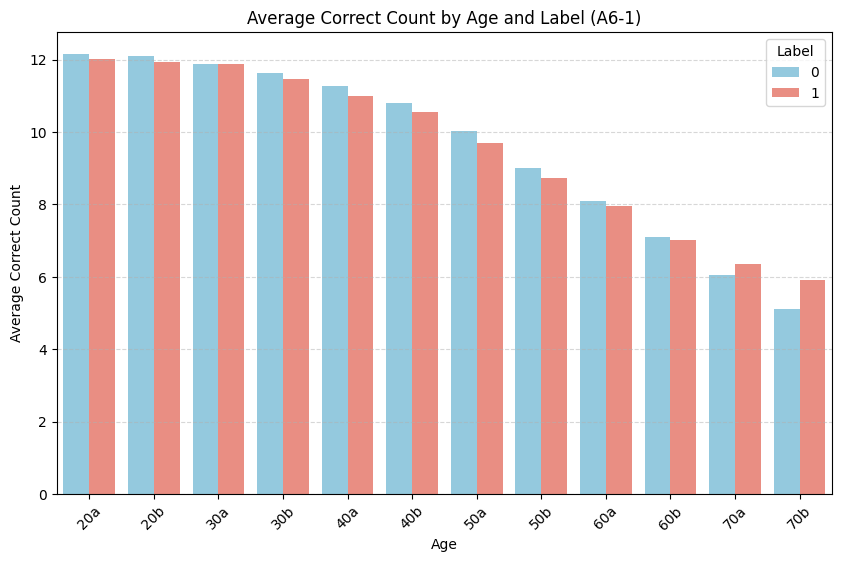

In [ ]:
age_label_mean = train_a6.groupby(['Age', 'Label'])['A6-1'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=age_label_mean, x='Age', y='A6-1', hue='Label', palette=['skyblue','salmon'])
plt.title('Average Correct Count by Age and Label (A6-1)')
plt.xlabel('Age')
plt.ylabel('Average Correct Count')
plt.xticks(rotation=45)
plt.legend(title='Label')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

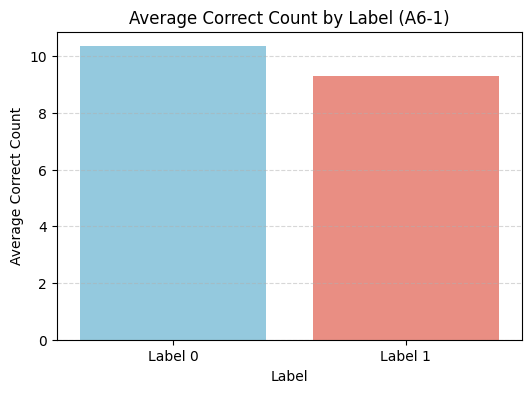

In [ ]:
# Label별 평균 맞춘 문제 수 계산
label_mean = train_a6.groupby('Label')['A6-1'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=label_mean, x='Label', y='A6-1', palette=['skyblue','salmon'])
plt.title('Average Correct Count by Label (A6-1)')
plt.xlabel('Label')
plt.ylabel('Average Correct Count')
plt.xticks([0,1], ['Label 0', 'Label 1'])
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


In [ ]:
summary_a6 = train_a6.groupby('Label')['A6-1'].describe().T
display(summary_a6)

Label,0,1
count,632549.000000,14692.000000
mean,10.342947,9.299891
std,2.932659,3.229483
min,0.000000,0.000000
25%,9.000000,7.000000
50%,11.000000,10.000000
75%,13.000000,12.000000
max,14.000000,14.000000


### Correlation

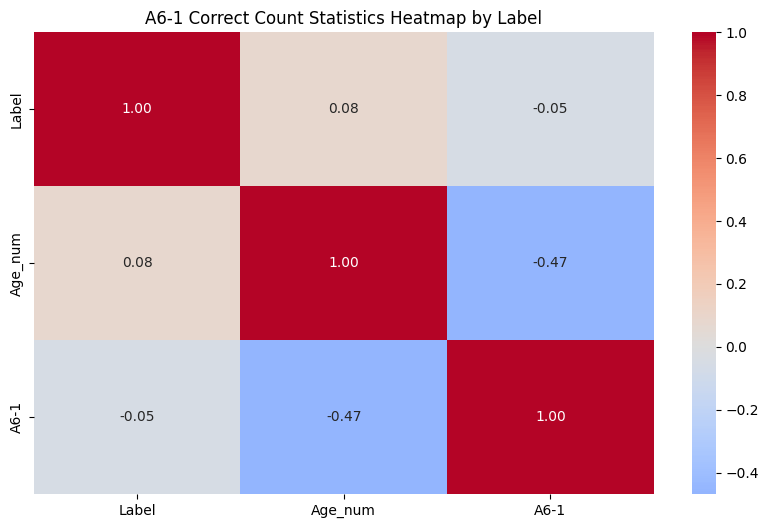

In [ ]:
train_a6['Age_num'] = train_a6['Age'].str.extract('(\d+)').astype(int)
corr = train_a6[['Label', 'Age_num', 'A6-1']].corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A6-1 Correct Count Statistics Heatmap by Label")
plt.show()

## **A7 Test**

In [ ]:
train_a7 = train_a[['Label', 'Age', 'A7-1']]
train_a7.head()

,Label,Age,A7-1
0,0,50a,15
1,0,60b,10
2,0,50a,17
3,0,50a,14
4,0,40b,10


In [ ]:
train_a7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647241 non-null  int64 
 1   Age     647241 non-null  object
 2   A7-1    647241 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 14.8+ MB


### A7-1

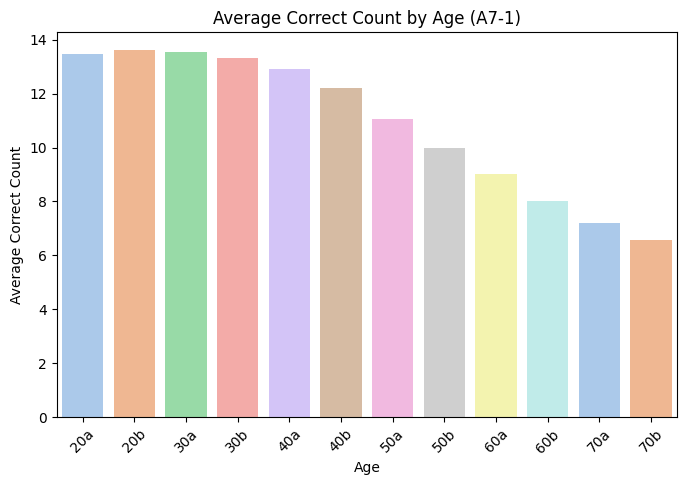

In [ ]:
# 연령대 별 맞춘 문제 개수의 평균
age_mean = train_a7.groupby('Age')['A7-1'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=age_mean, x='Age', y='A7-1', palette='pastel')
plt.title('Average Correct Count by Age (A7-1)')
plt.xlabel('Age')
plt.ylabel('Average Correct Count')
plt.xticks(rotation=45)
plt.show()

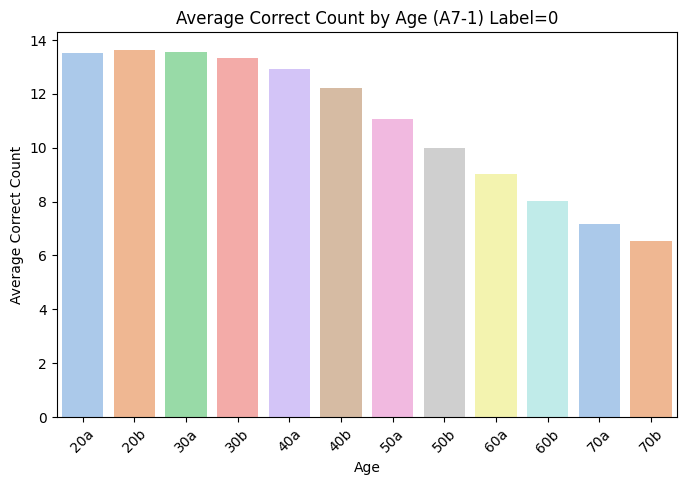

In [ ]:
age_mean = train_a7[train_a7['Label'] == 0].groupby('Age')['A7-1'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=age_mean, x='Age', y='A7-1', palette='pastel')
plt.title('Average Correct Count by Age (A7-1) Label=0')
plt.xlabel('Age')
plt.ylabel('Average Correct Count')
plt.xticks(rotation=45)
plt.show()

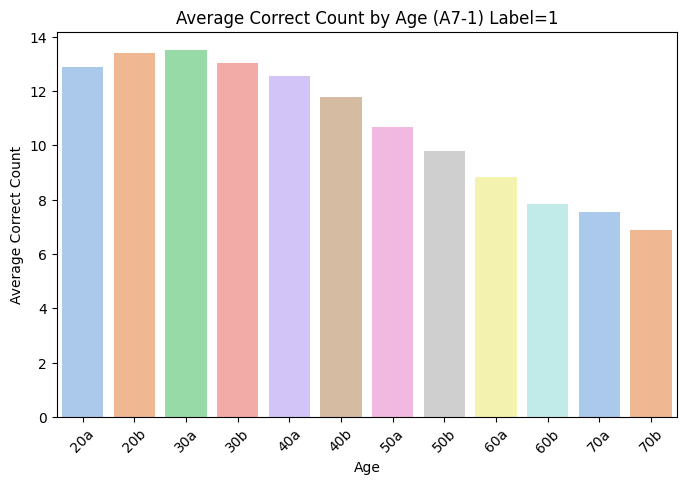

In [ ]:
age_mean = train_a7[train_a7['Label'] == 1].groupby('Age')['A7-1'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=age_mean, x='Age', y='A7-1', palette='pastel')
plt.title('Average Correct Count by Age (A7-1) Label=1')
plt.xlabel('Age')
plt.ylabel('Average Correct Count')
plt.xticks(rotation=45)
plt.show()

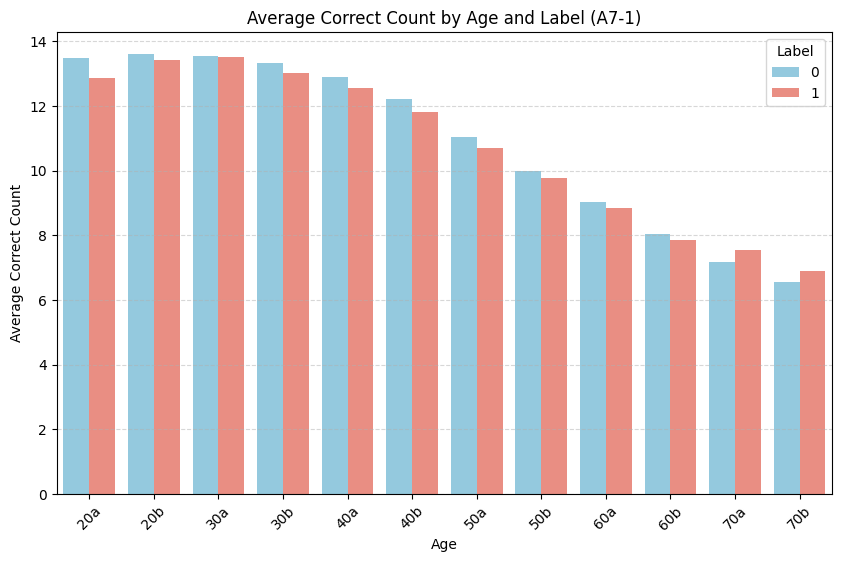

In [ ]:
age_label_mean = train_a7.groupby(['Age', 'Label'])['A7-1'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=age_label_mean, x='Age', y='A7-1', hue='Label', palette=['skyblue','salmon'])
plt.title('Average Correct Count by Age and Label (A7-1)')
plt.xlabel('Age')
plt.ylabel('Average Correct Count')
plt.xticks(rotation=45)
plt.legend(title='Label')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

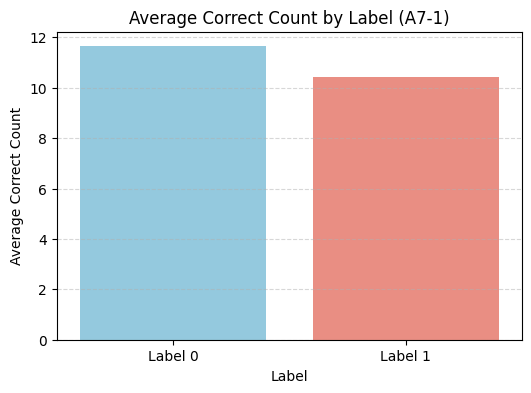

In [ ]:
# Label별 평균 맞춘 문제 수 계산
label_mean = train_a7.groupby('Label')['A7-1'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=label_mean, x='Label', y='A7-1', palette=['skyblue','salmon'])
plt.title('Average Correct Count by Label (A7-1)')
plt.xlabel('Label')
plt.ylabel('Average Correct Count')
plt.xticks([0,1], ['Label 0', 'Label 1'])
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


In [ ]:
summary_a7 = train_a7.groupby('Label')['A7-1'].describe().T
display(summary_a7)

Label,0,1
count,632549.000000,14692.000000
mean,11.640360,10.406684
std,3.946515,4.035148
min,0.000000,0.000000
25%,9.000000,7.000000
50%,12.000000,10.000000
75%,15.000000,14.000000
max,18.000000,18.000000


### Correlation

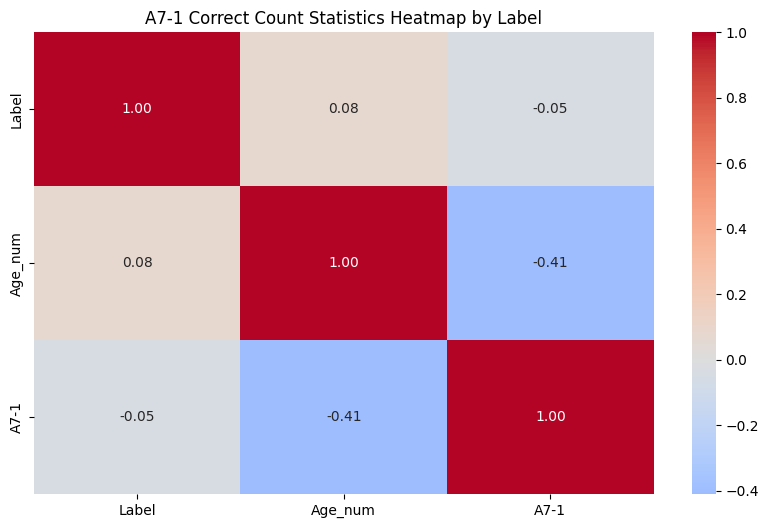

In [ ]:
train_a7['Age_num'] = train_a7['Age'].str.extract('(\d+)').astype(int)
corr = train_a7[['Label', 'Age_num', 'A7-1']].corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("A7-1 Correct Count Statistics Heatmap by Label")
plt.show()

## **A8, A9 Test**

In [ ]:
train_a89 = train_a[['Label', 'Age', 'A8-1', 'A8-2', 'A9-1', 'A9-2', 'A9-3', 'A9-4', 'A9-5']]
train_a89.head()

,Label,Age,A8-1,A8-2,A9-1,A9-2,A9-3,A9-4,A9-5
0,0,50a,0,1,10,12,6,10,14
1,0,60b,1,2,2,15,6,0,5
2,0,50a,10,0,0,0,0,0,0
3,0,50a,7,1,5,1,0,20,9
4,0,40b,9,0,1,6,0,6,2


In [ ]:
train_a89.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647241 entries, 0 to 647240
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Label   647241 non-null  int64 
 1   Age     647241 non-null  object
 2   A8-1    647241 non-null  int64 
 3   A8-2    647241 non-null  int64 
 4   A9-1    647241 non-null  int64 
 5   A9-2    647241 non-null  int64 
 6   A9-3    647241 non-null  int64 
 7   A9-4    647241 non-null  int64 
 8   A9-5    647241 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 44.4+ MB


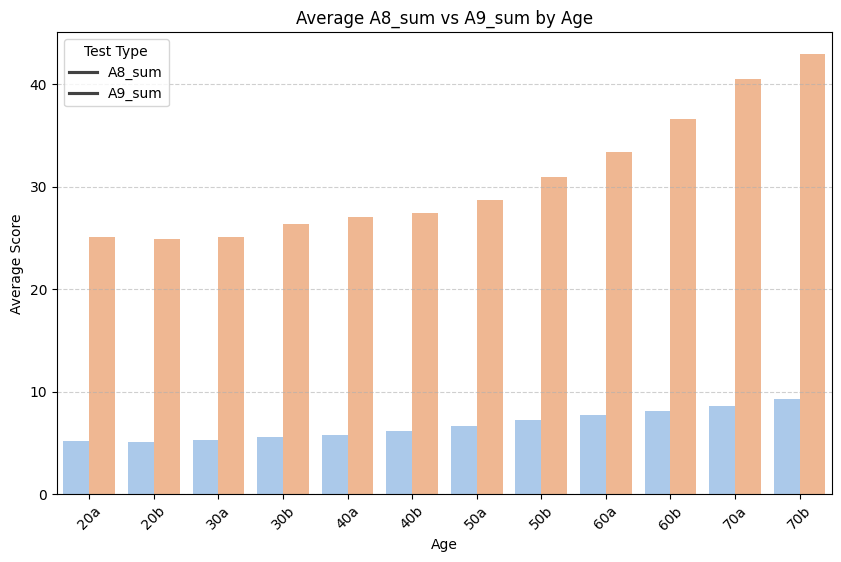

In [ ]:
train_a89['A8_sum'] = train_a89[['A8-1','A8-2']].sum(axis=1)
train_a89['A9_sum'] = train_a89[['A9-1','A9-2','A9-3','A9-4','A9-5']].sum(axis=1)

age_mean = train_a89.groupby('Age')[['A8_sum', 'A9_sum']].mean().reset_index()
melted = age_mean.melt(id_vars='Age', value_vars=['A8_sum', 'A9_sum'],
                       var_name='Type', value_name='Mean_Score')

plt.figure(figsize=(10,6))
sns.barplot(data=melted, x='Age', y='Mean_Score', hue='Type', palette='pastel')

plt.title('Average A8_sum vs A9_sum by Age')
plt.xlabel('Age')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Test Type', labels=['A8_sum', 'A9_sum'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

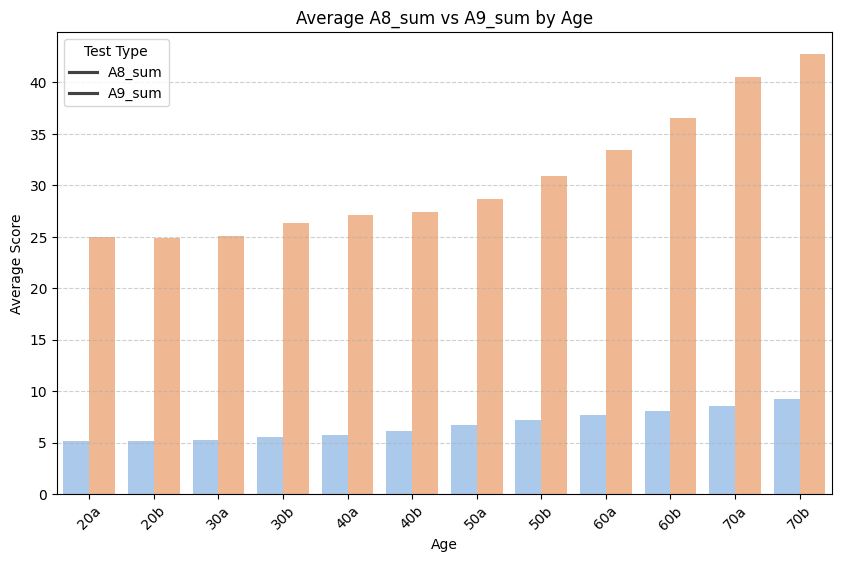

In [ ]:
age_mean = train_a89[train_a89['Label'] == 0].groupby('Age')[['A8_sum', 'A9_sum']].mean().reset_index()
melted = age_mean.melt(id_vars='Age', value_vars=['A8_sum', 'A9_sum'],
                       var_name='Type', value_name='Mean_Score')

plt.figure(figsize=(10,6))
sns.barplot(data=melted, x='Age', y='Mean_Score', hue='Type', palette='pastel')

plt.title('Average A8_sum vs A9_sum by Age')
plt.xlabel('Age')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Test Type', labels=['A8_sum', 'A9_sum'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

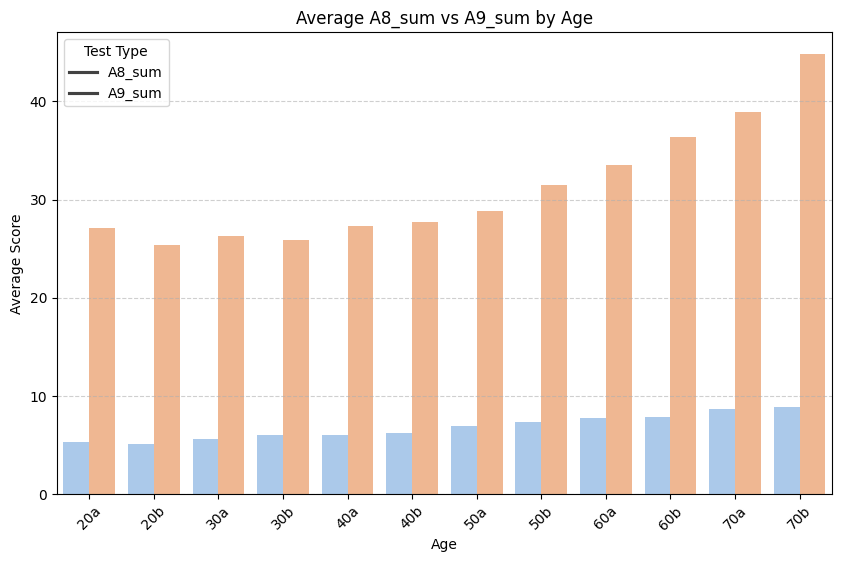

In [ ]:
age_mean = train_a89[train_a89['Label'] == 1].groupby('Age')[['A8_sum', 'A9_sum']].mean().reset_index()
melted = age_mean.melt(id_vars='Age', value_vars=['A8_sum', 'A9_sum'],
                       var_name='Type', value_name='Mean_Score')

plt.figure(figsize=(10,6))
sns.barplot(data=melted, x='Age', y='Mean_Score', hue='Type', palette='pastel')

plt.title('Average A8_sum vs A9_sum by Age')
plt.xlabel('Age')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Test Type', labels=['A8_sum', 'A9_sum'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

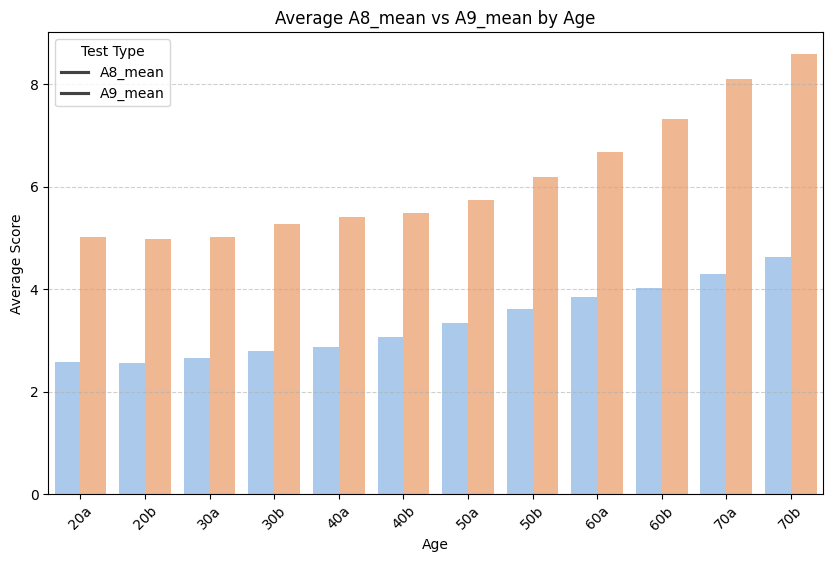

In [ ]:
train_a89['A8_mean'] = train_a89[['A8-1','A8-2']].mean(axis=1)
train_a89['A9_mean'] = train_a89[['A9-1','A9-2','A9-3','A9-4','A9-5']].mean(axis=1)

age_mean = train_a89.groupby('Age')[['A8_mean', 'A9_mean']].mean().reset_index()
melted = age_mean.melt(id_vars='Age', value_vars=['A8_mean', 'A9_mean'],
                       var_name='Type', value_name='Mean_Score')

plt.figure(figsize=(10,6))
sns.barplot(data=melted, x='Age', y='Mean_Score', hue='Type', palette='pastel')

plt.title('Average A8_mean vs A9_mean by Age')
plt.xlabel('Age')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Test Type', labels=['A8_mean', 'A9_mean'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

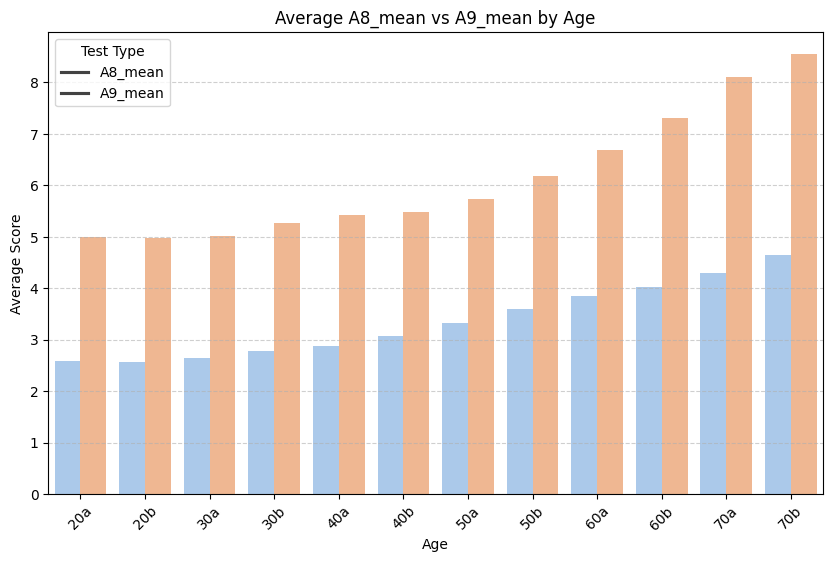

In [ ]:
age_mean = train_a89[train_a89['Label'] == 0].groupby('Age')[['A8_mean', 'A9_mean']].mean().reset_index()
melted = age_mean.melt(id_vars='Age', value_vars=['A8_mean', 'A9_mean'],
                       var_name='Type', value_name='Mean_Score')

plt.figure(figsize=(10,6))
sns.barplot(data=melted, x='Age', y='Mean_Score', hue='Type', palette='pastel')

plt.title('Average A8_mean vs A9_mean by Age')
plt.xlabel('Age')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Test Type', labels=['A8_mean', 'A9_mean'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

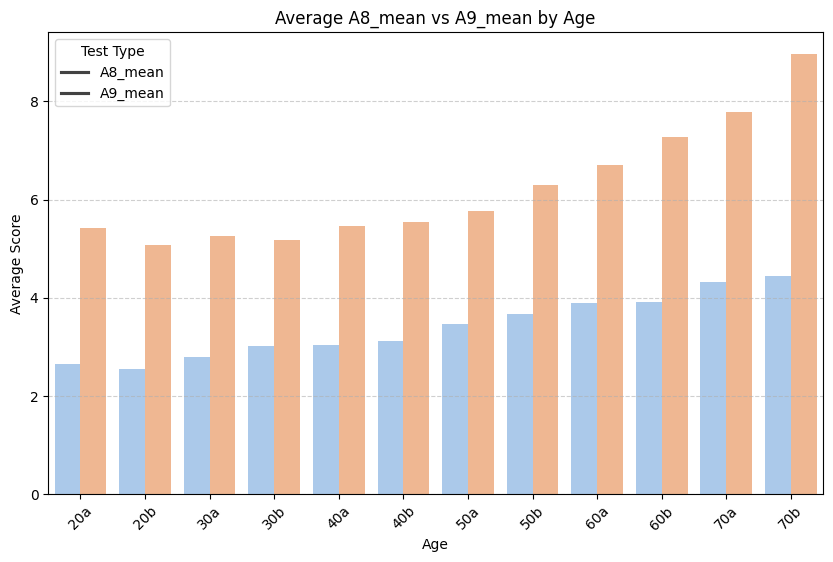

In [ ]:
age_mean = train_a89[train_a89['Label'] == 1].groupby('Age')[['A8_mean', 'A9_mean']].mean().reset_index()
melted = age_mean.melt(id_vars='Age', value_vars=['A8_mean', 'A9_mean'],
                       var_name='Type', value_name='Mean_Score')

plt.figure(figsize=(10,6))
sns.barplot(data=melted, x='Age', y='Mean_Score', hue='Type', palette='pastel')

plt.title('Average A8_mean vs A9_mean by Age')
plt.xlabel('Age')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Test Type', labels=['A8_mean', 'A9_mean'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Correlation

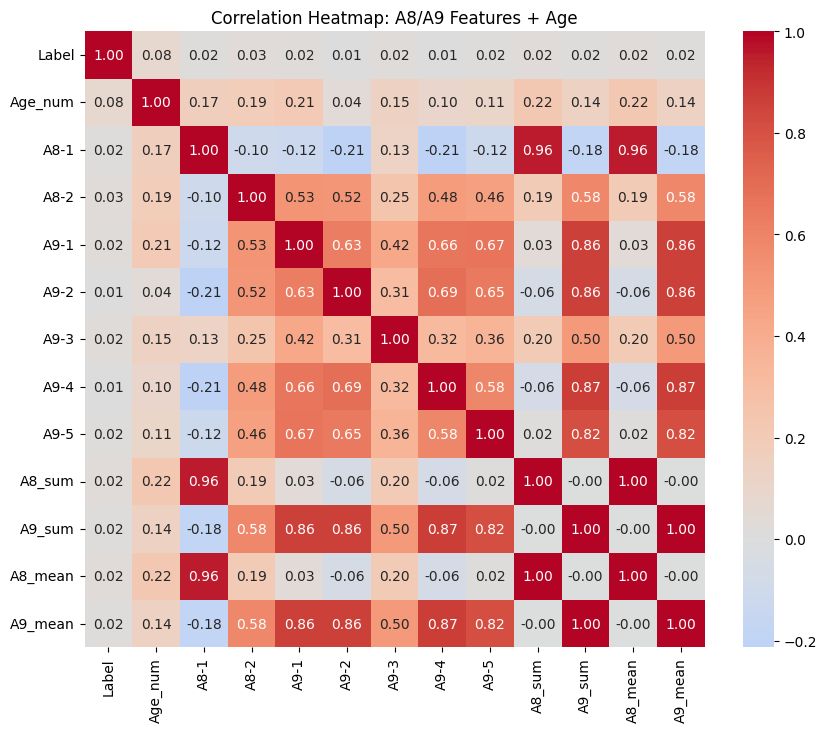

In [ ]:
train_a89['Age_num'] = train_a89['Age'].str.replace('[ab]', '', regex=True).astype(int)

cols = ['Label', 'Age_num', 'A8-1','A8-2',
        'A9-1','A9-2','A9-3','A9-4','A9-5',
        'A8_sum','A9_sum','A8_mean','A9_mean']

corr = train_a89[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: A8/A9 Features + Age")
plt.show()

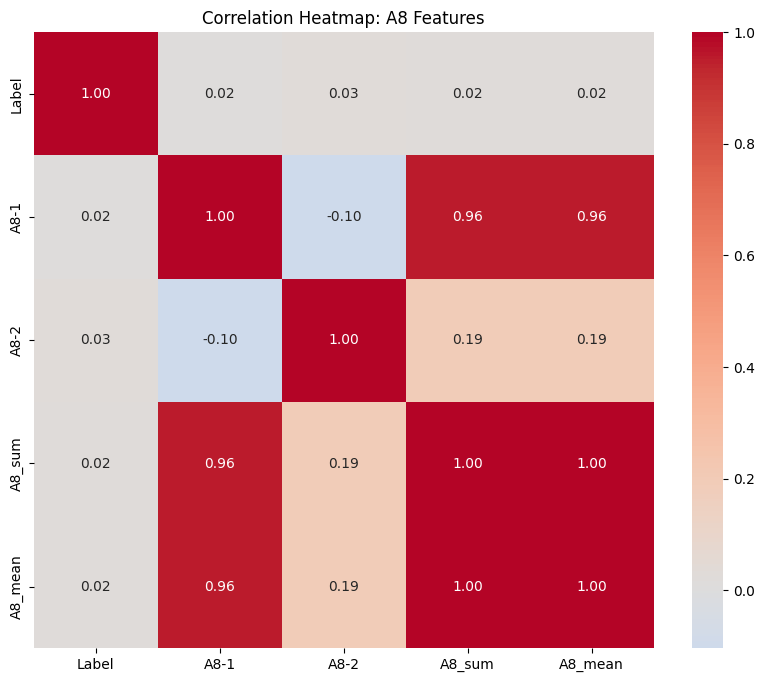

In [ ]:
cols = ['Label', 'A8-1','A8-2',
        'A8_sum','A8_mean']

corr = train_a89[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: A8 Features")
plt.show()

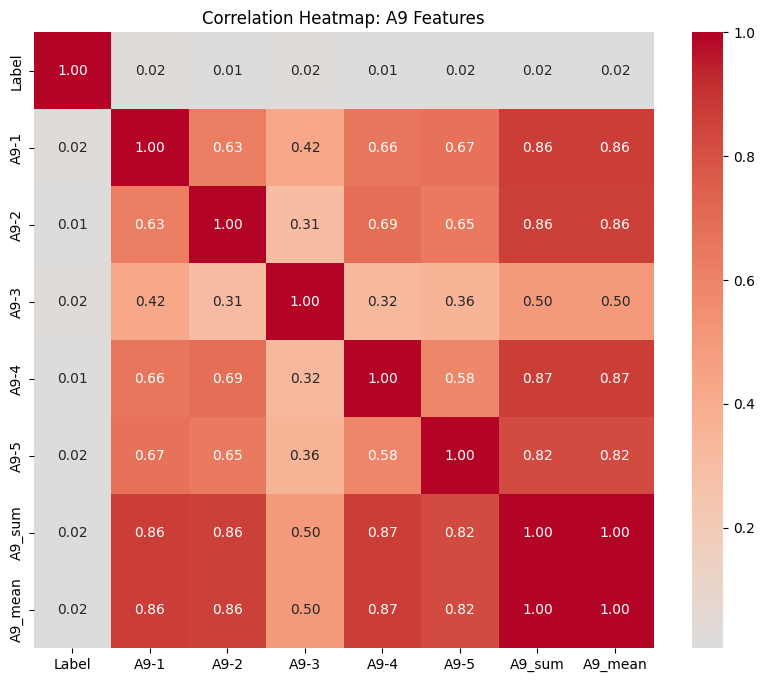

In [ ]:
cols = ['Label', 'A9-1','A9-2','A9-3','A9-4','A9-5',
        'A9_sum','A9_mean']

corr = train_a89[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: A9 Features")
plt.show()

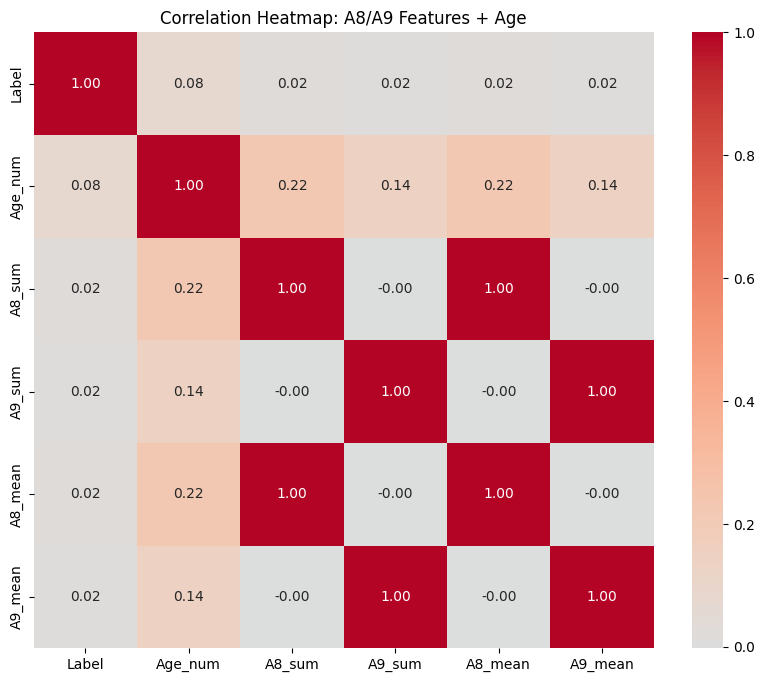

In [ ]:
cols = ['Label', 'Age_num',
        'A8_sum','A9_sum','A8_mean','A9_mean']

corr = train_a89[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap: A8/A9 Features + Age")
plt.show()

## **All Tests**